In [ ]:
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError

print("Python:", sys.version.split()[0])

for package in ["torch", "transformers", "cityscapesscripts"]:
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: NOT INSTALLED")

try:
    result = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,memory.free",
            "--format=csv",
        ],
        capture_output=True,
        text=True,
    )
    print("\nGPU information:")
    print(result.stdout.strip() or result.stderr.strip())
except FileNotFoundError:
    print("\nNo nvidia-smi found. Check your Colab GPU runtime setting.")

print("\nModel in this session:", "model" in globals())
print("Processor in this session:", "processor" in globals())

Python: 3.13.15
torch: 2.11.0+cpu
transformers: 5.16.1
cityscapesscripts: NOT INSTALLED

No nvidia-smi found. Check your Colab GPU runtime setting.

Model in this session: False
Processor in this session: False


In [ ]:
import inspect
from transformers import OneFormerConfig
from transformers.models.oneformer import (
    modeling_oneformer,
    processing_oneformer,
)

checkpoint = "shi-labs/oneformer_cityscapes_swin_large"
config = OneFormerConfig.from_pretrained(checkpoint)

print("CHECKPOINT SETTINGS")
for key in [
    "is_training",
    "num_queries",
    "text_encoder_width",
    "text_encoder_num_layers",
    "contrastive_weight",
]:
    print(f"{key}: {getattr(config, key, 'not present')}")

print("\nMODEL FORWARD INPUTS")
print(inspect.signature(
    modeling_oneformer.OneFormerForUniversalSegmentation.forward
))

# Inspect the actual implementation installed in your Colab session.
print("\nTEXT AND TRAINING CODE EXCERPTS")

for module in [modeling_oneformer, processing_oneformer]:
    source = inspect.getsource(module)
    lines = source.splitlines()

    matches = [
        i for i, line in enumerate(lines)
        if any(term in line for term in [
            "config.is_training",
            "self.text_mapper",
            "text_inputs",
            "loss_contrastive",
        ])
    ]

    # Merge nearby excerpts to avoid repeating lines.
    selected = set()
    for i in matches:
        selected.update(range(max(0, i - 2), min(len(lines), i + 4)))

    print(f"\n--- {module.__name__} ---")
    previous = -2
    for i in sorted(selected):
        if i > previous + 1:
            print("...")
        print(f"{i + 1}: {lines[i]}")
        previous = i

KeyboardInterrupt: 

In [ ]:
import inspect
import torch
from transformers import (
    OneFormerConfig,
    OneFormerForUniversalSegmentation,
)
from transformers.models.oneformer import modeling_oneformer

checkpoint = "shi-labs/oneformer_cityscapes_swin_large"

# Reproducible initialization if some checkpoint weights are absent.
torch.manual_seed(42)

training_config = OneFormerConfig.from_pretrained(checkpoint)
training_config.is_training = True

audit_model, loading_info = (
    OneFormerForUniversalSegmentation.from_pretrained(
        checkpoint,
        config=training_config,
        output_loading_info=True,
    )
)

print("\nTEXT MAPPER CHECK")
text_mapper = getattr(audit_model.model, "text_mapper", None)
print("Text mapper exists:", text_mapper is not None)
print("Model device:", next(audit_model.parameters()).device)

print("\nCHECKPOINT LOADING REPORT")
for field in [
    "missing_keys",
    "unexpected_keys",
    "mismatched_keys",
    "error_msgs",
]:
    entries = loading_info.get(field, [])
    print(f"\n{field}: {len(entries)}")
    for entry in entries:
        print(entry)

print("\nFULL CONTRASTIVE LOSS IMPLEMENTATION")
print(inspect.getsource(
    modeling_oneformer.OneFormerLoss.loss_contrastive
))

In [ ]:
import torch

# Synthetic query tensors: no images or training updates are needed.
generator = torch.Generator(device="cpu").manual_seed(42)
criterion = audit_model.criterion

for batch_size in [1, 2]:
    image_queries = torch.randn(
        batch_size, 4, 8, generator=generator,
        requires_grad=True,
    )
    text_queries = torch.randn(
        batch_size, 4, 8, generator=generator,
        requires_grad=True,
    )

    loss = criterion.loss_contrastive(
        image_queries, text_queries
    )["loss_contrastive"]

    text_gradient = torch.autograd.grad(loss, text_queries)[0]

    print(
        f"Batch size={batch_size} | "
        f"loss={loss.item():.6f} | "
        f"text gradient norm={text_gradient.norm().item():.6f}"
    )

In [ ]:
from pathlib import Path
from google.colab import drive
from huggingface_hub import hf_hub_download
import torch

drive.mount("/content/drive")

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit"
)
folder.mkdir(parents=True, exist_ok=True)

repo_id = "shi-labs/oneformer_cityscapes_swin_large"
filename = "250_16_swin_l_oneformer_cityscapes_90k.pth"

# Download the original .pth checkpoint, not pytorch_model.bin.
checkpoint_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    local_dir=str(folder),
)

print("Downloaded:", checkpoint_path)

checkpoint_data = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=True,
)

print("Top-level keys:", list(checkpoint_data.keys())[:20])

state = checkpoint_data.get(
    "model",
    checkpoint_data.get("state_dict", checkpoint_data),
)

keys = sorted(state.keys())
text_keys = [
    key for key in keys
    if any(term in key.lower() for term in [
        "text", "prompt", "token_embedding"
    ])
]

report = [
    f"Repository: {repo_id}",
    f"Filename: {filename}",
    f"Total parameter/buffer entries: {len(keys)}",
    f"Potential text-related entries: {len(text_keys)}",
]

for key in text_keys:
    value = state[key]
    shape = (
        tuple(value.shape)
        if hasattr(value, "shape")
        else type(value).__name__
    )
    report.append(f"{key}: {shape}")

report_text = "\n".join(report)
print("\n" + report_text)

(folder / "official_checkpoint_text_audit.txt").write_text(
    report_text, encoding="utf-8"
)
(folder / "official_checkpoint_all_keys.txt").write_text(
    "\n".join(keys), encoding="utf-8"
)

del state, checkpoint_data
print("\nAudit reports saved to:", folder)

In [ ]:
from pathlib import Path
import json
import re
import torch

assert "audit_model" in globals(), (
    "Run the earlier training-config model-loading cell first."
)

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit"
)
source_path = (
    folder / "250_16_swin_l_oneformer_cityscapes_90k.pth"
)

checkpoint_data = torch.load(
    source_path, map_location="cpu", weights_only=True
)
source = checkpoint_data["model"]

mapper = audit_model.model.text_mapper
assert mapper is not None, "The model must have a text mapper."
target = mapper.state_dict()

def convert_name(name):
    if name.startswith("text_encoder."):
        name = name.replace(
            ".transformer.resblocks.",
            ".transformer.layers.",
        )
        name = name.replace(".attn.", ".self_attn.")
        name = name.replace(".ln_1.", ".layer_norm1.")
        name = name.replace(".ln_2.", ".layer_norm2.")
        name = name.replace(".mlp.c_fc.", ".mlp.fc1.")
        name = name.replace(".mlp.c_proj.", ".mlp.fc2.")
        return name

    if name.startswith("text_projector."):
        return re.sub(
            r"^text_projector\.layers\.(\d+)\.",
            r"text_projector.layers.\1.0.",
            name,
        )

    if name.startswith("prompt_ctx."):
        return name

    return None

converted = {}
name_mapping = {}

for old_name, tensor in source.items():
    new_name = convert_name(old_name)
    if new_name is None:
        continue

    assert new_name not in converted, (
        f"Duplicate destination: {new_name}"
    )
    converted[new_name] = tensor
    name_mapping[old_name] = new_name

missing = sorted(set(target) - set(converted))
unexpected = sorted(set(converted) - set(target))

assert not missing, f"Unmapped target entries: {missing}"
assert not unexpected, f"Unknown converted entries: {unexpected}"

for name, tensor in converted.items():
    assert tensor.shape == target[name].shape, (
        f"Shape mismatch: {name}: "
        f"{tuple(tensor.shape)} vs {tuple(target[name].shape)}"
    )
    assert tensor.dtype == target[name].dtype, (
        f"Dtype mismatch: {name}"
    )
    assert torch.isfinite(tensor).all().item(), (
        f"Nonfinite values: {name}"
    )

# Strict loading applies to the text mapper only.
mapper.load_state_dict(converted, strict=True)

loaded = mapper.state_dict()
for name, tensor in converted.items():
    assert torch.equal(loaded[name].detach().cpu(), tensor), (
        f"Loaded values differ: {name}"
    )

# Save this component separately; this is not a full model checkpoint.
weights_path = folder / "restored_text_mapper.pt"
torch.save(
    {name: tensor.detach().cpu().clone()
     for name, tensor in loaded.items()},
    weights_path,
)

report = {
    "source_checkpoint": str(source_path),
    "component": "audit_model.model.text_mapper",
    "loaded_entries": len(converted),
    "strict_loading": True,
    "exact_tensor_equality": True,
    "forward_equivalence_tested": False,
    "name_mapping": name_mapping,
}
report_path = folder / "text_mapper_restoration.json"
report_path.write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

print("Text mapper restored successfully.")
print("Entries loaded:", len(converted))
print("Exact tensor equality: PASSED")
print("Weights saved:", weights_path)
print("Mapping report saved:", report_path)

del source, checkpoint_data, converted

In [ ]:
import json
from pathlib import Path
import torch
from transformers import OneFormerProcessor

processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_cityscapes_swin_large"
)

mapper = audit_model.model.text_mapper
encoder = mapper.text_encoder
device = next(encoder.parameters()).device

descriptions = [
    "a photo with a car",
    "a photo with an automobile",
    "a photo with a person",
]

# Use OneFormer's own text preprocessing.
tokens = processor._preprocess_text(
    descriptions,
    max_length=processor.max_seq_length,
).to(device)

previous_mode = encoder.training
encoder.eval()  # Disable training randomness; gradients remain enabled.

try:
    encoder.zero_grad(set_to_none=True)

    embeddings = encoder(tokens)

    assert isinstance(embeddings, torch.Tensor)
    assert embeddings.shape[0] == len(descriptions)
    assert torch.isfinite(embeddings).all().item()

    # Diagnostic objective only—not the OneFormer training loss.
    generator = torch.Generator(device="cpu").manual_seed(42)
    probe = torch.randn(
        embeddings.shape, generator=generator
    ).to(device=embeddings.device, dtype=embeddings.dtype)

    diagnostic_loss = (embeddings * probe).mean()
    diagnostic_loss.backward()

    gradient = encoder.token_embedding.weight.grad
    assert gradient is not None, "No token-embedding gradient."
    assert torch.isfinite(gradient).all().item()

    gradient_norm = gradient.float().norm().item()
    assert gradient_norm > 0, "Token-embedding gradient is zero."

    difference = (
        embeddings[0] - embeddings[1]
    ).detach().float().abs().max().item()

    report = {
        "test": "text_encoder_component_smoke_test",
        "descriptions": descriptions,
        "token_shape": list(tokens.shape),
        "embedding_shape": list(embeddings.shape),
        "finite_embeddings": True,
        "token_embedding_gradient_norm": gradient_norm,
        "car_automobile_max_absolute_difference": difference,
        "segmentation_training_tested": False,
        "original_implementation_equivalence_tested": False,
    }

    folder = Path(
        "/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit"
    )
    folder.mkdir(parents=True, exist_ok=True)
    report_path = folder / "text_encoder_component_test.json"
    report_path.write_text(
        json.dumps(report, indent=2), encoding="utf-8"
    )

    print(json.dumps(report, indent=2))
    print("\nReport saved:", report_path)

finally:
    encoder.zero_grad(set_to_none=True)
    encoder.train(previous_mode)

In [ ]:
import ast
import hashlib
import json
import urllib.request
from collections import OrderedDict
from pathlib import Path

import torch
from torch import nn
import torch.utils.checkpoint as torch_checkpoint

assert "audit_model" in globals(), "Restore the model first."
assert "processor" in globals(), "Load the processor first."

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit"
)
folder.mkdir(parents=True, exist_ok=True)

# 1. Obtain and preserve the original reference implementation.
source_url = (
    "https://raw.githubusercontent.com/SHI-Labs/OneFormer/"
    "main/oneformer/modeling/transformer_decoder/text_transformer.py"
)
with urllib.request.urlopen(source_url, timeout=60) as response:
    source_code = response.read().decode("utf-8")

(folder / "reference_text_transformer.py").write_text(
    source_code, encoding="utf-8"
)

# Use only the four original classes required by the text encoder.
# This avoids installing unrelated Detectron2/timm dependencies.
required_classes = {
    "QuickGELU",
    "ResidualAttentionBlock",
    "Transformer",
    "TextTransformer",
}
tree = ast.parse(source_code)
classes = [
    node for node in tree.body
    if isinstance(node, ast.ClassDef)
    and node.name in required_classes
]
assert {node.name for node in classes} == required_classes

namespace = {
    "torch": torch,
    "nn": nn,
    "OrderedDict": OrderedDict,
    "checkpoint": torch_checkpoint,
}
reference_module = ast.Module(body=classes, type_ignores=[])
exec(compile(reference_module, source_url, "exec"), namespace)

# 2. Load original encoder weights with their original names.
checkpoint_path = (
    folder / "250_16_swin_l_oneformer_cityscapes_90k.pth"
)
checkpoint_data = torch.load(
    checkpoint_path, map_location="cpu", weights_only=True
)
encoder_weights = {
    name.removeprefix("text_encoder."): tensor
    for name, tensor in checkpoint_data["model"].items()
    if name.startswith("text_encoder.")
}
del checkpoint_data

vocab_size, width = encoder_weights["token_embedding.weight"].shape
context_length = encoder_weights["positional_embedding"].shape[0]
layer_ids = {
    name.split(".")[2]
    for name in encoder_weights
    if name.startswith("transformer.resblocks.")
}

reference_encoder = namespace["TextTransformer"](
    context_length=context_length,
    width=width,
    layers=len(layer_ids),
    vocab_size=vocab_size,
)
reference_encoder.load_state_dict(encoder_weights, strict=True)
reference_encoder.eval()

# 3. Compare both encoders on exactly the same token IDs.
hf_encoder = audit_model.model.text_mapper.text_encoder
assert next(hf_encoder.parameters()).device.type == "cpu", (
    "This cell expects the audit model to still be on CPU."
)

descriptions = [
    "a photo with a car",
    "a photo with an automobile",
    "a photo with a person",
    "a photo with a c@r",
]
test_tokens = processor._preprocess_text(
    descriptions, max_length=context_length
).cpu()

previous_mode = hf_encoder.training
hf_encoder.eval()

try:
    with torch.no_grad():
        reference_output = reference_encoder(test_tokens)
        restored_output = hf_encoder(test_tokens)
finally:
    hf_encoder.train(previous_mode)

finite = bool(
    torch.isfinite(reference_output).all()
    and torch.isfinite(restored_output).all()
)
difference = (reference_output - restored_output).abs()
passed = finite and torch.allclose(
    reference_output, restored_output,
    rtol=1e-4, atol=1e-5,
)

# 4. Save the result, including failures.
report = {
    "test": "original_vs_restored_text_encoder",
    "source_url": source_url,
    "source_sha256": hashlib.sha256(
        source_code.encode("utf-8")
    ).hexdigest(),
    "descriptions": descriptions,
    "identical_token_inputs": True,
    "output_shape": list(restored_output.shape),
    "finite_outputs": finite,
    "max_absolute_difference": difference.max().item(),
    "mean_absolute_difference": difference.mean().item(),
    "rtol": 1e-4,
    "atol": 1e-5,
    "passed": bool(passed),
}
report_path = folder / "text_encoder_equivalence_test.json"
report_path.write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

print(json.dumps(report, indent=2))
print("\nResult:", "PASSED" if passed else "FAILED — investigate")
print("Report saved:", report_path)

del reference_encoder, encoder_weights

In [ ]:
import inspect
import json
from pathlib import Path
import torch

# These remain available after the previous comparison cell.
for variable in ["audit_model", "test_tokens", "reference_output"]:
    assert variable in globals(), (
        f"{variable} is missing. Run the previous comparison cell first."
    )

encoder = audit_model.model.text_mapper.text_encoder
layers = encoder.transformer.layers

print("Installed attention-layer implementation:")
installed_source = inspect.getsource(type(layers[0]).forward)
print(installed_source)

def supply_causal_mask(module, args, kwargs):
    query = args[0]
    sequence_length = (
        query.shape[1] if module.batch_first else query.shape[0]
    )

    # Additive mask: each position can attend only to itself and earlier ones.
    causal_mask = torch.full(
        (sequence_length, sequence_length),
        float("-inf"),
        device=query.device,
        dtype=query.dtype,
    ).triu(1)

    kwargs = dict(kwargs)
    kwargs["attn_mask"] = causal_mask
    return args, kwargs

handles = []
previous_mode = encoder.training
encoder.eval()

try:
    with torch.no_grad():
        before = encoder(test_tokens)

    for layer in layers:
        handles.append(
            layer.self_attn.register_forward_pre_hook(
                supply_causal_mask,
                with_kwargs=True,
            )
        )

    with torch.no_grad():
        after = encoder(test_tokens)

finally:
    for handle in handles:
        handle.remove()
    encoder.train(previous_mode)

reference = reference_output.detach()
before_difference = (before - reference).abs()
after_difference = (after - reference).abs()

passed = bool(
    torch.isfinite(after).all()
    and torch.allclose(after, reference, rtol=1e-4, atol=1e-5)
)

report = {
    "test": "temporary_causal_mask_comparison",
    "before_max_absolute_difference": before_difference.max().item(),
    "after_max_absolute_difference": after_difference.max().item(),
    "after_mean_absolute_difference": after_difference.mean().item(),
    "rtol": 1e-4,
    "atol": 1e-5,
    "passed": passed,
    "temporary_hooks_removed": True,
    "weights_modified": False,
}

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit"
)
folder.mkdir(parents=True, exist_ok=True)

(folder / "causal_mask_comparison.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)
(folder / "installed_text_layer_forward.txt").write_text(
    installed_source, encoding="utf-8"
)

print("\n" + json.dumps(report, indent=2))
print("\nResult:", "PASSED" if passed else "FAILED — investigate further")

In [ ]:
import torch

encoder = audit_model.model.text_mapper.text_encoder

# Avoid duplicate hooks if this cell is run again.
for handle in getattr(encoder, "_project_causal_mask_handles", []):
    handle.remove()

encoder._project_causal_mask_handles = [
    layer.self_attn.register_forward_pre_hook(
        supply_causal_mask,
        with_kwargs=True,
    )
    for layer in encoder.transformer.layers
]

previous_mode = encoder.training
encoder.eval()

try:
    with torch.no_grad():
        corrected_output = encoder(test_tokens)

    torch.testing.assert_close(
        corrected_output,
        reference_output,
        rtol=1e-4,
        atol=1e-5,
    )
except Exception:
    for handle in encoder._project_causal_mask_handles:
        handle.remove()
    encoder._project_causal_mask_handles = []
    raise
finally:
    encoder.train(previous_mode)

print("Causal-mask correction is active.")
print("Reference comparison: PASSED")
print("Corrected attention layers:",
      len(encoder._project_causal_mask_handles))

In [ ]:
import inspect
import json
from pathlib import Path
import torch

backbone = audit_model.model.pixel_level_module.encoder
normalization = backbone.swin.layernorm

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit"
)
folder.mkdir(parents=True, exist_ok=True)

# Save the installed implementation for interpreting the result.
source = (
    "BACKBONE FORWARD\n"
    + inspect.getsource(type(backbone).forward)
    + "\nSWIN FORWARD\n"
    + inspect.getsource(type(backbone.swin).forward)
)
(folder / "swin_forward_source.txt").write_text(
    source, encoding="utf-8"
)

original_weight = normalization.weight.detach().clone()
original_bias = normalization.bias.detach().clone()
previous_mode = backbone.training

parameter = next(backbone.parameters())
generator = torch.Generator(device="cpu").manual_seed(42)

# Small synthetic image: this tests the feature path, not accuracy.
pixels = torch.randn(
    1, 3, 128, 128, generator=generator
).to(device=parameter.device, dtype=parameter.dtype)

backbone.eval()

try:
    with torch.no_grad():
        baseline = [
            feature.detach().clone()
            for feature in backbone(pixels).feature_maps
        ]

        # Deliberately change the two parameters under investigation.
        normalization.weight.fill_(2.0)
        normalization.bias.fill_(3.0)

        changed = list(backbone(pixels).feature_maps)

        assert len(baseline) == len(changed)
        differences = []

        for original, modified in zip(baseline, changed):
            assert torch.isfinite(original).all().item()
            assert torch.isfinite(modified).all().item()
            differences.append(
                (original - modified).abs().max().item()
            )

finally:
    with torch.no_grad():
        normalization.weight.copy_(original_weight)
        normalization.bias.copy_(original_bias)
    backbone.train(previous_mode)

assert torch.equal(normalization.weight, original_weight)
assert torch.equal(normalization.bias, original_bias)

report = {
    "test": "swin_final_layernorm_feature_sensitivity",
    "input_shape": list(pixels.shape),
    "feature_shapes": [list(feature.shape) for feature in baseline],
    "max_absolute_difference_per_feature": differences,
    "unchanged_for_test_input": all(value == 0.0 for value in differences),
    "original_parameters_restored": True,
    "segmentation_accuracy_tested": False,
}

report_path = folder / "swin_layernorm_feature_test.json"
report_path.write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

print(json.dumps(report, indent=2))
print("\nReport saved:", report_path)

In [ ]:
from pathlib import Path
import zipfile

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
local = Path("/content/cityscapes")

print("EXTRACTED TRAINING DATA")
for relative, pattern in [
    ("leftImg8bit/train", "*/*_leftImg8bit.png"),
    ("gtFine/train", "*/*_gtFine_instanceIds.png"),
]:
    count = sum(1 for _ in (local / relative).glob(pattern))
    print(f"{relative}: {count} files")

print("\nTRAINING DATA IN ARCHIVES")
for filename, prefix, suffix in [
    (
        "leftImg8bit_trainvaltest.zip",
        "leftImg8bit/train/",
        "_leftImg8bit.png",
    ),
    (
        "gtFine_trainvaltest.zip",
        "gtFine/train/",
        "_gtFine_instanceIds.png",
    ),
]:
    path = project / filename
    if not path.is_file():
        print(f"{filename}: NOT FOUND")
        continue

    with zipfile.ZipFile(path) as archive:
        names = sorted(
            name for name in archive.namelist()
            if name.startswith(prefix) and name.endswith(suffix)
        )

    print(f"{filename}: {len(names)} matching training files")
    print("First two:", names[:2])

In [ ]:
from pathlib import Path
import json
import zipfile
from PIL import Image

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
local = Path("/content/cityscapes")
save_folder = project / "training_checks"
save_folder.mkdir(parents=True, exist_ok=True)

image_zip = project / "leftImg8bit_trainvaltest.zip"
annotation_zip = project / "gtFine_trainvaltest.zip"

training_samples = []

with zipfile.ZipFile(image_zip) as images_archive, \
     zipfile.ZipFile(annotation_zip) as annotations_archive:

    image_names = sorted(
        name for name in images_archive.namelist()
        if name.startswith("leftImg8bit/train/")
        and name.endswith("_leftImg8bit.png")
    )
    assert len(image_names) >= 2

    available_annotations = set(annotations_archive.namelist())

    for image_name in image_names[:2]:
        annotation_name = image_name.replace(
            "leftImg8bit/train/", "gtFine/train/"
        ).replace(
            "_leftImg8bit.png", "_gtFine_instanceIds.png"
        )

        assert annotation_name in available_annotations, (
            f"Missing annotation: {annotation_name}"
        )

        image_path = local / image_name
        annotation_path = local / annotation_name

        if not image_path.is_file():
            images_archive.extract(image_name, local)

        if not annotation_path.is_file():
            annotations_archive.extract(annotation_name, local)

        with Image.open(image_path) as image, \
             Image.open(annotation_path) as annotation:

            assert image.size == annotation.size
            width, height = image.size

        training_samples.append({
            "image": str(image_path),
            "annotation": str(annotation_path),
            "image_archive_member": image_name,
            "annotation_archive_member": annotation_name,
            "split": "train",
            "width": width,
            "height": height,
        })

        print("Image:", image_path.name)
        print("Annotation:", annotation_path.name)
        print("Size:", (width, height))
        print()

manifest_path = save_folder / "two_image_training_manifest.json"
manifest_path.write_text(
    json.dumps(training_samples, indent=2),
    encoding="utf-8",
)

print("Training pairs ready:", len(training_samples))
print("Manifest saved:", manifest_path)

In [ ]:
%pip install -q cityscapesscripts==2.2.4

In [ ]:
import copy
import json
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from cityscapesscripts.helpers.labels import id2label

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/training_checks"
)
samples = json.loads(
    (folder / "two_image_training_manifest.json").read_text()
)

# Separate processor settings for this small training test.
training_processor = copy.deepcopy(processor)
mapper = audit_model.model.text_mapper
context_count = (
    mapper.prompt_ctx.num_embeddings
    if mapper.prompt_ctx is not None else 0
)
training_processor.image_processor.num_text = (
    audit_model.config.num_queries - context_count
)

encoded_samples = []
details = []

for sample in samples:
    with Image.open(sample["image"]) as source:
        image = source.convert("RGB").resize(
            (512, 256), Image.Resampling.BILINEAR
        )

    with Image.open(sample["annotation"]) as source:
        raw_ids = np.array(
            source.resize((512, 256), Image.Resampling.NEAREST)
        ).astype(np.int32)

    # 255 marks ignored pixels; valid segment IDs start at 1.
    segments = np.full(raw_ids.shape, 255, dtype=np.int32)
    segment_to_class = {}

    for raw_id in np.unique(raw_ids):
        raw_id = int(raw_id)
        category_id = raw_id // 1000 if raw_id >= 1000 else raw_id
        label = id2label.get(category_id)

        if label is None or label.ignoreInEval:
            continue

        # Exclude crowd/group regions without individual instance IDs.
        if label.hasInstances and raw_id < 1000:
            continue

        class_id = int(label.trainId)
        assert 0 <= class_id < 19
        assert audit_model.config.id2label[class_id] == label.name

        segment_id = len(segment_to_class) + 1
        assert segment_id < 255
        segments[raw_ids == raw_id] = segment_id
        segment_to_class[segment_id] = class_id

    assert segment_to_class, "No valid targets in this image."

    # Prepare each image separately, then combine into one batch.
    encoded = training_processor(
        images=image,
        task_inputs=["panoptic"],
        segmentation_maps=segments,
        instance_id_to_semantic_id=segment_to_class,
        ignore_index=255,
        do_reduce_labels=False,
        do_resize=False,
        return_tensors="pt",
    )

    masks = encoded["mask_labels"][0]
    classes = encoded["class_labels"][0]

    assert len(masks) == len(classes) > 0
    assert tuple(masks.shape[-2:]) == (256, 512)
    assert torch.all((masks == 0) | (masks == 1))
    assert torch.all(masks.flatten(1).sum(1) > 0)
    assert encoded["text_inputs"].shape[1] + context_count == (
        audit_model.config.num_queries
    )

    encoded_samples.append(encoded)
    details.append({
        "image": sample["image"],
        "target_count": len(classes),
        "class_ids": classes.tolist(),
        "text_descriptions": training_processor.tokenizer.batch_decode(
            encoded["text_inputs"][0], skip_special_tokens=True
        ),
    })

training_batch = {
    key: torch.cat([item[key] for item in encoded_samples], dim=0)
    for key in ["pixel_values", "task_inputs", "text_inputs"]
}
if "pixel_mask" in encoded_samples[0]:
    training_batch["pixel_mask"] = torch.cat(
        [item["pixel_mask"] for item in encoded_samples], dim=0
    )

for key in ["mask_labels", "class_labels"]:
    training_batch[key] = [item[key][0] for item in encoded_samples]

torch.save(training_batch, folder / "two_image_training_batch.pt")
(folder / "two_image_target_details.json").write_text(
    json.dumps(details, indent=2), encoding="utf-8"
)

print("Pixel values:", tuple(training_batch["pixel_values"].shape))
print("Text inputs:", tuple(training_batch["text_inputs"].shape))
for index, item in enumerate(details):
    print(f"Image {index + 1}: {item['target_count']} target masks")
    print("First descriptions:", item["text_descriptions"][:5])
print("Prepared batch and target details saved.")

In [ ]:
import json
from pathlib import Path
import torch

assert torch.cuda.is_available()
assert "training_batch" in globals()
assert "audit_model" in globals()

mapper = audit_model.model.text_mapper
assert len(getattr(
    mapper.text_encoder, "_project_causal_mask_handles", []
)) == 6, "Reapply the causal-mask correction first."

# Validate start/end tokens and zero-padding.
tokenizer = training_processor.tokenizer
rows = training_batch["text_inputs"].reshape(
    -1, training_batch["text_inputs"].shape[-1]
)

for row in rows:
    ids = row.tolist()
    assert ids[0] == tokenizer.bos_token_id
    end_positions = [
        i for i, value in enumerate(ids)
        if value == tokenizer.eos_token_id
    ]
    assert len(end_positions) == 1
    assert all(value == 0 for value in ids[end_positions[0] + 1:])

print("Text token structure: PASSED")

# Show one description without decoding its zero-padding.
ids = rows[0].tolist()
end = ids.index(tokenizer.eos_token_id)
print("First description:",
      tokenizer.decode(ids[1:end]).replace("</w>", " ").strip())

model = audit_model.to("cuda")
original_flags = [(p, p.requires_grad) for p in model.parameters()]
original_modes = [(module, module.training) for module in model.modules()]
losses = {}

def capture_losses(module, inputs, output):
    # These tensors are subsequently weighted by OneFormer's loss code.
    losses.update(output)

hook = model.criterion.register_forward_hook(capture_losses)
gpu_batch = None
outputs = None

try:
    model.train()
    backbone = model.model.pixel_level_module.encoder
    backbone.requires_grad_(False)
    backbone.eval()

    gpu_batch = {
        key: (
            [item.to("cuda") for item in value]
            if isinstance(value, list)
            else value.to("cuda")
        )
        for key, value in training_batch.items()
    }

    model.zero_grad(set_to_none=True)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.cuda.reset_peak_memory_stats()

    outputs = model(**gpu_batch, return_dict=True)

    assert outputs.loss is not None
    assert torch.isfinite(outputs.loss).item()
    assert "loss_contrastive" in losses, "Contrastive loss is absent."
    assert all(torch.isfinite(value).all().item()
               for value in losses.values())

    outputs.loss.backward()

    text_gradient = mapper.text_encoder.token_embedding.weight.grad
    assert text_gradient is not None
    assert torch.isfinite(text_gradient).all().item()
    text_gradient_norm = text_gradient.float().norm().item()
    assert text_gradient_norm > 0, "Text gradient is zero."

    visual_gradient_count = 0
    for name, parameter in model.named_parameters():
        if parameter.grad is None:
            continue
        assert torch.isfinite(parameter.grad).all().item(), name
        if "text_mapper" not in name:
            if torch.count_nonzero(parameter.grad).item() > 0:
                visual_gradient_count += 1

    assert visual_gradient_count > 0

    report = {
        "test": "two_image_model_loss_and_backward",
        "task": "panoptic",
        "image_shape": list(gpu_batch["pixel_values"].shape),
        "backbone_frozen_for_test": True,
        "weighted_total_loss": outputs.loss.item(),
        "weighted_loss_components": {
            key: value.detach().item()
            for key, value in losses.items()
        },
        "text_embedding_gradient_norm": text_gradient_norm,
        "non_text_parameter_tensors_with_nonzero_gradients":
            visual_gradient_count,
        "peak_gpu_allocated_GiB":
            torch.cuda.max_memory_allocated() / 1024**3,
        "optimizer_update_performed": False,
        "passed": True,
    }

    folder = Path(
        "/content/drive/MyDrive/ONEFORMER_DATA/training_checks"
    )
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / "two_image_loss_and_gradient_test.json"
    path.write_text(json.dumps(report, indent=2), encoding="utf-8")

    print(json.dumps(report, indent=2))
    print("\nReport saved:", path)

finally:
    hook.remove()
    model.zero_grad(set_to_none=True)
    for parameter, flag in original_flags:
        parameter.requires_grad_(flag)
    for module, mode in original_modes:
        module.training = mode
    losses.clear()
    outputs = None
    gpu_batch = None
    torch.cuda.empty_cache()

In [ ]:
from pathlib import Path
import json
import torch

model = audit_model
assert next(model.parameters()).is_cuda
assert len(getattr(
    model.model.text_mapper.text_encoder,
    "_project_causal_mask_handles", []
)) == 6, "Reapply the causal-mask correction first."

original_description = "a photo with a car"
modified_description = "a photo with an automobile"

sequence_length = training_batch["text_inputs"].shape[-1]
replacement_tokens = training_processor._preprocess_text(
    [original_description, modified_description],
    max_length=sequence_length,
).cpu()

original_text = training_batch["text_inputs"].detach().cpu().clone()
modified_text = original_text.clone()

# Replace only rows that exactly represent the original description.
matching_rows = (
    original_text == replacement_tokens[0]
).all(dim=-1)

replacement_count = int(matching_rows.sum())
assert replacement_count > 0, (
    "No exact car descriptions found. Stop and inspect the descriptions."
)

modified_text[matching_rows] = replacement_tokens[1]
assert not torch.equal(original_text, modified_text)

print("Descriptions replaced per image:",
      matching_rows.sum(dim=1).tolist())

# All other batch entries remain the same.
gpu_batch = {
    key: (
        [item.to("cuda") for item in value]
        if isinstance(value, list)
        else value.to("cuda")
    )
    for key, value in training_batch.items()
}

captured_losses = {}

def capture_losses(module, inputs, output):
    captured_losses.update(output)

hook = model.criterion.register_forward_hook(capture_losses)
previous_modes = [(module, module.training) for module in model.modules()]

def evaluate_text(text):
    captured_losses.clear()
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    inputs = dict(gpu_batch)
    inputs["text_inputs"] = text.to("cuda")

    with torch.no_grad():
        output = model(**inputs, return_dict=True)

    assert output.loss is not None
    assert torch.isfinite(output.loss).item()
    assert "loss_contrastive" in captured_losses

    result = {
        "total_loss": output.loss.item(),
        "contrastive_loss":
            captured_losses["loss_contrastive"].item(),
    }

    class_logits = output.class_queries_logits.detach().cpu()
    mask_logits = output.masks_queries_logits.detach().cpu()
    assert torch.isfinite(class_logits).all()
    assert torch.isfinite(mask_logits).all()

    return result, class_logits, mask_logits

try:
    # Disable dropout; the construction-time text-training flag stays enabled.
    model.eval()

    original_result, original_classes, original_masks = evaluate_text(
        original_text
    )
    modified_result, modified_classes, modified_masks = evaluate_text(
        modified_text
    )

finally:
    hook.remove()
    captured_losses.clear()
    for module, mode in previous_modes:
        module.training = mode

assert torch.equal(
    training_batch["text_inputs"].cpu(), original_text
), "The original batch was unexpectedly modified."

report = {
    "test": "controlled_car_to_automobile_intervention",
    "original_description": original_description,
    "modified_description": modified_description,
    "replacements_per_image": matching_rows.sum(dim=1).tolist(),
    "changed_token_positions":
        int((original_text != modified_text).sum()),
    "original": original_result,
    "modified": modified_result,
    "contrastive_loss_difference":
        modified_result["contrastive_loss"]
        - original_result["contrastive_loss"],
    "class_logits_max_difference":
        (original_classes - modified_classes).abs().max().item(),
    "mask_logits_max_difference":
        (original_masks - modified_masks).abs().max().item(),
    "model_mode_for_comparison": "eval with training text branch enabled",
    "random_seed": 42,
    "optimizer_update_performed": False,
}

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/training_checks"
)
folder.mkdir(parents=True, exist_ok=True)
path = folder / "car_automobile_intervention_test.json"
path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print(json.dumps(report, indent=2))
print("\nReport saved:", path)

del gpu_batch
torch.cuda.empty_cache()

In [ ]:
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import torch

model = audit_model
assert torch.cuda.is_available()
assert len(getattr(
    model.model.text_mapper.text_encoder,
    "_project_causal_mask_handles", []
)) == 6, "Reapply the causal-mask correction first."

model.to("cuda")

# A separate folder prevents overwriting earlier results.
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
run_folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots"
) / f"two_image_optimizer_{stamp}"
run_folder.mkdir(parents=True, exist_ok=False)

settings = {
    "purpose": "optimizer functionality pilot, not final experiment",
    "steps_per_condition": 5,
    "seed": 42,
    "optimizer": "AdamW",
    "learning_rate": 1e-5,
    "weight_decay": 0.01,
    "gradient_clip_norm": 1.0,
    "backbone_frozen": True,
    "task": "panoptic",
    "batch_size": 2,
    "image_height": 256,
    "image_width": 512,
    "precision": "float32",
    "scheduler": None,
    "causal_mask_hooks_required": True,
}

# Construct both text conditions from the unchanged original batch.
original_text = training_batch["text_inputs"].cpu().clone()
pair = training_processor._preprocess_text(
    ["a photo with a car", "a photo with an automobile"],
    max_length=original_text.shape[-1],
).cpu()

matches = (original_text == pair[0]).all(dim=-1)
assert matches.any(), "No exact car descriptions found."

synonym_text = original_text.clone()
synonym_text[matches] = pair[1]

settings["replacements_per_image"] = matches.sum(dim=1).tolist()
(run_folder / "settings.json").write_text(
    json.dumps(settings, indent=2), encoding="utf-8"
)
model.config.save_pretrained(run_folder / "model_config")
torch.save(
    {"C0": original_text, "S1": synonym_text},
    run_folder / "condition_text_tokens.pt",
)

# Preserve the common starting state and current runtime settings.
initial_state = {
    key: value.detach().cpu().clone()
    for key, value in model.state_dict().items()
}
torch.save(initial_state, run_folder / "common_initial_state.pt")

original_flags = [(p, p.requires_grad) for p in model.parameters()]
original_modes = [(m, m.training) for m in model.modules()]

gpu_batch = {
    key: (
        [item.to("cuda") for item in value]
        if isinstance(value, list)
        else value.to("cuda")
    )
    for key, value in training_batch.items()
}

loss_parts = {}

def capture_losses(module, inputs, output):
    loss_parts.update(output)

hook = model.criterion.register_forward_hook(capture_losses)
optimizer = None
output = None

try:
    for condition, text in [("C0", original_text), ("S1", synonym_text)]:
        # Reset BOTH conditions to the same starting weights.
        model.load_state_dict(initial_state, strict=True)
        model.train()
        backbone = model.model.pixel_level_module.encoder
        backbone.requires_grad_(False)
        backbone.eval()

        parameters = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(
            parameters,
            lr=settings["learning_rate"],
            weight_decay=settings["weight_decay"],
            foreach=False,
        )

        torch.manual_seed(settings["seed"])
        torch.cuda.manual_seed_all(settings["seed"])
        torch.cuda.reset_peak_memory_stats()

        condition_folder = run_folder / condition
        condition_folder.mkdir()
        history = []
        batch = dict(gpu_batch)
        batch["text_inputs"] = text.to("cuda")

        for step in range(1, settings["steps_per_condition"] + 1):
            optimizer.zero_grad(set_to_none=True)
            loss_parts.clear()
            torch.cuda.synchronize()
            start = time.perf_counter()

            output = model(**batch, return_dict=True)
            assert output.loss is not None
            assert torch.isfinite(output.loss).item()
            assert "loss_contrastive" in loss_parts
            assert all(
                torch.isfinite(value).all().item()
                for value in loss_parts.values()
            )

            total_loss = output.loss.item()
            contrastive_loss = loss_parts["loss_contrastive"].item()

            output.loss.backward()
            gradient_norm = torch.nn.utils.clip_grad_norm_(
                parameters,
                max_norm=settings["gradient_clip_norm"],
                error_if_nonfinite=True,
            )
            optimizer.step()

            torch.cuda.synchronize()
            history.append({
                "step": step,
                "total_loss_before_update": total_loss,
                "weighted_contrastive_loss_before_update": contrastive_loss,
                "gradient_norm_before_clipping": gradient_norm.item(),
                "update_seconds": time.perf_counter() - start,
                "peak_allocated_GiB":
                    torch.cuda.max_memory_allocated() / 1024**3,
            })

            (condition_folder / "history.json").write_text(
                json.dumps(history, indent=2), encoding="utf-8"
            )
            print(
                f"{condition} step {step}/5 | "
                f"loss={total_loss:.4f} | "
                f"contrastive={contrastive_loss:.4f} | "
                f"peak GPU={history[-1]['peak_allocated_GiB']:.2f} GiB"
            )

            output = None
            loss_parts.clear()

            # Save after the first and final update.
            if step in (1, settings["steps_per_condition"]):
                optimizer.zero_grad(set_to_none=True)
                checkpoint = {
                    "condition": condition,
                    "completed_steps": step,
                    "model": {
                        key: value.detach().cpu().clone()
                        for key, value in model.state_dict().items()
                    },
                    "optimizer": optimizer.state_dict(),
                    "torch_rng_state": torch.get_rng_state(),
                    "cuda_rng_states": torch.cuda.get_rng_state_all(),
                    "settings": settings,
                    "trainable_parameter_names": [
                        name for name, p in model.named_parameters()
                        if p.requires_grad
                    ],
                }
                destination = condition_folder / f"step_{step:03d}.pt"
                temporary = destination.with_suffix(".part")
                torch.save(checkpoint, temporary)
                temporary.replace(destination)
                del checkpoint

        print(f"{condition}: five updates completed and checkpoint saved.")
        optimizer = None
        torch.cuda.empty_cache()

finally:
    hook.remove()
    output = None
    loss_parts.clear()
    optimizer = None
    model.zero_grad(set_to_none=True)

    # Leave the working model at its original starting weights.
    model.load_state_dict(initial_state, strict=True)
    for parameter, flag in original_flags:
        parameter.requires_grad_(flag)
    for module, mode in original_modes:
        module.training = mode

    gpu_batch.clear()
    torch.cuda.empty_cache()

print("\nPilot finished. Working model restored to starting weights.")
print("Saved folder:", run_folder)

In [ ]:
from google.colab import drive
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import sys
import torch

drive.mount("/content/drive")

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot = project / "pilots" / (
    "two_image_optimizer_20260917_211825_497623"
)

print("ENVIRONMENT")
print("Python:", sys.version.split()[0])

for package in ["torch", "transformers", "cityscapesscripts"]:
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: NOT INSTALLED")

print("\nGPU")
print("Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print("Name:", torch.cuda.get_device_name(0))
    print(f"Memory: {free / 1024**3:.2f} GiB free "
          f"of {total / 1024**3:.2f} GiB")

print("\nSAVED FILES")
required = [
    project / "checkpoint_audit" / "restored_text_mapper.pt",
    project / "training_checks" / "two_image_training_batch.pt",
    pilot / "settings.json",
    pilot / "condition_text_tokens.pt",
    pilot / "common_initial_state.pt",
    pilot / "model_config" / "config.json",
    pilot / "C0" / "step_001.pt",
    pilot / "C0" / "step_005.pt",
    pilot / "C0" / "history.json",
    pilot / "S1" / "step_001.pt",
    pilot / "S1" / "step_005.pt",
    pilot / "S1" / "history.json",
]

for path in required:
    print(
        "FOUND" if path.is_file() else "MISSING",
        str(path.relative_to(project)),
    )

print("\nCURRENT SESSION")
print("Audit model exists:", "audit_model" in globals())
print("Prepared batch exists:", "training_batch" in globals())

In [ ]:
from pathlib import Path
import json
import torch
from transformers import OneFormerConfig, OneFormerForUniversalSegmentation

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot = project / "pilots" / (
    "two_image_optimizer_20260917_211825_497623"
)

# Check what is actually present in the S1 folder.
print("S1 FOLDER CONTENTS")
s1_folder = pilot / "S1"
if s1_folder.is_dir():
    for path in sorted(s1_folder.iterdir()):
        print(path.name, "|", path.stat().st_size, "bytes")
else:
    print("S1 folder is missing.")

# Load the complete C0 checkpoint.
resume_checkpoint = torch.load(
    pilot / "C0" / "step_001.pt",
    map_location="cpu",
    weights_only=True,
)
assert resume_checkpoint["condition"] == "C0"
assert resume_checkpoint["completed_steps"] == 1

config = OneFormerConfig.from_pretrained(
    str(pilot / "model_config"),
    local_files_only=True,
)
assert config.is_training, "Saved configuration must enable training text."

audit_model = OneFormerForUniversalSegmentation(config)
audit_model.load_state_dict(resume_checkpoint["model"], strict=True)

# Weight files do not preserve the causal-mask hooks.
def supply_causal_mask(module, args, kwargs):
    query = args[0]
    length = query.shape[1] if module.batch_first else query.shape[0]
    mask = torch.full(
        (length, length),
        float("-inf"),
        dtype=query.dtype,
        device=query.device,
    ).triu(1)

    kwargs = dict(kwargs)
    kwargs["attn_mask"] = mask
    return args, kwargs

encoder = audit_model.model.text_mapper.text_encoder
encoder._project_causal_mask_handles = [
    layer.self_attn.register_forward_pre_hook(
        supply_causal_mask, with_kwargs=True
    )
    for layer in encoder.transformer.layers
]

# Restore exactly which parameters were trainable.
saved_names = resume_checkpoint["trainable_parameter_names"]
parameters_by_name = dict(audit_model.named_parameters())
assert set(saved_names).issubset(parameters_by_name)

trainable_names = set(saved_names)
for name, parameter in audit_model.named_parameters():
    parameter.requires_grad_(name in trainable_names)

audit_model.to("cuda")
audit_model.train()
audit_model.model.pixel_level_module.encoder.eval()

settings = resume_checkpoint["settings"]
optimizer = torch.optim.AdamW(
    [parameters_by_name[name] for name in saved_names],
    lr=settings["learning_rate"],
    weight_decay=settings["weight_decay"],
    foreach=False,
)
optimizer.load_state_dict(resume_checkpoint["optimizer"])

training_batch = torch.load(
    project / "training_checks" / "two_image_training_batch.pt",
    map_location="cpu",
    weights_only=True,
)
condition_texts = torch.load(
    pilot / "condition_text_tokens.pt",
    map_location="cpu",
    weights_only=True,
)
training_batch["text_inputs"] = condition_texts["C0"]

# Keep saved random states for restoration immediately before replay.
resume_cpu_rng = resume_checkpoint["torch_rng_state"].clone()
resume_cuda_rng = [
    state.clone() for state in resume_checkpoint["cuda_rng_states"]
]
c0_history = json.loads((pilot / "C0" / "history.json").read_text())

del resume_checkpoint, condition_texts

print("\nRECOVERY SETUP")
print("C0 model weights: restored with strict loading")
print("Optimizer state: restored")
print("Completed updates: 1")
print("Next update: 2")
print("Causal-mask hooks:", len(encoder._project_causal_mask_handles))
print("Batch shape:", tuple(training_batch["pixel_values"].shape))
print("Device:", next(audit_model.parameters()).device)
print("Saved random states: ready for replay")
print("No new optimizer update performed.")

In [ ]:
import json
import math
from datetime import datetime, timezone
import torch

# Check that the restoration cell has been run.
required = [
    "audit_model", "optimizer", "training_batch",
    "resume_cpu_rng", "resume_cuda_rng",
    "c0_history", "settings", "pilot",
]
missing = [name for name in required if name not in globals()]
assert not missing, f"Run the restoration cell first. Missing: {missing}"
assert optimizer is not None, "Run the restoration cell again first."

model = audit_model
model.train()
model.model.pixel_level_module.encoder.eval()

assert len(getattr(
    model.model.text_mapper.text_encoder,
    "_project_causal_mask_handles", []
)) == 6, "The causal-mask correction must be active."

gpu_batch = {
    key: (
        [item.to("cuda") for item in value]
        if isinstance(value, list)
        else value.to("cuda")
    )
    for key, value in training_batch.items()
}

expected = {row["step"]: row for row in c0_history}
parameters = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

captured = {}

def capture_losses(module, inputs, output):
    captured.update(output)

hook = model.criterion.register_forward_hook(capture_losses)
comparisons = []
output = None

try:
    # Restore the exact saved random states before continuing.
    torch.set_rng_state(resume_cpu_rng)
    torch.cuda.set_rng_state_all(resume_cuda_rng)

    for step in [2, 3]:
        optimizer.zero_grad(set_to_none=True)
        captured.clear()

        output = model(**gpu_batch, return_dict=True)
        assert output.loss is not None
        assert torch.isfinite(output.loss).item()
        assert "loss_contrastive" in captured
        assert torch.isfinite(captured["loss_contrastive"]).item()

        actual_total = output.loss.item()
        actual_contrastive = captured["loss_contrastive"].item()

        expected_total = expected[step]["total_loss_before_update"]
        expected_contrastive = expected[step][
            "weighted_contrastive_loss_before_update"
        ]

        total_matches = math.isclose(
            actual_total, expected_total,
            rel_tol=1e-5, abs_tol=1e-6,
        )
        contrastive_matches = math.isclose(
            actual_contrastive, expected_contrastive,
            rel_tol=1e-5, abs_tol=1e-6,
        )

        output.loss.backward()

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            parameters,
            max_norm=settings["gradient_clip_norm"],
            error_if_nonfinite=True,
        )
        optimizer.step()

        comparisons.append({
            "step": step,
            "expected_total_loss": expected_total,
            "replayed_total_loss": actual_total,
            "total_absolute_difference":
                abs(actual_total - expected_total),
            "expected_contrastive_loss": expected_contrastive,
            "replayed_contrastive_loss": actual_contrastive,
            "contrastive_absolute_difference":
                abs(actual_contrastive - expected_contrastive),
            "gradient_norm_before_clipping": gradient_norm.item(),
            "losses_match": total_matches and contrastive_matches,
        })

        print(f"\nStep {step}")
        print(f"Yesterday's loss: {expected_total:.8f}")
        print(f"Today's loss:     {actual_total:.8f}")
        print("Losses match:", total_matches and contrastive_matches)

        output = None
        captured.clear()

finally:
    hook.remove()
    optimizer.zero_grad(set_to_none=True)
    captured.clear()
    output = None
    gpu_batch.clear()
    torch.cuda.empty_cache()

report = {
    "test": "C0_checkpoint_step1_replay_steps2_and3",
    "rtol": 1e-5,
    "atol": 1e-6,
    "comparisons": comparisons,
    "passed": all(row["losses_match"] for row in comparisons),
    "working_model_completed_steps": 3,
    "original_checkpoints_overwritten": False,
}

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
report_path = pilot / f"C0_recovery_test_{stamp}.json"
report_path.write_text(
    json.dumps(report, indent=2),
    encoding="utf-8",
)

print("\nRECOVERY TEST:",
      "PASSED" if report["passed"] else "DIFFERENCES FOUND")
print("Report saved:", report_path)
print("Original checkpoint files were not changed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import math
import hashlib
import shutil
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot = project / "pilots" / (
    "two_image_optimizer_20260917_211825_497623"
)

assert "audit_model" in globals(), "Restore the model first."
model = audit_model

assert len(getattr(
    model.model.text_mapper.text_encoder,
    "_project_causal_mask_handles", []
)) == 6, "The causal-mask correction must be active."

settings = json.loads((pilot / "settings.json").read_text())
old_history = {
    row["step"]: row
    for row in json.loads((pilot / "S1" / "history.json").read_text())
}

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
output_folder = pilot / f"S1_recreated_{stamp}"
output_folder.mkdir(parents=True, exist_ok=False)

# 1. Start from the model BEFORE either condition was trained.
starting_weights = torch.load(
    pilot / "common_initial_state.pt",
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(starting_weights, strict=True)
del starting_weights
model.to("cuda")

# Use the same trainable parameters as the original pilot.
c0_checkpoint = torch.load(
    pilot / "C0" / "step_001.pt",
    map_location="cpu",
    weights_only=True,
)
trainable_names = c0_checkpoint["trainable_parameter_names"]
del c0_checkpoint

named_parameters = dict(model.named_parameters())
assert set(trainable_names).issubset(named_parameters)
trainable_set = set(trainable_names)

for name, parameter in model.named_parameters():
    parameter.requires_grad_(name in trainable_set)

model.train()
model.model.pixel_level_module.encoder.eval()

# 2. Load the same two images and the saved S1 text.
batch_cpu = torch.load(
    project / "training_checks" / "two_image_training_batch.pt",
    map_location="cpu",
    weights_only=True,
)
texts = torch.load(
    pilot / "condition_text_tokens.pt",
    map_location="cpu",
    weights_only=True,
)
batch_cpu["text_inputs"] = texts["S1"]

batch = {
    key: (
        [item.to("cuda") for item in value]
        if isinstance(value, list)
        else value.to("cuda")
    )
    for key, value in batch_cpu.items()
}

parameters = [named_parameters[name] for name in trainable_names]

# Discard the previous C0 optimizer and create a NEW S1 optimizer.
optimizer = None
torch.cuda.empty_cache()
optimizer = torch.optim.AdamW(
    parameters,
    lr=settings["learning_rate"],
    weight_decay=settings["weight_decay"],
    foreach=False,
)

(output_folder / "settings.json").write_text(
    json.dumps({
        **settings,
        "condition": "S1",
        "starting_weights": str(pilot / "common_initial_state.pt"),
        "checkpoint_resume_tested": False,
    }, indent=2),
    encoding="utf-8",
)

# Save locally, copy to Drive, verify identical bytes, then load the copy.
def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_and_check(step):
    local_path = Path("/content") / f"S1_{stamp}_step_{step:03d}.pt"
    destination = output_folder / f"step_{step:03d}.pt"

    payload = {
        "condition": "S1",
        "completed_steps": step,
        "model": {
            name: value.detach().cpu().clone()
            for name, value in model.state_dict().items()
        },
        "optimizer": optimizer.state_dict(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_states": torch.cuda.get_rng_state_all(),
        "settings": settings,
        "trainable_parameter_names": trainable_names,
    }

    torch.save(payload, local_path)
    del payload

    shutil.copyfile(local_path, destination)
    local_digest = file_hash(local_path)
    assert local_digest == file_hash(destination), "Copy verification failed."

    loaded = torch.load(
        destination, map_location="cpu", weights_only=True
    )
    assert loaded["condition"] == "S1"
    assert loaded["completed_steps"] == step
    assert set(loaded["model"]) == set(model.state_dict())
    assert loaded["optimizer"]["state"], "Optimizer state is empty."
    del loaded

    print(f"Checkpoint step {step}: saved and load-checked")
    return {
        "step": step,
        "path": str(destination),
        "sha256": local_digest,
        "load_check_passed": True,
    }

captured = {}

def capture_losses(module, inputs, output):
    captured.update(output)

hook = model.criterion.register_forward_hook(capture_losses)
history = []
saved_checkpoints = []
output = None

torch.manual_seed(settings["seed"])
torch.cuda.manual_seed_all(settings["seed"])

try:
    for step in range(1, 6):
        optimizer.zero_grad(set_to_none=True)
        captured.clear()

        output = model(**batch, return_dict=True)
        assert output.loss is not None
        assert torch.isfinite(output.loss).item()
        assert "loss_contrastive" in captured
        assert all(torch.isfinite(value).all().item()
                   for value in captured.values())

        total_loss = output.loss.item()
        contrastive_loss = captured["loss_contrastive"].item()

        output.loss.backward()
        torch.nn.utils.clip_grad_norm_(
            parameters,
            max_norm=settings["gradient_clip_norm"],
            error_if_nonfinite=True,
        )
        optimizer.step()

        previous = old_history[step]
        matches = (
            math.isclose(
                total_loss, previous["total_loss_before_update"],
                rel_tol=1e-5, abs_tol=1e-6,
            )
            and math.isclose(
                contrastive_loss,
                previous["weighted_contrastive_loss_before_update"],
                rel_tol=1e-5, abs_tol=1e-6,
            )
        )

        history.append({
            "step": step,
            "total_loss_before_update": total_loss,
            "weighted_contrastive_loss_before_update": contrastive_loss,
            "matches_original_history": matches,
        })
        (output_folder / "history.json").write_text(
            json.dumps(history, indent=2), encoding="utf-8"
        )

        print(
            f"S1 step {step}/5 | loss={total_loss:.6f} | "
            f"matches yesterday={matches}"
        )

        output = None
        captured.clear()
        optimizer.zero_grad(set_to_none=True)

        if step in (1, 5):
            # Preserve randomness around saving and verification.
            cpu_rng = torch.get_rng_state()
            cuda_rng = torch.cuda.get_rng_state_all()
            saved_checkpoints.append(save_and_check(step))
            torch.set_rng_state(cpu_rng)
            torch.cuda.set_rng_state_all(cuda_rng)

            (output_folder / "checkpoint_verification.json").write_text(
                json.dumps(saved_checkpoints, indent=2),
                encoding="utf-8",
            )

finally:
    hook.remove()
    captured.clear()
    output = None
    optimizer.zero_grad(set_to_none=True)
    batch.clear()
    torch.cuda.empty_cache()

print("\nS1 recreation completed.")
print("Files saved in:", output_folder)
print("Working model now contains S1 weights after five updates.")
print("Original pilot files were not overwritten.")

In [ ]:
from pathlib import Path
import json
import random
import zipfile

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
local = Path("/content/cityscapes")
pilot_data = project / "pilot_data"
pilot_data.mkdir(parents=True, exist_ok=True)

manifest_path = pilot_data / "pilot_50_train_20_holdout.json"
image_zip = project / "leftImg8bit_trainvaltest.zip"
annotation_zip = project / "gtFine_trainvaltest.zip"

with zipfile.ZipFile(image_zip) as images_archive, \
     zipfile.ZipFile(annotation_zip) as annotations_archive:

    image_members = set(images_archive.namelist())
    annotation_members = set(annotations_archive.namelist())

    if manifest_path.is_file():
        # Reuse the same selection when this cell is rerun.
        manifest = json.loads(manifest_path.read_text())
        print("Reusing the saved selection.")

    else:
        candidates = sorted(
            name for name in image_members
            if name.startswith("leftImg8bit/train/")
            and name.endswith("_leftImg8bit.png")
        )

        # Exclude the two images already used for debugging.
        debug_images = {
            "aachen_000000_000019_leftImg8bit.png",
            "aachen_000001_000019_leftImg8bit.png",
        }
        candidates = [
            name for name in candidates
            if Path(name).name not in debug_images
        ]

        # Group by city and sequence so a sequence cannot enter both sets.
        groups = {}
        for name in candidates:
            stem = Path(name).name.removesuffix("_leftImg8bit.png")
            city, sequence, frame = stem.rsplit("_", 2)
            groups.setdefault((city, sequence), []).append(name)

        group_keys = sorted(groups)
        random.Random(42).shuffle(group_keys)

        # Select one image per sequence for this small pilot.
        representatives = [sorted(groups[key])[0] for key in group_keys]
        assert len(representatives) >= 70

        def make_record(name):
            annotation = name.replace(
                "leftImg8bit/train/", "gtFine/train/"
            ).replace(
                "_leftImg8bit.png", "_gtFine_instanceIds.png"
            )
            assert annotation in annotation_members
            return {
                "image_archive_member": name,
                "annotation_archive_member": annotation,
                "image": str(local / name),
                "annotation": str(local / annotation),
            }

        manifest = {
            "seed": 42,
            "source_split": "Cityscapes train",
            "selection": "one image per city-sequence group",
            "excluded_debug_images": sorted(debug_images),
            "train": [make_record(n) for n in representatives[:50]],
            "holdout": [make_record(n) for n in representatives[50:70]],
        }

    def sequence_key(record):
        name = Path(record["image_archive_member"]).name
        stem = name.removesuffix("_leftImg8bit.png")
        city, sequence, frame = stem.rsplit("_", 2)
        return city, sequence

    assert len(manifest["train"]) == 50
    assert len(manifest["holdout"]) == 20

    train_sequences = {sequence_key(r) for r in manifest["train"]}
    holdout_sequences = {sequence_key(r) for r in manifest["holdout"]}
    assert train_sequences.isdisjoint(holdout_sequences)

    for split in ["train", "holdout"]:
        for record in manifest[split]:
            image_name = record["image_archive_member"]
            annotation_name = record["annotation_archive_member"]

            assert image_name in image_members
            assert annotation_name in annotation_members

            if not (local / image_name).is_file():
                images_archive.extract(image_name, local)
            if not (local / annotation_name).is_file():
                annotations_archive.extract(annotation_name, local)

manifest_path.write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)

print("Training images:", len(manifest["train"]))
print("Held-out images:", len(manifest["holdout"]))
print("Sequence overlap: 0")
print("Official validation set was not selected.")
print("Manifest saved:", manifest_path)

In [ ]:
from pathlib import Path
from PIL import Image
import json
import numpy as np

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
local = Path("/content/cityscapes")
manifest_path = project / "pilot_data/pilot_50_train_20_holdout.json"

manifest = json.loads(manifest_path.read_text())

# The 19 evaluated Cityscapes classes, using original label IDs.
valid_ids = np.array([
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
])
thing_ids = np.array([24, 25, 26, 27, 28, 31, 32, 33])

def strings_in(value):
    if isinstance(value, str):
        yield value
    elif isinstance(value, dict):
        for item in value.values():
            yield from strings_in(item)
    elif isinstance(value, list):
        for item in value:
            yield from strings_in(item)

def resolve_file(record, suffix):
    candidates = []
    for value in strings_in(record):
        if value.endswith(suffix):
            path = Path(value)
            candidates.append(path if path.is_absolute() else local / path)

    for path in candidates:
        if path.is_file():
            return path

    raise FileNotFoundError(
        f"Cannot find {suffix} for this record:\n{record}"
    )

report = {
    "purpose": "Pilot data integrity and car coverage",
    "splits": {}
}

for split, expected in [("train", 50), ("holdout", 20)]:
    records = manifest[split]
    assert len(records) == expected

    details = []
    for record in records:
        image_path = resolve_file(record, "_leftImg8bit.png")
        label_path = resolve_file(record, "_gtFine_instanceIds.png")

        image_stem = image_path.name.removesuffix("_leftImg8bit.png")
        label_stem = label_path.name.removesuffix("_gtFine_instanceIds.png")
        assert image_stem == label_stem, "Image and annotation do not match."

        with Image.open(image_path) as image:
            image.load()
            image_size = image.size

        with Image.open(label_path) as annotation:
            raw = np.array(annotation, dtype=np.int32)

        assert raw.ndim == 2
        assert image_size == (raw.shape[1], raw.shape[0])

        semantic_ids = np.where(raw >= 1000, raw // 1000, raw)

        # Group/crowd regions have a thing-class ID without an instance ID.
        group_pixels = (raw < 1000) & np.isin(semantic_ids, thing_ids)
        eligible_pixels = np.isin(semantic_ids, valid_ids) & ~group_pixels

        car_instance_ids = np.unique(
            raw[(raw >= 1000) & (semantic_ids == 26)]
        )

        details.append({
            "image": image_path.name,
            "size": list(image_size),
            "car_instances": int(len(car_instance_ids)),
            "eligible_target_pixel_fraction": float(eligible_pixels.mean())
        })

    summary = {
        "checked_pairs": len(details),
        "images_with_car_instances": sum(
            row["car_instances"] > 0 for row in details
        ),
        "total_car_instances": sum(
            row["car_instances"] for row in details
        ),
        "images": details
    }
    report["splits"][split] = summary

    print(f"\n{split.upper()}")
    print("Image–label pairs checked:", summary["checked_pairs"])
    print("Images containing cars:", summary["images_with_car_instances"])
    print("Total car instances:", summary["total_car_instances"])

report_path = project / "pilot_data/pilot_data_check.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nData check: PASSED")
print("Report saved:", report_path)
print("No training performed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import torch
import numpy as np
from PIL import Image
from transformers import OneFormerProcessor

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
manifest_path = project / "pilot_data/pilot_50_train_20_holdout.json"
manifest = json.loads(manifest_path.read_text())

assert "audit_model" in globals(), "The restored model must be loaded first."
assert callable(globals().get("resolve_file")), (
    "Run the previous image–label checking cell first."
)

checkpoint = "shi-labs/oneformer_cityscapes_swin_large"
training_processor = OneFormerProcessor.from_pretrained(checkpoint)

mapper = audit_model.model.text_mapper
assert mapper is not None, "The training text mapper is missing."

num_text = (
    audit_model.config.num_queries
    - mapper.prompt_ctx.num_embeddings
)
training_processor.image_processor.num_text = num_text

# Original Cityscapes label ID -> model training ID.
original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]
names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
id_to_train = {label: index for index, label in enumerate(original_ids)}
thing_ids = {24, 25, 26, 27, 28, 31, 32, 33}

for index, name in enumerate(names):
    actual = audit_model.config.id2label.get(
        index, audit_model.config.id2label.get(str(index))
    )
    assert actual == name, (index, actual, name)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
prepared_folder = project / "pilot_data" / f"prepared_train_{stamp}"
prepared_folder.mkdir(parents=True, exist_ok=False)

records = []

for index, record in enumerate(manifest["train"]):
    image_path = resolve_file(record, "_leftImg8bit.png")
    label_path = resolve_file(record, "_gtFine_instanceIds.png")

    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(
            (512, 256), Image.Resampling.BILINEAR
        )

    with Image.open(label_path) as annotation:
        raw = np.array(
            annotation.resize((512, 256), Image.Resampling.NEAREST),
            dtype=np.int32
        )

    # Build one segment per valid stuff region or object instance.
    # Exclude ignored categories and thing group/crowd regions.
    segments = np.full(raw.shape, 255, dtype=np.int32)
    segment_to_class = {}
    surviving_cars = 0

    for raw_id in np.unique(raw):
        raw_id = int(raw_id)
        category = raw_id // 1000 if raw_id >= 1000 else raw_id

        if category not in id_to_train:
            continue
        if category in thing_ids and raw_id < 1000:
            continue

        segment_id = len(segment_to_class) + 1
        assert segment_id < 255, "Segment ID would collide with ignore ID."

        segments[raw == raw_id] = segment_id
        segment_to_class[segment_id] = id_to_train[category]

        if category == 26:
            surviving_cars += 1

    assert segment_to_class, f"No valid targets: {image_path.name}"

    # Process each image separately so text counts stay image-specific.
    encoded = training_processor(
        images=image,
        task_inputs=["panoptic"],
        segmentation_maps=segments,
        instance_id_to_semantic_id=segment_to_class,
        ignore_index=255,
        do_reduce_labels=False,
        do_resize=False,
        return_tensors="pt",
    )

    inputs = {}
    for key, value in encoded.items():
        if torch.is_tensor(value):
            inputs[key] = value.detach().cpu()
        elif isinstance(value, list):
            inputs[key] = [
                item.detach().cpu() if torch.is_tensor(item) else item
                for item in value
            ]
        else:
            inputs[key] = value

    original_text = inputs["text_inputs"]
    assert tuple(original_text.shape[:2]) == (1, num_text)

    # Use exactly the same tokenization procedure as the processor.
    pair = training_processor._preprocess_text(
        ["a photo with a car", "a photo with an automobile"],
        max_length=original_text.shape[-1],
    )
    pair = torch.as_tensor(pair, dtype=original_text.dtype).cpu()

    matching_rows = (original_text == pair[0]).all(dim=-1)
    modified_text = original_text.clone()
    modified_text[matching_rows] = pair[1]

    replacements = int(matching_rows.sum())
    assert replacements == surviving_cars, (
        f"{image_path.name}: found {replacements} car descriptions "
        f"but {surviving_cars} car targets."
    )

    # Every other description must remain exactly unchanged.
    assert torch.equal(
        original_text[~matching_rows],
        modified_text[~matching_rows]
    )
    assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)
    assert len(inputs["class_labels"][0]) == len(segment_to_class)

    # Images and targets are stored once and shared by C0 and S1.
    # Only the alternative text tensor is stored separately.
    output_path = prepared_folder / f"train_{index:03d}.pt"
    torch.save(
        {
            "inputs": inputs,
            "s1_text_inputs": modified_text,
            "image_name": image_path.name,
        },
        output_path,
    )

    # Check that the saved file can be read correctly.
    checked = torch.load(
        output_path, map_location="cpu", weights_only=True
    )
    assert torch.equal(checked["inputs"]["text_inputs"], original_text)
    assert torch.equal(checked["s1_text_inputs"], modified_text)
    del checked

    records.append({
        "image": image_path.name,
        "prepared_file": str(output_path),
        "target_masks": len(segment_to_class),
        "car_descriptions_replaced": replacements,
    })

    if (index + 1) % 10 == 0:
        print(f"Prepared and read-checked: {index + 1}/50")

preparation_report = {
    "source_manifest": str(manifest_path),
    "checkpoint": checkpoint,
    "training_images": len(records),
    "image_size_width_height": [512, 256],
    "task": "panoptic",
    "num_text_descriptions": num_text,
    "C0_description": "a photo with a car",
    "S1_description": "a photo with an automobile",
    "images_with_replacements": sum(
        row["car_descriptions_replaced"] > 0 for row in records
    ),
    "total_replacements": sum(
        row["car_descriptions_replaced"] for row in records
    ),
    "images_and_targets_shared_between_conditions": True,
    "augmentation": "fixed resize only",
    "ignored_regions": (
        "Excluded from target masks; loss-level ignore handling "
        "has not yet been verified."
    ),
    "optimizer_updates_performed": 0,
    "records": records,
}

report_path = prepared_folder / "preparation_report.json"
report_path.write_text(
    json.dumps(preparation_report, indent=2), encoding="utf-8"
)
training_processor.save_pretrained(prepared_folder / "processor")

print("\nPREPARATION PASSED")
print("Training images:", len(records))
print("Images with replacements:",
      preparation_report["images_with_replacements"])
print("Total car descriptions replaced:",
      preparation_report["total_replacements"])
print("Image and target data: shared between C0 and S1")
print("Saved folder:", prepared_folder)
print("No training performed.")

In [ ]:
from pathlib import Path
import inspect
import json
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
prepared = project / (
    "pilot_data/prepared_train_20260918_215631_453240"
)

report = json.loads(
    (prepared / "preparation_report.json").read_text()
)

assert "audit_model" in globals(), "Restore the model first."

def load_pilot_batch(indices, condition="C0"):
    assert condition in ("C0", "S1")

    samples = []
    for index in indices:
        sample = torch.load(
            report["records"][index]["prepared_file"],
            map_location="cpu",
            weights_only=True,
        )
        inputs = dict(sample["inputs"])
        if condition == "S1":
            inputs["text_inputs"] = sample["s1_text_inputs"]
        samples.append(inputs)

    batch = {}
    for key in samples[0]:
        values = [sample[key] for sample in samples]

        if torch.is_tensor(values[0]):
            batch[key] = torch.cat(values, dim=0)
        elif key in ("mask_labels", "class_labels"):
            batch[key] = [
                tensor for sample_list in values
                for tensor in sample_list
            ]
        else:
            raise TypeError(f"Unexpected batch field: {key}")

    return batch

# Use the same two images in both conditions.
c0_batch = load_pilot_batch([0, 1], "C0")
s1_batch = load_pilot_batch([0, 1], "S1")

# Check that every model input except descriptions is identical.
for key in c0_batch:
    if key == "text_inputs":
        continue

    left, right = c0_batch[key], s1_batch[key]
    if torch.is_tensor(left):
        assert torch.equal(left, right), key
    else:
        assert len(left) == len(right)
        assert all(torch.equal(a, b) for a, b in zip(left, right)), key

assert tuple(c0_batch["pixel_values"].shape) == (2, 3, 256, 512)

changed_rows = (
    c0_batch["text_inputs"] != s1_batch["text_inputs"]
).any(dim=-1).sum(dim=-1).tolist()

# Pixels outside every target mask include the excluded regions.
uncovered_fractions = []
for masks in c0_batch["mask_labels"]:
    covered = masks.bool().any(dim=0)
    uncovered_fractions.append(
        float((~covered).float().mean())
    )

# Inspect the actual loss implementation installed in this notebook.
criterion = audit_model.criterion
assert hasattr(criterion, "loss_masks"), (
    "The installed loss uses a different method name."
)
loss_source = inspect.getsource(type(criterion).loss_masks)

check = {
    "test": "two_image_pilot_batch",
    "image_indices": [0, 1],
    "pixel_shape": list(c0_batch["pixel_values"].shape),
    "text_shape": list(c0_batch["text_inputs"].shape),
    "non_text_inputs_identical": True,
    "changed_description_rows_per_image": changed_rows,
    "pixels_outside_target_masks_fraction": uncovered_fractions,
    "loss_ignore_handling": "pending source review",
    "optimizer_updates_performed": 0,
}

check_path = prepared / "batch_check.json"
source_path = prepared / "installed_mask_loss_source.txt"

check_path.write_text(
    json.dumps(check, indent=2), encoding="utf-8"
)
source_path.write_text(loss_source, encoding="utf-8")

print("BATCH CHECK: PASSED")
print("Image shape:", check["pixel_shape"])
print("Text shape:", check["text_shape"])
print("Images and targets identical: True")
print("Changed descriptions per image:", changed_rows)
print("Pixels outside target masks (%):",
      [round(100 * x, 2) for x in uncovered_fractions])

print("\nINSTALLED MASK LOSS")
print(loss_source)

print("\nCheck saved:", check_path)
print("Source saved:", source_path)
print("No training performed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import shutil
import platform
import torch
import transformers

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")

prepared = project / (
    "pilot_data/prepared_train_20260918_215631_453240"
)
original_pilot = project / (
    "pilots/two_image_optimizer_20260917_211825_497623"
)

initial_weights = original_pilot / "common_initial_state.pt"
model_config = original_pilot / "model_config"
manifest_path = project / "pilot_data/pilot_50_train_20_holdout.json"

required = [
    initial_weights,
    model_config / "config.json",
    manifest_path,
    prepared / "preparation_report.json",
    prepared / "batch_check.json",
    prepared / "installed_mask_loss_source.txt",
]
for path in required:
    assert path.is_file(), f"Missing required file: {path}"

preparation = json.loads(
    (prepared / "preparation_report.json").read_text()
)
batch_check = json.loads((prepared / "batch_check.json").read_text())

assert preparation["training_images"] == 50
assert batch_check["non_text_inputs_identical"] is True

for record in preparation["records"]:
    assert Path(record["prepared_file"]).is_file()

# Create a separate folder without overwriting earlier experiments.
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
pilot_run = project / "pilots" / f"matched_50image_{stamp}"
pilot_run.mkdir(parents=True, exist_ok=False)

# Use a separate generator so making the schedule does not change
# the model's random-number state.
generator = torch.Generator().manual_seed(42)
schedule = []

for epoch in range(1, 3):
    order = torch.randperm(50, generator=generator).tolist()

    for offset in range(0, 50, 2):
        indices = order[offset:offset + 2]
        schedule.append({
            "step": len(schedule) + 1,
            "epoch": epoch,
            "indices": indices,
            "images": [
                preparation["records"][i]["image"] for i in indices
            ],
        })

assert len(schedule) == 50
for epoch in (1, 2):
    used = [
        i
        for batch in schedule if batch["epoch"] == epoch
        for i in batch["indices"]
    ]
    assert sorted(used) == list(range(50))

settings = {
    "purpose": "Small controlled class-description fine-tuning pilot",
    "conditions": {
        "C0": "a photo with a car",
        "S1": "a photo with an automobile",
    },
    "prepared_data_folder": str(prepared),
    "common_initial_weights": str(initial_weights),
    "model_config_folder": str(model_config),
    "training_images": 50,
    "development_images": 20,
    "batch_size": 2,
    "epochs": 2,
    "updates_per_condition": 50,
    "training_seed_each_condition": 42,
    "image_order_seed": 42,
    "same_schedule_for_both_conditions": True,
    "training_task": "panoptic",
    "image_size_width_height": [512, 256],
    "augmentation": "fixed resize only",
    "optimizer": "AdamW",
    "learning_rate": 1e-5,
    "weight_decay": 0.01,
    "betas": [0.9, 0.999],
    "eps": 1e-8,
    "foreach": False,
    "gradient_clip_max_norm": 1.0,
    "precision": "float32",
    "scheduler": None,
    "backbone": "frozen; evaluation mode",
    "remaining_model": "training mode",
    "text_branch": "restored weights; six causal-mask hooks required",
    "loss": "existing implementation; unchanged across conditions",
    "loss_limitation": (
        "Excluded target regions are not explicitly excluded from "
        "mask-loss point sampling and can contribute as negatives."
    ),
    "checkpoint_steps": [25, 50],
    "checkpoint_contents_required": [
        "model", "optimizer", "completed_steps",
        "torch_rng_state", "cuda_rng_states",
        "trainable_parameter_names", "settings",
    ],
    "planned_evaluation": {
        "split": "20 held-out images from Cityscapes train",
        "role": "development only; not an independent pretrained-model test",
        "models": ["common starting model", "C0 after 50 updates",
                   "S1 after 50 updates"],
        "metrics": ["semantic mIoU", "per-class IoU", "car IoU"],
        "protocol": "identical preprocessing and evaluation for all models",
        "checkpoint_selection": "fixed final step, not lowest training loss",
    },
    "environment": {
        "python": platform.python_version(),
        "torch": str(torch.__version__),
        "transformers": transformers.__version__,
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available() else None
        ),
    },
}

(pilot_run / "settings.json").write_text(
    json.dumps(settings, indent=2), encoding="utf-8"
)
(pilot_run / "batch_schedule.json").write_text(
    json.dumps(schedule, indent=2), encoding="utf-8"
)

# Preserve the data selection and preparation evidence with this run.
for source in [
    manifest_path,
    prepared / "preparation_report.json",
    prepared / "batch_check.json",
    prepared / "installed_mask_loss_source.txt",
]:
    shutil.copy2(source, pilot_run / source.name)

print("EXPERIMENT SETTINGS SAVED")
print("Conditions: C0 original text / S1 automobile")
print("Training images: 50")
print("Batch size: 2")
print("Epochs: 2")
print("Updates per condition: 50")
print("Same starting weights and image order: required")
print("First batch:", schedule[0]["images"])
print("Saved folder:", pilot_run)
print("No model weights changed. No training performed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from PIL import Image
import json
import numpy as np
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

settings = json.loads((pilot_run / "settings.json").read_text())
manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)

assert "audit_model" in globals(), "Restore the model first."
assert "training_processor" in globals(), "Load the processor first."
assert callable(globals().get("resolve_file")), (
    "Run the earlier image–label checking cell first."
)
assert len(manifest["holdout"]) == 20

class_names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

# Replace the earlier S1 working weights with the common starting weights.
initial_state = torch.load(
    settings["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
audit_model.load_state_dict(initial_state, strict=True)
del initial_state
audit_model.zero_grad(set_to_none=True)

print("Common starting weights loaded successfully.")

def evaluate_development(model, condition):
    stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
    output_folder = pilot_run / f"evaluation_{condition}_{stamp}"
    prediction_folder = output_folder / "predictions"
    prediction_folder.mkdir(parents=True, exist_ok=False)

    device = next(model.parameters()).device
    previous_modes = [(module, module.training) for module in model.modules()]

    # .eval() alone does not switch off OneFormer's training text branch.
    branch_flags = [
        (module, module.is_training)
        for module in model.modules()
        if isinstance(getattr(module, "is_training", None), bool)
    ]

    confusion = np.zeros((19, 19), dtype=np.int64)
    individual_confusions = []
    image_names = []

    try:
        model.eval()
        for module, _ in branch_flags:
            module.is_training = False

        with torch.inference_mode():
            for index, record in enumerate(manifest["holdout"]):
                image_path = resolve_file(record, "_leftImg8bit.png")
                annotation_path = resolve_file(record, "_gtFine_instanceIds.png")

                with Image.open(image_path) as source:
                    image = source.convert("RGB")
                    width, height = image.size
                    resized = image.resize(
                        (512, 256), Image.Resampling.BILINEAR
                    )

                with Image.open(annotation_path) as source:
                    raw = np.array(source, dtype=np.int32)

                assert raw.shape == (height, width)

                # For semantic evaluation, valid thing group regions
                # retain their semantic category.
                semantic_ids = np.where(raw >= 1000, raw // 1000, raw)
                target = np.full(raw.shape, 255, dtype=np.int32)
                for train_id, original_id in enumerate(original_ids):
                    target[semantic_ids == original_id] = train_id

                inputs = training_processor(
                    images=resized,
                    task_inputs=["semantic"],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in inputs.items()
                    if key in ("pixel_values", "task_inputs", "pixel_mask")
                }

                outputs = model(**inputs, return_dict=True)

                prediction = (
                    training_processor.post_process_semantic_segmentation(
                        outputs, target_sizes=[(height, width)]
                    )[0]
                    .cpu().numpy().astype(np.int32)
                )

                assert prediction.shape == target.shape
                assert prediction.min() >= 0 and prediction.max() < 19

                valid = target != 255
                counts = np.bincount(
                    19 * target[valid] + prediction[valid],
                    minlength=19 * 19,
                ).reshape(19, 19)

                confusion += counts
                individual_confusions.append(counts)
                image_names.append(image_path.name)

                # Saved PNG values are model training IDs 0–18.
                Image.fromarray(prediction.astype(np.uint8)).save(
                    prediction_folder / image_path.name.replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                )

                del inputs, outputs, prediction
                print(f"Evaluated {index + 1}/20")

    finally:
        for module, flag in branch_flags:
            module.is_training = flag
        for module, mode in previous_modes:
            module.training = mode

    intersection = np.diag(confusion).astype(np.float64)
    union = confusion.sum(axis=0) + confusion.sum(axis=1) - intersection

    iou = np.divide(
        intersection, union,
        out=np.full(19, np.nan),
        where=union > 0,
    )

    result = {
        "condition": condition,
        "images": image_names,
        "number_of_images": len(image_names),
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "original annotation resolution",
        "task": "semantic",
        "ground_truth_ignore_id": 255,
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "aggregation": "pooled pixel confusion matrix across all 20 images",
        "miou_percent": float(100 * np.nanmean(iou)),
        "classes_with_nonzero_union": int((union > 0).sum()),
        "car_iou_percent": (
            float(100 * iou[13]) if np.isfinite(iou[13]) else None
        ),
        "class_iou_percent": {
            name: float(100 * value) if np.isfinite(value) else None
            for name, value in zip(class_names, iou)
        },
        "interpretation": (
            "Development-set result from the Cityscapes training split; "
            "not an independent test of the pretrained model."
        ),
    }

    np.save(output_folder / "confusion_matrix.npy", confusion)
    np.save(
        output_folder / "per_image_confusion_matrices.npy",
        np.stack(individual_confusions),
    )
    (output_folder / "metrics.json").write_text(
        json.dumps(result, indent=2, allow_nan=False), encoding="utf-8"
    )

    print("\nDEVELOPMENT EVALUATION COMPLETE")
    print("Condition:", condition)
    print(f"mIoU: {result['miou_percent']:.2f}%")
    print("Classes with nonzero union:", result["classes_with_nonzero_union"])
    print("Car IoU:", result["car_iou_percent"])
    print("Results and predictions saved:", output_folder)
    return result

baseline_metrics = evaluate_development(audit_model, "B0_common_start")

print("\nWorking model contains the common starting weights.")
print("No optimizer updates performed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json
import random
import shutil
import numpy as np
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

settings = json.loads((pilot_run / "settings.json").read_text())
schedule = json.loads((pilot_run / "batch_schedule.json").read_text())
preparation = json.loads((pilot_run / "preparation_report.json").read_text())

assert "audit_model" in globals(), "Restore the model first."
assert torch.cuda.is_available(), "Select a GPU runtime."
assert len(schedule) == settings["updates_per_condition"] == 50

model = audit_model
encoder = model.model.text_mapper.text_encoder
assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6, (
    "The six causal-mask correction hooks must be active."
)
assert model.model.is_training, "The training text branch must be enabled."

# Release the previous optimizer before creating a fresh one.
optimizer = None
model.zero_grad(set_to_none=True)
gc.collect()
torch.cuda.empty_cache()

# Always start C0 from the saved common weights.
state = torch.load(
    settings["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(state, strict=True)
del state
model.to(device="cuda", dtype=torch.float32)

# Freeze the backbone; train the remaining parameters.
for name, parameter in model.named_parameters():
    parameter.requires_grad_(
        not name.startswith("model.pixel_level_module.encoder.")
    )

model.train()
model.model.pixel_level_module.encoder.eval()

trainable_names = [
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
]
trainable_parameters = [
    parameter for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=settings["learning_rate"],
    weight_decay=settings["weight_decay"],
    betas=tuple(settings["betas"]),
    eps=settings["eps"],
    foreach=settings["foreach"],
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
c0_folder = pilot_run / f"C0_{stamp}"
c0_folder.mkdir(parents=True, exist_ok=False)

(c0_folder / "settings.json").write_text(
    json.dumps(settings, indent=2), encoding="utf-8"
)
(c0_folder / "trainable_parameter_names.json").write_text(
    json.dumps(trainable_names, indent=2), encoding="utf-8"
)

def make_training_batch(indices, condition):
    samples = []
    for index in indices:
        saved = torch.load(
            preparation["records"][index]["prepared_file"],
            map_location="cpu",
            weights_only=True,
        )
        item = dict(saved["inputs"])
        if condition == "S1":
            item["text_inputs"] = saved["s1_text_inputs"]
        samples.append(item)

    batch = {}
    for key in samples[0]:
        values = [item[key] for item in samples]
        if torch.is_tensor(values[0]):
            batch[key] = torch.cat(values, dim=0).to("cuda")
        elif key in ("mask_labels", "class_labels"):
            batch[key] = [
                tensor.to("cuda")
                for tensors in values for tensor in tensors
            ]
        else:
            raise TypeError(f"Unexpected input field: {key}")
    return batch

def cpu_copy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {key: cpu_copy(item) for key, item in value.items()}
    if isinstance(value, list):
        return [cpu_copy(item) for item in value]
    if isinstance(value, tuple):
        return tuple(cpu_copy(item) for item in value)
    return value

def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

checkpoint_checks = []

def save_training_checkpoint(step, history):
    cpu_rng = torch.get_rng_state().clone()
    cuda_rng = [state.clone() for state in torch.cuda.get_rng_state_all()]

    payload = {
        "condition": "C0",
        "completed_steps": step,
        "model": cpu_copy(model.state_dict()),
        "optimizer": cpu_copy(optimizer.state_dict()),
        "torch_rng_state": cpu_rng,
        "cuda_rng_states": cuda_rng,
        "settings": settings,
        "trainable_parameter_names": trainable_names,
        "history": list(history),
    }

    local_path = Path(f"/content/C0_{stamp}_step_{step:03d}.pt")
    destination = c0_folder / f"step_{step:03d}.pt"
    partial = destination.with_suffix(".pt.partial")

    try:
        torch.save(payload, local_path)
        shutil.copyfile(local_path, partial)

        digest = sha256(local_path)
        assert sha256(partial) == digest, "Checkpoint copy mismatch."

        restored = torch.load(
            partial, map_location="cpu", weights_only=True
        )
        assert restored["condition"] == "C0"
        assert restored["completed_steps"] == step
        assert restored["optimizer"]["state"]
        assert restored["model"].keys() == payload["model"].keys()
        assert all(
            torch.equal(payload["model"][key], restored["model"][key])
            for key in payload["model"]
        ), "Saved model tensors differ."

        del restored
        partial.replace(destination)

        checkpoint_checks.append({
            "step": step,
            "path": str(destination),
            "sha256": digest,
            "model_tensor_readback_equal": True,
        })
        (c0_folder / "checkpoint_verification.json").write_text(
            json.dumps(checkpoint_checks, indent=2), encoding="utf-8"
        )
        print(f"Checkpoint {step}: saved and read-checked")
    finally:
        torch.set_rng_state(cpu_rng)
        torch.cuda.set_rng_state_all(cuda_rng)

    del payload
    local_path.unlink(missing_ok=True)
    gc.collect()

# Both conditions must reset these seeds before their first update.
seed = settings["training_seed_each_condition"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cuda.reset_peak_memory_stats()

history = []

print("Starting C0 from common initial weights.")
print("50 updates; original class descriptions; frozen backbone.")

for entry in schedule:
    step = entry["step"]
    batch = make_training_batch(entry["indices"], "C0")
    optimizer.zero_grad(set_to_none=True)

    outputs = model(**batch, return_dict=True)
    loss = outputs.loss
    assert loss is not None and torch.isfinite(loss).item(), (
        f"Invalid loss at step {step}"
    )

    loss_value = float(loss.detach())
    loss.backward()

    gradient_norm = torch.nn.utils.clip_grad_norm_(
        trainable_parameters,
        settings["gradient_clip_max_norm"],
        error_if_nonfinite=True,
    )
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    history.append({
        "step": step,
        "epoch": entry["epoch"],
        "images": entry["images"],
        "total_loss_before_update": loss_value,
        "gradient_norm_before_clipping": float(gradient_norm),
        "peak_gpu_allocated_GiB": (
            torch.cuda.max_memory_allocated() / 1024**3
        ),
    })

    # Save scalar progress after every completed update.
    temporary_history = c0_folder / "history.json.partial"
    temporary_history.write_text(
        json.dumps(history, indent=2), encoding="utf-8"
    )
    temporary_history.replace(c0_folder / "history.json")

    print(
        f"C0 {step:02d}/50 | epoch={entry['epoch']} "
        f"| loss={loss_value:.4f}"
    )
    del outputs, loss, batch, gradient_norm

    if step in settings["checkpoint_steps"]:
        save_training_checkpoint(step, history)

print("\nC0 TRAINING COMPLETE")
print("Completed updates:", len(history))
print("Saved folder:", c0_folder)
print("Working model now contains C0 weights after 50 updates.")

In [ ]:
from pathlib import Path
import json
import torch

pilot_run = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
c0_folder = pilot_run / "C0_20260918_221107_131368"
checkpoint_path = c0_folder / "step_050.pt"

baseline_path = (
    pilot_run
    / "evaluation_B0_common_start_20260918_220810_029825"
    / "metrics.json"
)

assert callable(globals().get("evaluate_development")), (
    "The evaluation function must still be loaded in this session."
)
assert checkpoint_path.is_file()
assert baseline_path.is_file()

# Evaluate the saved final checkpoint, rather than relying on
# whichever weights happen to be in memory.
saved = torch.load(
    checkpoint_path, map_location="cpu", weights_only=True
)
assert saved["condition"] == "C0"
assert saved["completed_steps"] == 50

audit_model.load_state_dict(saved["model"], strict=True)
del saved
audit_model.zero_grad(set_to_none=True)

print("Loaded C0 checkpoint: 50 completed updates.")

# Reuse exactly the same evaluation function as B0.
c0_metrics = evaluate_development(audit_model, "C0_step50")
baseline_metrics = json.loads(baseline_path.read_text())

assert c0_metrics["images"] == baseline_metrics["images"]
assert (
    c0_metrics["input_size_width_height"]
    == baseline_metrics["input_size_width_height"]
)
assert c0_metrics["task"] == baseline_metrics["task"]
assert (
    c0_metrics["classes_with_nonzero_union"]
    == baseline_metrics["classes_with_nonzero_union"]
    == 19
)

comparison = {
    "B0_miou_percent": baseline_metrics["miou_percent"],
    "C0_miou_percent": c0_metrics["miou_percent"],
    "miou_change_percentage_points": (
        c0_metrics["miou_percent"] - baseline_metrics["miou_percent"]
    ),
    "B0_car_iou_percent": baseline_metrics["car_iou_percent"],
    "C0_car_iou_percent": c0_metrics["car_iou_percent"],
    "car_iou_change_percentage_points": (
        c0_metrics["car_iou_percent"] - baseline_metrics["car_iou_percent"]
    ),
    "C0_checkpoint": str(checkpoint_path),
    "B0_metrics_file": str(baseline_path),
    "C0_metrics": c0_metrics,
    "scope": "20-image development comparison; one training seed",
}

comparison_path = c0_folder / "comparison_with_B0.json"
comparison_path.write_text(
    json.dumps(comparison, indent=2), encoding="utf-8"
)

print("\nB0 → C0 COMPARISON")
print(
    f"mIoU: {baseline_metrics['miou_percent']:.2f}% → "
    f"{c0_metrics['miou_percent']:.2f}%"
)
print(
    f"Change: {comparison['miou_change_percentage_points']:+.2f} "
    "percentage points"
)
print(
    f"Car IoU: {baseline_metrics['car_iou_percent']:.2f}% → "
    f"{c0_metrics['car_iou_percent']:.2f}%"
)
print(
    f"Change: {comparison['car_iou_change_percentage_points']:+.2f} "
    "percentage points"
)
print("Comparison saved:", comparison_path)
print("No additional training performed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import json
import random
import shutil
import numpy as np
import torch

# Helpers already created by the successful C0 training cell.
for helper in ("make_training_batch", "cpu_copy", "sha256"):
    assert callable(globals().get(helper)), (
        f"{helper} is missing. This cell needs the current session."
    )

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"
c0_folder = pilot_run / "C0_20260918_221107_131368"

settings = json.loads((pilot_run / "settings.json").read_text())
schedule = json.loads((pilot_run / "batch_schedule.json").read_text())
preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
expected_names = json.loads(
    (c0_folder / "trainable_parameter_names.json").read_text()
)

assert torch.cuda.is_available()
assert len(schedule) == 50
model = audit_model

encoder = model.model.text_mapper.text_encoder
assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
assert model.model.is_training, "Training text branch must be enabled."

# Release C0 optimizer state and start S1 from the COMMON weights.
optimizer = None
model.zero_grad(set_to_none=True)
gc.collect()
torch.cuda.empty_cache()

state = torch.load(
    settings["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(state, strict=True)
del state
model.to(device="cuda", dtype=torch.float32)

for name, parameter in model.named_parameters():
    parameter.requires_grad_(
        not name.startswith("model.pixel_level_module.encoder.")
    )

model.train()
model.model.pixel_level_module.encoder.eval()

trainable_names = [
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
]
assert trainable_names == expected_names, (
    "C0 and S1 must train exactly the same parameters."
)
trainable_parameters = [
    parameter for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=settings["learning_rate"],
    weight_decay=settings["weight_decay"],
    betas=tuple(settings["betas"]),
    eps=settings["eps"],
    foreach=settings["foreach"],
)

s1_stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
s1_folder = pilot_run / f"S1_{s1_stamp}"
s1_folder.mkdir(parents=True, exist_ok=False)

(s1_folder / "settings.json").write_text(
    json.dumps(settings, indent=2), encoding="utf-8"
)
(s1_folder / "trainable_parameter_names.json").write_text(
    json.dumps(trainable_names, indent=2), encoding="utf-8"
)

s1_history = []
s1_checkpoint_checks = []

def save_s1_checkpoint(step):
    cpu_rng = torch.get_rng_state().clone()
    cuda_rng = [x.clone() for x in torch.cuda.get_rng_state_all()]

    payload = {
        "condition": "S1",
        "completed_steps": step,
        "model": cpu_copy(model.state_dict()),
        "optimizer": cpu_copy(optimizer.state_dict()),
        "torch_rng_state": cpu_rng,
        "cuda_rng_states": cuda_rng,
        "settings": settings,
        "trainable_parameter_names": trainable_names,
        "history": list(s1_history),
    }

    local_path = Path(f"/content/S1_{s1_stamp}_step_{step:03d}.pt")
    destination = s1_folder / f"step_{step:03d}.pt"
    partial = destination.with_suffix(".pt.partial")

    try:
        torch.save(payload, local_path)
        shutil.copyfile(local_path, partial)

        digest = sha256(local_path)
        assert sha256(partial) == digest, "Checkpoint copy mismatch."

        restored = torch.load(
            partial, map_location="cpu", weights_only=True
        )
        assert restored["condition"] == "S1"
        assert restored["completed_steps"] == step
        assert restored["optimizer"]["state"]
        assert restored["model"].keys() == payload["model"].keys()
        assert all(
            torch.equal(payload["model"][key], restored["model"][key])
            for key in payload["model"]
        )

        del restored
        partial.replace(destination)

        s1_checkpoint_checks.append({
            "step": step,
            "path": str(destination),
            "sha256": digest,
            "model_tensor_readback_equal": True,
        })
        (s1_folder / "checkpoint_verification.json").write_text(
            json.dumps(s1_checkpoint_checks, indent=2), encoding="utf-8"
        )
        print(f"S1 checkpoint {step}: saved and read-checked")
    finally:
        torch.set_rng_state(cpu_rng)
        torch.cuda.set_rng_state_all(cuda_rng)

    del payload
    local_path.unlink(missing_ok=True)
    gc.collect()

# Match the random seeds used at the start of C0.
seed = settings["training_seed_each_condition"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cuda.reset_peak_memory_stats()

print("Starting S1 from COMMON initial weights.")
print("Same schedule and settings as C0; car → automobile.")

for entry in schedule:
    step = entry["step"]
    batch = make_training_batch(entry["indices"], "S1")
    optimizer.zero_grad(set_to_none=True)

    outputs = model(**batch, return_dict=True)
    loss = outputs.loss
    assert loss is not None and torch.isfinite(loss).item(), (
        f"Invalid loss at step {step}"
    )

    loss_value = float(loss.detach())
    loss.backward()

    gradient_norm = torch.nn.utils.clip_grad_norm_(
        trainable_parameters,
        settings["gradient_clip_max_norm"],
        error_if_nonfinite=True,
    )
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    s1_history.append({
        "step": step,
        "epoch": entry["epoch"],
        "images": entry["images"],
        "total_loss_before_update": loss_value,
        "gradient_norm_before_clipping": float(gradient_norm),
        "peak_gpu_allocated_GiB": (
            torch.cuda.max_memory_allocated() / 1024**3
        ),
    })

    temporary = s1_folder / "history.json.partial"
    temporary.write_text(
        json.dumps(s1_history, indent=2), encoding="utf-8"
    )
    temporary.replace(s1_folder / "history.json")

    print(
        f"S1 {step:02d}/50 | epoch={entry['epoch']} "
        f"| loss={loss_value:.4f}"
    )
    del outputs, loss, batch, gradient_norm

    if step in settings["checkpoint_steps"]:
        save_s1_checkpoint(step)

print("\nS1 TRAINING COMPLETE")
print("Completed updates:", len(s1_history))
print("Saved folder:", s1_folder)
print("Working model now contains S1 weights after 50 updates.")

In [ ]:
from pathlib import Path
import csv
import json
import torch

pilot_run = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
s1_folder = pilot_run / "S1_20260918_222212_565852"
checkpoint_path = s1_folder / "step_050.pt"

baseline_path = (
    pilot_run
    / "evaluation_B0_common_start_20260918_220810_029825"
    / "metrics.json"
)
c0_path = (
    pilot_run
    / "evaluation_C0_step50_20260918_221746_625632"
    / "metrics.json"
)

assert callable(globals().get("evaluate_development")), (
    "The evaluation function must still be loaded in this session."
)
for path in (checkpoint_path, baseline_path, c0_path):
    assert path.is_file(), f"Missing file: {path}"

# Load the saved final S1 checkpoint.
saved = torch.load(
    checkpoint_path, map_location="cpu", weights_only=True
)
assert saved["condition"] == "S1"
assert saved["completed_steps"] == 50

audit_model.load_state_dict(saved["model"], strict=True)
del saved
audit_model.zero_grad(set_to_none=True)

print("Loaded S1 checkpoint: 50 completed updates.")

# Same evaluation function used for B0 and C0.
s1_metrics = evaluate_development(audit_model, "S1_step50")
baseline_metrics = json.loads(baseline_path.read_text())
c0_metrics = json.loads(c0_path.read_text())

all_metrics = {
    "B0": baseline_metrics,
    "C0": c0_metrics,
    "S1": s1_metrics,
}

# Confirm that all results use the same evaluation protocol.
for condition, result in all_metrics.items():
    for key in (
        "images",
        "input_size_width_height",
        "evaluation_resolution",
        "task",
        "ground_truth_ignore_id",
        "aggregation",
    ):
        assert result[key] == baseline_metrics[key], (
            f"Evaluation mismatch: {condition}, {key}"
        )
    assert result["classes_with_nonzero_union"] == 19
    assert result["car_iou_percent"] is not None

rows = [
    {
        "condition": condition,
        "miou_percent": result["miou_percent"],
        "car_iou_percent": result["car_iou_percent"],
    }
    for condition, result in all_metrics.items()
]

miou_difference = (
    s1_metrics["miou_percent"] - c0_metrics["miou_percent"]
)
car_difference = (
    s1_metrics["car_iou_percent"] - c0_metrics["car_iou_percent"]
)

comparison = {
    "scope": "20 development images; one seed; 50 updates per condition",
    "S1_checkpoint": str(checkpoint_path),
    "B0_metrics_file": str(baseline_path),
    "C0_metrics_file": str(c0_path),
    "results": all_metrics,
    "S1_minus_C0_percentage_points": {
        "miou": miou_difference,
        "car_iou": car_difference,
    },
}

json_path = s1_folder / "three_condition_comparison.json"
json_path.write_text(
    json.dumps(comparison, indent=2, allow_nan=False),
    encoding="utf-8",
)

table_path = s1_folder / "three_condition_comparison.csv"
with table_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)

# Save all class results to investigate gains and losses beyond cars.
class_path = s1_folder / "per_class_comparison.csv"
with class_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow([
        "class", "B0_IoU_percent", "C0_IoU_percent",
        "S1_IoU_percent", "S1_minus_C0_percentage_points"
    ])
    for name in baseline_metrics["class_iou_percent"]:
        values = [
            result["class_iou_percent"][name]
            for result in all_metrics.values()
        ]
        assert all(value is not None for value in values)
        writer.writerow([name, *values, values[2] - values[1]])

print("\nDEVELOPMENT RESULTS")
print(f"{'Condition':<12} {'mIoU (%)':>12} {'Car IoU (%)':>14}")
for row in rows:
    print(
        f"{row['condition']:<12} "
        f"{row['miou_percent']:>12.2f} "
        f"{row['car_iou_percent']:>14.2f}"
    )

print("\nMAIN COMPARISON: S1 minus C0")
print(f"mIoU change: {miou_difference:+.2f} percentage points")
print(f"Car IoU change: {car_difference:+.2f} percentage points")
print("\nComparison saved:", json_path)
print("Summary table saved:", table_path)
print("Per-class table saved:", class_path)
print("No additional training performed.")

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

pilot_run = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
s1_folder = pilot_run / "S1_20260918_222212_565852"

comparison = json.loads(
    (s1_folder / "three_condition_comparison.json").read_text()
)
results = comparison["results"]

rows = []
for name, b0 in results["B0"]["class_iou_percent"].items():
    c0 = results["C0"]["class_iou_percent"][name]
    s1 = results["S1"]["class_iou_percent"][name]
    assert all(value is not None for value in (b0, c0, s1))

    rows.append({
        "Class": name,
        "B0 IoU (%)": b0,
        "C0 IoU (%)": c0,
        "S1 IoU (%)": s1,
        "C0 minus B0 (pp)": c0 - b0,
        "S1 minus B0 (pp)": s1 - b0,
        "S1 minus C0 (pp)": s1 - c0,
    })

table = pd.DataFrame(rows)

# Rank by original-text fine-tuning's effect relative to B0.
ranked = table.sort_values("C0 minus B0 (pp)").reset_index(drop=True)

print("ALL CLASSES — largest C0 decline first")
display(ranked.round(2))

shared_declines = ranked[
    (ranked["C0 minus B0 (pp)"] < 0)
    & (ranked["S1 minus B0 (pp)"] < 0)
]

print("\nUP TO FIVE LARGEST C0 DECLINES ALSO PRESENT IN S1")
display(shared_declines.head(5).round(2))

print("\nLARGEST ABSOLUTE DIFFERENCES BETWEEN S1 AND C0")
wording_order = table["S1 minus C0 (pp)"].abs().sort_values(
    ascending=False
).index
display(table.loc[wording_order].head(5).round(2))

# Each class contributes equally to this 19-class mIoU.
print("\nMEAN CLASS CHANGES")
for column in (
    "C0 minus B0 (pp)",
    "S1 minus B0 (pp)",
    "S1 minus C0 (pp)",
):
    print(f"{column}: {table[column].mean():+.4f}")

output_path = s1_folder / "class_change_analysis.csv"
ranked.to_csv(output_path, index=False)

print("\nSaved:", output_path)
print("pp = percentage points")
print("No model weights changed. No training performed.")

In [ ]:
from pathlib import Path
from PIL import Image
import json
import numpy as np
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)
preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)

assert callable(globals().get("resolve_file")), (
    "The earlier file-resolution helper must be loaded."
)
assert "training_processor" in globals()

TRAIN_ORIGINAL_ID = 31
TRAIN_MODEL_ID = 16

names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

prepared_by_name = {
    row["image"]: row["prepared_file"]
    for row in preparation["records"]
}

audit = {"data": {}, "predictions": {}}

for split in ("train", "holdout"):
    rows = []

    for record in manifest[split]:
        image_path = resolve_file(record, "_leftImg8bit.png")
        label_path = resolve_file(record, "_gtFine_instanceIds.png")

        with Image.open(label_path) as annotation:
            raw = np.array(annotation, dtype=np.int32)
            small = np.array(
                annotation.resize(
                    (512, 256), Image.Resampling.NEAREST
                ),
                dtype=np.int32,
            )

        semantic = np.where(raw >= 1000, raw // 1000, raw)
        train_pixels = semantic == TRAIN_ORIGINAL_ID

        # Individual instances; group regions are counted separately.
        instance_ids = np.unique(
            raw[(raw >= 1000) & train_pixels]
        )

        row = {
            "image": image_path.name,
            "gt_train_pixels_including_groups": int(train_pixels.sum()),
            "train_instances_original_resolution": int(len(instance_ids)),
            "train_group_pixels": int((raw == TRAIN_ORIGINAL_ID).sum()),
        }

        if split == "train":
            saved = torch.load(
                prepared_by_name[image_path.name],
                map_location="cpu",
                weights_only=True,
            )
            inputs = saved["inputs"]
            labels = inputs["class_labels"][0]
            masks = inputs["mask_labels"][0]
            selected = labels == TRAIN_MODEL_ID

            expected_pixels = (
                (small >= 1000)
                & (small // 1000 == TRAIN_ORIGINAL_ID)
            )
            expected_instances = len(np.unique(small[expected_pixels]))

            if selected.any():
                actual_pixels = masks[selected].bool().any(dim=0).numpy()
            else:
                actual_pixels = np.zeros(small.shape, dtype=bool)

            token_row = torch.as_tensor(
                training_processor._preprocess_text(
                    ["a photo with a train"],
                    max_length=inputs["text_inputs"].shape[-1],
                ),
                dtype=inputs["text_inputs"].dtype,
            )[0]

            description_count = int(
                (inputs["text_inputs"] == token_row).all(dim=-1).sum()
            )

            row.update({
                "expected_train_instances_after_resize": expected_instances,
                "prepared_train_masks": int(selected.sum()),
                "prepared_train_descriptions": description_count,
                "prepared_train_pixels": int(actual_pixels.sum()),
                "mask_pixels_match": bool(
                    np.array_equal(actual_pixels, expected_pixels)
                ),
                "counts_match": (
                    int(selected.sum())
                    == description_count
                    == expected_instances
                ),
            })

        rows.append(row)

    audit["data"][split] = rows

    print(f"\n{split.upper()}")
    print("Images checked:", len(rows))
    print("Images with train-class pixels:", sum(
        r["gt_train_pixels_including_groups"] > 0 for r in rows
    ))
    print("Individual train instances before resizing:", sum(
        r["train_instances_original_resolution"] for r in rows
    ))

    if split == "train":
        print("Prepared train masks:", sum(
            r["prepared_train_masks"] for r in rows
        ))
        print("Train descriptions:", sum(
            r["prepared_train_descriptions"] for r in rows
        ))
        print("All train mask/count checks passed:", all(
            r["mask_pixels_match"] and r["counts_match"] for r in rows
        ))

evaluation_folders = {
    "B0": "evaluation_B0_common_start_20260918_220810_029825",
    "C0": "evaluation_C0_step50_20260918_221746_625632",
    "S1": "evaluation_S1_step50_20260918_223316_847282",
}

holdout_by_name = {
    row["image"]: row for row in audit["data"]["holdout"]
}

print("\nWHAT WAS PREDICTED ON GROUND-TRUTH TRAIN PIXELS?")

for condition, folder_name in evaluation_folders.items():
    folder = pilot_run / folder_name
    metrics = json.loads((folder / "metrics.json").read_text())
    matrices = np.load(folder / "per_image_confusion_matrices.npy")

    assert len(matrices) == len(metrics["images"]) == 20

    per_image = []
    for name, matrix in zip(metrics["images"], matrices):
        gt_pixels = int(matrix[TRAIN_MODEL_ID].sum())
        assert gt_pixels == holdout_by_name[name][
            "gt_train_pixels_including_groups"
        ]

        if gt_pixels:
            per_image.append({
                "image": name,
                "ground_truth_train_pixels": gt_pixels,
                "correct_train_pixels": int(
                    matrix[TRAIN_MODEL_ID, TRAIN_MODEL_ID]
                ),
            })

    confusion = matrices.sum(axis=0)
    train_row = confusion[TRAIN_MODEL_ID]
    total = int(train_row.sum())
    correct = int(train_row[TRAIN_MODEL_ID])
    predicted = int(confusion[:, TRAIN_MODEL_ID].sum())

    top_predictions = [
        {
            "predicted_class": names[int(i)],
            "pixels": int(train_row[i]),
            "percent_of_gt_train_pixels": (
                float(100 * train_row[i] / total) if total else None
            ),
        }
        for i in np.argsort(-train_row)[:5]
        if train_row[i] > 0
    ]

    audit["predictions"][condition] = {
        "ground_truth_train_pixels": total,
        "correct_train_pixels": correct,
        "predicted_train_pixels_on_valid_gt": predicted,
        "top_predictions_on_gt_train": top_predictions,
        "train_images": per_image,
    }

    print(f"\n{condition}")
    print("Ground-truth train pixels:", total)
    print("Correctly predicted train pixels:", correct)
    print("All predicted train pixels on valid ground truth:", predicted)
    for item in top_predictions:
        print(
            f"  {item['predicted_class']}: "
            f"{item['percent_of_gt_train_pixels']:.2f}%"
        )

output_path = pilot_run / "train_class_diagnostic.json"
output_path.write_text(
    json.dumps(audit, indent=2), encoding="utf-8"
)

print("\nSaved:", output_path)
print("No training performed; model weights unchanged.")

In [ ]:
from pathlib import Path
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

diagnostic = json.loads(
    (pilot_run / "train_class_diagnostic.json").read_text()
)
manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)

assert callable(globals().get("resolve_file")), (
    "The earlier file-resolution helper must be loaded."
)

# Select the sole development image containing a ground-truth train.
train_images = [
    row for row in diagnostic["data"]["holdout"]
    if row["gt_train_pixels_including_groups"] > 0
]
assert len(train_images) == 1, (
    "Expected exactly one train-containing development image."
)
image_name = train_images[0]["image"]

matching_records = [
    record for record in manifest["holdout"]
    if resolve_file(record, "_leftImg8bit.png").name == image_name
]
assert len(matching_records) == 1
record = matching_records[0]

with Image.open(resolve_file(record, "_leftImg8bit.png")) as image:
    rgb = np.array(image.convert("RGB"))

with Image.open(resolve_file(record, "_gtFine_instanceIds.png")) as image:
    raw = np.array(image, dtype=np.int32)

names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

semantic = np.where(raw >= 1000, raw // 1000, raw)
ground_truth = np.full(raw.shape, 255, dtype=np.uint8)
for train_id, original_id in enumerate(original_ids):
    ground_truth[semantic == original_id] = train_id

evaluation_folders = {
    "B0": "evaluation_B0_common_start_20260918_220810_029825",
    "C0": "evaluation_C0_step50_20260918_221746_625632",
    "S1": "evaluation_S1_step50_20260918_223316_847282",
}

prediction_name = image_name.replace(
    "_leftImg8bit.png", "_prediction_trainIds.png"
)
predictions = {}
prediction_paths = {}

for condition, folder_name in evaluation_folders.items():
    path = pilot_run / folder_name / "predictions" / prediction_name
    assert path.is_file(), f"Missing prediction: {path}"
    with Image.open(path) as image:
        prediction = np.array(image, dtype=np.uint8)

    assert prediction.shape == ground_truth.shape
    assert prediction.max() < 19
    predictions[condition] = prediction
    prediction_paths[condition] = str(path)

# Custom display palette, shared by ground truth and all predictions.
palette = np.zeros((256, 3), dtype=np.uint8)
palette[:19] = np.round(
    np.array(plt.get_cmap("tab20").colors[:19]) * 255
).astype(np.uint8)
palette[15] = [255, 140, 0]   # bus: orange
palette[16] = [192, 0, 192]   # train: magenta
palette[255] = [0, 0, 0]     # ignored ground truth

valid = ground_truth != 255

def color_labels(labels):
    colored = palette[labels].copy()
    # Use the same evaluation-valid area in every segmentation panel.
    colored[~valid] = [0, 0, 0]
    return colored

panels = {
    "Ground truth": color_labels(ground_truth),
    "B0 — starting model": color_labels(predictions["B0"]),
    "C0 — original descriptions": color_labels(predictions["C0"]),
    "S1 — automobile descriptions": color_labels(predictions["S1"]),
}

# Crop around the ground-truth train, with surrounding context.
ys, xs = np.where(ground_truth == 16)
assert len(xs) > 0
height, width = ground_truth.shape
margin = max(32, int(0.15 * max(np.ptp(xs) + 1, np.ptp(ys) + 1)))
x0, x1 = max(0, int(xs.min()) - margin), min(width, int(xs.max()) + margin + 1)
y0, y1 = max(0, int(ys.min()) - margin), min(height, int(ys.max()) + margin + 1)

output_folder = pilot_run / "figures_train_bus"
output_folder.mkdir(parents=True, exist_ok=True)

def save_comparison(crop, filename, title):
    view = (
        (slice(y0, y1), slice(x0, x1))
        if crop else (slice(None), slice(None))
    )

    fig, axes = plt.subplots(2, 3, figsize=(18, 8), layout="constrained")

    axes[0, 0].imshow(rgb[view])
    axes[0, 0].set_title("Original photograph")

    axes[0, 1].imshow(panels["Ground truth"][view], interpolation="nearest")
    axes[0, 1].set_title("Ground truth")

    for axis, panel_title in zip(
        axes[1],
        [
            "B0 — starting model",
            "C0 — original descriptions",
            "S1 — automobile descriptions",
        ],
    ):
        axis.imshow(panels[panel_title][view], interpolation="nearest")
        axis.set_title(panel_title)

    present = set(np.unique(ground_truth[view]).tolist())
    for prediction in predictions.values():
        present.update(np.unique(prediction[view][valid[view]]).tolist())
    present.discard(255)

    handles = [
        Patch(
            facecolor=palette[i] / 255,
            label=names[i],
        )
        for i in sorted(present)
    ]
    handles.append(Patch(facecolor="black", label="Ignored ground truth"))

    axes[0, 2].legend(
        handles=handles, loc="center", ncol=2,
        frameon=False, fontsize=10
    )
    axes[0, 2].set_title("Shared display colours")

    for axis in axes.flat:
        axis.axis("off")

    fig.suptitle(title, fontsize=15)
    fig.savefig(output_folder / f"{filename}.png", dpi=220)
    fig.savefig(output_folder / f"{filename}.pdf")
    plt.show()
    plt.close(fig)

save_comparison(
    False,
    "train_bus_full_scene",
    "Development example: train-to-bus confusion after fine-tuning",
)
save_comparison(
    True,
    "train_bus_closeup",
    "Close-up of the ground-truth train: B0, C0 and S1",
)

metadata = {
    "image": image_name,
    "selection_reason": (
        "The only train-containing image in the 20-image development set; "
        "selected after per-class error analysis."
    ),
    "crop_xyxy_exclusive": [x0, y0, x1, y1],
    "prediction_files": prediction_paths,
    "palette": {
        name: palette[i].tolist() for i, name in enumerate(names)
    },
    "ignored_ground_truth_display": "black in all segmentation panels",
    "limitation": (
        "A selected failure example, not evidence of performance "
        "on all train instances or on an independent test set."
    ),
}

(output_folder / "figure_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

print("Image:", image_name)
print("Figures saved:", output_folder)
print("Saved: full scene and close-up, each as PNG and PDF.")
print("No training or new inference performed.")

In [ ]:
from pathlib import Path
import json
import torch
import pandas as pd
from IPython.display import display

pilot_run = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)

assert callable(globals().get("evaluate_development")), (
    "The evaluation function must still be loaded."
)

# Improve figure readability using the existing plotting variables.
if callable(globals().get("save_comparison")):
    palette[2] = [110, 110, 110]  # building: grey; bus remains orange

    panels = {
        "Ground truth": color_labels(ground_truth),
        "B0 — starting model": color_labels(predictions["B0"]),
        "C0 — original descriptions": color_labels(predictions["C0"]),
        "S1 — automobile descriptions": color_labels(predictions["S1"]),
    }

    save_comparison(
        False, "train_bus_full_scene_v2",
        "Development example: train-to-bus confusion after fine-tuning"
    )
    save_comparison(
        True, "train_bus_closeup_v2",
        "Selected failure example: ground truth, B0, C0 and S1"
    )

    updated_metadata = dict(metadata)
    updated_metadata["palette"] = {
        name: palette[i].tolist() for i, name in enumerate(names)
    }
    (output_folder / "figure_metadata_v2.json").write_text(
        json.dumps(updated_metadata, indent=2), encoding="utf-8"
    )
    print("Updated figures saved with grey buildings and orange buses.")

# Load the already-recorded final results.
s1_folder = pilot_run / "S1_20260918_222212_565852"
comparison = json.loads(
    (s1_folder / "three_condition_comparison.json").read_text()
)
final_results = comparison["results"]

checkpoints = {
    "C0": pilot_run / "C0_20260918_221107_131368" / "step_025.pt",
    "S1": s1_folder / "step_025.pt",
}
restore_path = s1_folder / "step_050.pt"

for path in [*checkpoints.values(), restore_path]:
    assert path.is_file(), f"Missing checkpoint: {path}"

midpoint_results = {}

try:
    for condition, checkpoint_path in checkpoints.items():
        saved = torch.load(
            checkpoint_path, map_location="cpu", weights_only=True
        )
        assert saved["condition"] == condition
        assert saved["completed_steps"] == 25

        audit_model.load_state_dict(saved["model"], strict=True)
        del saved
        audit_model.zero_grad(set_to_none=True)

        print(f"\nEvaluating {condition} after 25 updates...")
        result = evaluate_development(
            audit_model, f"{condition}_step25"
        )

        for key in (
            "images", "task", "input_size_width_height",
            "evaluation_resolution", "aggregation",
        ):
            assert result[key] == final_results["B0"][key], key
        assert result["classes_with_nonzero_union"] == 19

        midpoint_results[condition] = result

        # Save each completed evaluation immediately.
        (pilot_run / f"{condition}_midpoint_diagnostic.json").write_text(
            json.dumps({
                "checkpoint": str(checkpoint_path),
                "analysis_type": "follow-up diagnostic",
                "metrics": result,
            }, indent=2),
            encoding="utf-8",
        )

finally:
    # Leave the working model at the saved S1 final checkpoint.
    saved = torch.load(
        restore_path, map_location="cpu", weights_only=True
    )
    audit_model.load_state_dict(saved["model"], strict=True)
    del saved

rows = []

def add_row(condition, updates, result):
    rows.append({
        "Condition": condition,
        "Updates": updates,
        "mIoU (%)": result["miou_percent"],
        "Car IoU (%)": result["car_iou_percent"],
        "Train IoU (%)": result["class_iou_percent"]["train"],
        "Bus IoU (%)": result["class_iou_percent"]["bus"],
    })

add_row("B0", 0, final_results["B0"])
for condition in ("C0", "S1"):
    add_row(condition, 25, midpoint_results[condition])
    add_row(condition, 50, final_results[condition])

table = pd.DataFrame(rows)
table_path = pilot_run / "midpoint_diagnostic_comparison.csv"
table.to_csv(table_path, index=False)

print("\nCHECKPOINT COMPARISON")
display(table.round(2))
print("Table saved:", table_path)
print("Working model restored to S1 after 50 updates.")
print("No additional training performed.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import json
import random
import shutil
import numpy as np
import torch
import pandas as pd
from IPython.display import display

for helper in (
    "make_training_batch", "cpu_copy", "sha256", "evaluate_development"
):
    assert callable(globals().get(helper)), (
        f"{helper} is missing. This cell requires the current session."
    )

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"
original_c0 = pilot_run / "C0_20260918_221107_131368"

settings = json.loads((pilot_run / "settings.json").read_text())
schedule = json.loads((pilot_run / "batch_schedule.json").read_text())
preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)
expected_names = json.loads(
    (original_c0 / "trainable_parameter_names.json").read_text()
)

previous = json.loads(
    (pilot_run / "S1_20260918_222212_565852"
     / "three_condition_comparison.json").read_text()
)["results"]

assert settings["learning_rate"] == 1e-5
assert len(schedule) == settings["updates_per_condition"] == 50
assert torch.cuda.is_available()

low_settings = dict(settings)
low_settings.update({
    "learning_rate": 1e-6,
    "experiment": "C0 lower-learning-rate diagnostic",
    "analysis_type": "follow-up development experiment",
    "changed_factor": "learning_rate: 1e-5 -> 1e-6",
    "text_condition": "C0 original descriptions",
    "reason": "Test whether smaller updates better preserve performance.",
})

stamp_low = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
low_folder = pilot_run / f"C0_lr1e6_{stamp_low}"
low_folder.mkdir(parents=True, exist_ok=False)

(low_folder / "settings.json").write_text(
    json.dumps(low_settings, indent=2), encoding="utf-8"
)
shutil.copy2(
    pilot_run / "batch_schedule.json",
    low_folder / "batch_schedule.json"
)
shutil.copy2(
    original_c0 / "trainable_parameter_names.json",
    low_folder / "trainable_parameter_names.json"
)

model = audit_model
encoder = model.model.text_mapper.text_encoder
assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
assert model.model.is_training

optimizer = None
model.zero_grad(set_to_none=True)
gc.collect()
torch.cuda.empty_cache()

# Reset to the common starting model, not a fine-tuned checkpoint.
state = torch.load(
    settings["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(state, strict=True)
del state
model.to(device="cuda", dtype=torch.float32)

expected_set = set(expected_names)
for name, parameter in model.named_parameters():
    parameter.requires_grad_(name in expected_set)

trainable_names = [
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
]
assert trainable_names == expected_names

parameters = [
    parameter for parameter in model.parameters()
    if parameter.requires_grad
]

model.train()
model.model.pixel_level_module.encoder.eval()

optimizer = torch.optim.AdamW(
    parameters,
    lr=low_settings["learning_rate"],
    weight_decay=settings["weight_decay"],
    betas=tuple(settings["betas"]),
    eps=settings["eps"],
    foreach=settings["foreach"],
)

low_history = []
low_checkpoint_checks = []

def save_low_lr_checkpoint(step):
    cpu_rng = torch.get_rng_state().clone()
    cuda_rng = [x.clone() for x in torch.cuda.get_rng_state_all()]

    payload = {
        "condition": "C0_low_lr",
        "completed_steps": step,
        "model": cpu_copy(model.state_dict()),
        "optimizer": cpu_copy(optimizer.state_dict()),
        "torch_rng_state": cpu_rng,
        "cuda_rng_states": cuda_rng,
        "settings": low_settings,
        "trainable_parameter_names": trainable_names,
        "history": list(low_history),
    }

    local_path = Path(f"/content/C0_low_{stamp_low}_{step:03d}.pt")
    destination = low_folder / f"step_{step:03d}.pt"
    partial = destination.with_suffix(".pt.partial")

    try:
        torch.save(payload, local_path)
        shutil.copyfile(local_path, partial)
        digest = sha256(local_path)
        assert sha256(partial) == digest

        checked = torch.load(
            partial, map_location="cpu", weights_only=True
        )
        assert checked["condition"] == "C0_low_lr"
        assert checked["completed_steps"] == step
        assert checked["optimizer"]["state"]
        assert checked["model"].keys() == payload["model"].keys()
        assert all(
            torch.equal(payload["model"][key], checked["model"][key])
            for key in payload["model"]
        )
        del checked

        partial.replace(destination)
        low_checkpoint_checks.append({
            "step": step,
            "path": str(destination),
            "sha256": digest,
            "model_tensor_readback_equal": True,
        })
        (low_folder / "checkpoint_verification.json").write_text(
            json.dumps(low_checkpoint_checks, indent=2),
            encoding="utf-8",
        )
        print(f"Checkpoint {step}: saved and read-checked")
    finally:
        torch.set_rng_state(cpu_rng)
        torch.cuda.set_rng_state_all(cuda_rng)

    del payload
    local_path.unlink(missing_ok=True)
    gc.collect()

seed = settings["training_seed_each_condition"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cuda.reset_peak_memory_stats()

print("Starting C0 learning-rate diagnostic.")
print("Learning rate: 1e-6; original C0 used 1e-5.")
print("Same starting weights, descriptions, image order and 50 updates.")

for entry in schedule:
    step = entry["step"]
    batch = make_training_batch(entry["indices"], "C0")
    optimizer.zero_grad(set_to_none=True)

    outputs = model(**batch, return_dict=True)
    loss = outputs.loss
    assert loss is not None and torch.isfinite(loss).item()

    loss_value = float(loss.detach())
    loss.backward()

    gradient_norm = torch.nn.utils.clip_grad_norm_(
        parameters,
        settings["gradient_clip_max_norm"],
        error_if_nonfinite=True,
    )
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    low_history.append({
        "step": step,
        "epoch": entry["epoch"],
        "images": entry["images"],
        "total_loss_before_update": loss_value,
        "gradient_norm_before_clipping": float(gradient_norm),
        "peak_gpu_allocated_GiB": (
            torch.cuda.max_memory_allocated() / 1024**3
        ),
    })

    temporary = low_folder / "history.json.partial"
    temporary.write_text(
        json.dumps(low_history, indent=2), encoding="utf-8"
    )
    temporary.replace(low_folder / "history.json")

    print(f"C0 low LR {step:02d}/50 | loss={loss_value:.4f}")
    del batch, outputs, loss, gradient_norm

    if step in settings["checkpoint_steps"]:
        save_low_lr_checkpoint(step)

# Evaluate with the same function and development images.
low_metrics = evaluate_development(model, "C0_lr1e6_step50")

for key in (
    "images", "task", "input_size_width_height",
    "evaluation_resolution", "aggregation",
):
    assert low_metrics[key] == previous["B0"][key], key
assert low_metrics["classes_with_nonzero_union"] == 19

results_to_compare = [
    ("B0", previous["B0"]),
    ("C0: LR 1e-5", previous["C0"]),
    ("C0: LR 1e-6", low_metrics),
]

rows = [{
    "Condition": label,
    "mIoU (%)": result["miou_percent"],
    "Car IoU (%)": result["car_iou_percent"],
    "Train IoU (%)": result["class_iou_percent"]["train"],
    "Bus IoU (%)": result["class_iou_percent"]["bus"],
} for label, result in results_to_compare]

table = pd.DataFrame(rows)
table.to_csv(low_folder / "learning_rate_comparison.csv", index=False)

(low_folder / "evaluation_and_comparison.json").write_text(
    json.dumps({
        "settings": low_settings,
        "checkpoint": str(low_folder / "step_050.pt"),
        "metrics": low_metrics,
        "comparison": rows,
        "scope": "Follow-up diagnostic; one seed; 20 development images",
    }, indent=2),
    encoding="utf-8",
)

print("\nLEARNING-RATE DIAGNOSTIC COMPLETE")
display(table.round(2))
print("Saved folder:", low_folder)
print("Working model contains the lower-learning-rate C0 weights.")

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import json
import random
import shutil
import numpy as np
import torch
import pandas as pd
from IPython.display import display

for helper in (
    "make_training_batch", "cpu_copy", "sha256", "evaluate_development"
):
    assert callable(globals().get(helper)), (
        f"{helper} is missing. This cell requires the current session."
    )

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"
c0_low_folder = pilot_run / "C0_lr1e6_20260918_232001_922343"

settings = json.loads((pilot_run / "settings.json").read_text())
schedule = json.loads((pilot_run / "batch_schedule.json").read_text())
preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)
c0_low_report = json.loads(
    (c0_low_folder / "evaluation_and_comparison.json").read_text()
)
expected_names = json.loads(
    (c0_low_folder / "trainable_parameter_names.json").read_text()
)

assert c0_low_report["settings"]["learning_rate"] == 1e-6
assert schedule == json.loads(
    (c0_low_folder / "batch_schedule.json").read_text()
)
assert len(schedule) == 50
assert torch.cuda.is_available()

s1_low_settings = dict(c0_low_report["settings"])
s1_low_settings.update({
    "experiment": "S1 lower-learning-rate matched pilot",
    "text_condition": "S1 car -> automobile",
    "changed_factor": "class descriptions, relative to C0 at LR 1e-6",
    "reason": "Measure synonym effects with a matched lower learning rate.",
    "matched_C0_folder": str(c0_low_folder),
})

s1_low_stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
s1_low_folder = pilot_run / f"S1_lr1e6_{s1_low_stamp}"
s1_low_folder.mkdir(parents=True, exist_ok=False)

(s1_low_folder / "settings.json").write_text(
    json.dumps(s1_low_settings, indent=2), encoding="utf-8"
)
shutil.copy2(
    pilot_run / "batch_schedule.json",
    s1_low_folder / "batch_schedule.json"
)
shutil.copy2(
    c0_low_folder / "trainable_parameter_names.json",
    s1_low_folder / "trainable_parameter_names.json"
)

model = audit_model
encoder = model.model.text_mapper.text_encoder
assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
assert model.model.is_training

optimizer = None
model.zero_grad(set_to_none=True)
gc.collect()
torch.cuda.empty_cache()

# Start independently from the common initial weights.
state = torch.load(
    settings["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(state, strict=True)
del state
model.to(device="cuda", dtype=torch.float32)

expected_set = set(expected_names)
for name, parameter in model.named_parameters():
    parameter.requires_grad_(name in expected_set)

trainable_names = [
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
]
assert trainable_names == expected_names

parameters = [
    parameter for parameter in model.parameters()
    if parameter.requires_grad
]

model.train()
model.model.pixel_level_module.encoder.eval()

optimizer = torch.optim.AdamW(
    parameters,
    lr=s1_low_settings["learning_rate"],
    weight_decay=s1_low_settings["weight_decay"],
    betas=tuple(s1_low_settings["betas"]),
    eps=s1_low_settings["eps"],
    foreach=s1_low_settings["foreach"],
)

s1_low_history = []
s1_low_checks = []

def save_s1_low_checkpoint(step):
    cpu_rng = torch.get_rng_state().clone()
    cuda_rng = [x.clone() for x in torch.cuda.get_rng_state_all()]

    payload = {
        "condition": "S1_low_lr",
        "completed_steps": step,
        "model": cpu_copy(model.state_dict()),
        "optimizer": cpu_copy(optimizer.state_dict()),
        "torch_rng_state": cpu_rng,
        "cuda_rng_states": cuda_rng,
        "settings": s1_low_settings,
        "trainable_parameter_names": trainable_names,
        "history": list(s1_low_history),
    }

    local_path = Path(f"/content/S1_low_{s1_low_stamp}_{step:03d}.pt")
    destination = s1_low_folder / f"step_{step:03d}.pt"
    partial = destination.with_suffix(".pt.partial")

    try:
        torch.save(payload, local_path)
        shutil.copyfile(local_path, partial)
        digest = sha256(local_path)
        assert sha256(partial) == digest

        checked = torch.load(
            partial, map_location="cpu", weights_only=True
        )
        assert checked["condition"] == "S1_low_lr"
        assert checked["completed_steps"] == step
        assert checked["optimizer"]["state"]
        assert checked["model"].keys() == payload["model"].keys()
        assert all(
            torch.equal(payload["model"][key], checked["model"][key])
            for key in payload["model"]
        )
        del checked

        partial.replace(destination)
        s1_low_checks.append({
            "step": step,
            "path": str(destination),
            "sha256": digest,
            "model_tensor_readback_equal": True,
        })
        (s1_low_folder / "checkpoint_verification.json").write_text(
            json.dumps(s1_low_checks, indent=2), encoding="utf-8"
        )
        print(f"Checkpoint {step}: saved and read-checked")
    finally:
        torch.set_rng_state(cpu_rng)
        torch.cuda.set_rng_state_all(cuda_rng)

    del payload
    local_path.unlink(missing_ok=True)
    gc.collect()

# Match the C0 lower-rate run's seed and image order.
seed = s1_low_settings["training_seed_each_condition"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cuda.reset_peak_memory_stats()

print("Starting S1 at learning rate 1e-6.")
print("Common initial weights; same schedule as C0; 50 updates.")

for entry in schedule:
    step = entry["step"]
    batch = make_training_batch(entry["indices"], "S1")
    optimizer.zero_grad(set_to_none=True)

    outputs = model(**batch, return_dict=True)
    loss = outputs.loss
    assert loss is not None and torch.isfinite(loss).item()

    loss_value = float(loss.detach())
    loss.backward()

    gradient_norm = torch.nn.utils.clip_grad_norm_(
        parameters,
        s1_low_settings["gradient_clip_max_norm"],
        error_if_nonfinite=True,
    )
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    s1_low_history.append({
        "step": step,
        "epoch": entry["epoch"],
        "images": entry["images"],
        "total_loss_before_update": loss_value,
        "gradient_norm_before_clipping": float(gradient_norm),
        "peak_gpu_allocated_GiB": (
            torch.cuda.max_memory_allocated() / 1024**3
        ),
    })

    temporary = s1_low_folder / "history.json.partial"
    temporary.write_text(
        json.dumps(s1_low_history, indent=2), encoding="utf-8"
    )
    temporary.replace(s1_low_folder / "history.json")

    print(f"S1 low LR {step:02d}/50 | loss={loss_value:.4f}")
    del batch, outputs, loss, gradient_norm

    if step in s1_low_settings["checkpoint_steps"]:
        save_s1_low_checkpoint(step)

s1_low_metrics = evaluate_development(model, "S1_lr1e6_step50")
c0_low_metrics = c0_low_report["metrics"]

for key in (
    "images", "task", "input_size_width_height",
    "evaluation_resolution", "aggregation",
):
    assert s1_low_metrics[key] == c0_low_metrics[key], key

assert (
    s1_low_metrics["classes_with_nonzero_union"]
    == c0_low_metrics["classes_with_nonzero_union"]
    == 19
)

rows = []
for label, result in [
    ("C0: original text", c0_low_metrics),
    ("S1: automobile", s1_low_metrics),
]:
    rows.append({
        "Condition": label,
        "Learning rate": 1e-6,
        "mIoU (%)": result["miou_percent"],
        "Car IoU (%)": result["car_iou_percent"],
        "Train IoU (%)": result["class_iou_percent"]["train"],
        "Bus IoU (%)": result["class_iou_percent"]["bus"],
    })

differences = {
    "miou": s1_low_metrics["miou_percent"] - c0_low_metrics["miou_percent"],
    "car_iou": (
        s1_low_metrics["car_iou_percent"] - c0_low_metrics["car_iou_percent"]
    ),
}

table = pd.DataFrame(rows)
table.to_csv(s1_low_folder / "matched_low_lr_comparison.csv", index=False)

(s1_low_folder / "evaluation_and_comparison.json").write_text(
    json.dumps({
        "settings": s1_low_settings,
        "checkpoint": str(s1_low_folder / "step_050.pt"),
        "C0_metrics": c0_low_metrics,
        "S1_metrics": s1_low_metrics,
        "S1_minus_C0_percentage_points": differences,
        "comparison": rows,
        "scope": "One-seed follow-up pilot on 20 development images",
    }, indent=2),
    encoding="utf-8",
)

print("\nMATCHED LOWER-LEARNING-RATE RESULTS")
display(table.round(4))
print(f"S1 minus C0 mIoU: {differences['miou']:+.4f} percentage points")
print(f"S1 minus C0 car IoU: {differences['car_iou']:+.4f} percentage points")
print("Saved folder:", s1_low_folder)
print("Working model contains S1 weights trained at learning rate 1e-6.")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import platform
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"
original_pilot = project / "pilots/two_image_optimizer_20260917_211825_497623"

print("\nENVIRONMENT")
print("Python:", platform.python_version())

for package in ("torch", "transformers", "cityscapesscripts"):
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: NOT INSTALLED")

print("\nGPU")
print("Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Name:", torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f"Memory: {free / 1024**3:.2f} GiB free / "
          f"{total / 1024**3:.2f} GiB total")

required = {
    "Common starting weights":
        original_pilot / "common_initial_state.pt",
    "Training model configuration":
        original_pilot / "model_config/config.json",
    "Pilot settings":
        pilot_run / "settings.json",
    "Saved image order":
        pilot_run / "batch_schedule.json",
    "Data manifest":
        pilot_run / "pilot_50_train_20_holdout.json",
    "Preparation report":
        pilot_run / "preparation_report.json",
    "C0 lower-rate results":
        pilot_run / "C0_lr1e6_20260918_232001_922343"
        / "evaluation_and_comparison.json",
    "S1 lower-rate results":
        pilot_run / "S1_lr1e6_20260918_234731_452673"
        / "evaluation_and_comparison.json",
    "C0 lower-rate final checkpoint":
        pilot_run / "C0_lr1e6_20260918_232001_922343/step_050.pt",
    "S1 lower-rate final checkpoint":
        pilot_run / "S1_lr1e6_20260918_234731_452673/step_050.pt",
}

print("\nSAVED FILES")
for label, path in required.items():
    print(f"{'FOUND' if path.is_file() else 'MISSING'}: {label}")

print("\nCURRENT SESSION")
for name in (
    "audit_model",
    "training_processor",
    "make_training_batch",
    "evaluate_development",
):
    print(f"{name}: {'loaded' if name in globals() else 'not loaded'}")

print("\nNo training performed. No saved files changed.")

Mounted at /content/drive

ENVIRONMENT
Python: 3.13.15
torch: 2.11.0+cu128
transformers: 5.16.1
cityscapesscripts: NOT INSTALLED

GPU
Available: True
Name: Tesla T4
Memory: 14.46 GiB free / 14.56 GiB total

SAVED FILES
FOUND: Common starting weights
FOUND: Training model configuration
FOUND: Pilot settings
FOUND: Saved image order
FOUND: Data manifest
FOUND: Preparation report
FOUND: C0 lower-rate results
FOUND: S1 lower-rate results
FOUND: C0 lower-rate final checkpoint
FOUND: S1 lower-rate final checkpoint

CURRENT SESSION
audit_model: not loaded
training_processor: not loaded
make_training_batch: not loaded
evaluate_development: not loaded

No training performed. No saved files changed.


In [ ]:
!nvidia-smi

Sat Sep 19 11:41:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import pandas as pd
from IPython.display import display

root = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)

original = json.loads(
    (root / "S1_20260918_222212_565852"
     / "three_condition_comparison.json").read_text()
)
lower = json.loads(
    (root / "S1_lr1e6_20260918_234731_452673"
     / "evaluation_and_comparison.json").read_text()
)

experiments = [
    ("B0", "Starting model", "—", 0, original["results"]["B0"]),
    ("C0", "Original text", "1e-5", 50, original["results"]["C0"]),
    ("S1", "Automobile", "1e-5", 50, original["results"]["S1"]),
    ("C0", "Original text", "1e-6", 50, lower["C0_metrics"]),
    ("S1", "Automobile", "1e-6", 50, lower["S1_metrics"]),
]

reference = experiments[0][4]
rows = []

for condition, description, learning_rate, updates, metrics in experiments:
    for key in (
        "images", "task", "input_size_width_height",
        "evaluation_resolution", "aggregation",
    ):
        assert metrics[key] == reference[key], (
            f"Evaluation mismatch: {condition}, {learning_rate}, {key}"
        )

    rows.append({
        "Condition": condition,
        "Description": description,
        "Learning rate": learning_rate,
        "Updates": updates,
        "mIoU (%)": metrics["miou_percent"],
        "Car IoU (%)": metrics["car_iou_percent"],
        "Train IoU (%)": metrics["class_iou_percent"]["train"],
        "Bus IoU (%)": metrics["class_iou_percent"]["bus"],
    })

table = pd.DataFrame(rows)

summary_folder = root / "report_summary"
summary_folder.mkdir(parents=True, exist_ok=True)

# Keep full precision in the CSV; round only for display.
table.to_csv(summary_folder / "completed_experiments.csv", index=False)

notes = {
    "scope": "Development pilot, not final independent evaluation",
    "training_images": 50,
    "development_images": 20,
    "training_seed": 42,
    "input_resolution_width_height": [512, 256],
    "training_task": "panoptic",
    "evaluation_task": "semantic",
    "completed_learning_rates": ["1e-5", "1e-6"],
    "additional_seeds": "Not yet run",
    "lower_learning_rate_selection": (
        "Chosen after examining original-pilot development results."
    ),
    "limitations": [
        "One training seed.",
        "Only one train-class instance in the development subset.",
        "Development images came from the pretrained model's training split.",
        "Class-description variation tested only car -> automobile.",
        "Ignored target regions were not explicitly excluded from mask-loss sampling.",
    ],
}
(summary_folder / "experiment_scope.json").write_text(
    json.dumps(notes, indent=2), encoding="utf-8"
)

display(table.round(4))
print("Summary saved:", summary_folder)
print("No model loaded. No training performed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Condition,Description,Learning rate,Updates,mIoU (%),Car IoU (%),Train IoU (%),Bus IoU (%)
0,B0,Starting model,—,0,68.1342,92.0083,92.4760,4.6414
1,C0,Original text,1e-5,50,62.4793,92.3457,0.0000,0.6964
2,S1,Automobile,1e-5,50,62.4282,92.3630,0.0000,0.5067
3,C0,Original text,1e-6,50,68.2419,92.0337,92.4898,5.6949
4,S1,Automobile,1e-6,50,68.2551,92.0313,92.4807,5.7636


Summary saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/report_summary
No model loaded. No training performed.


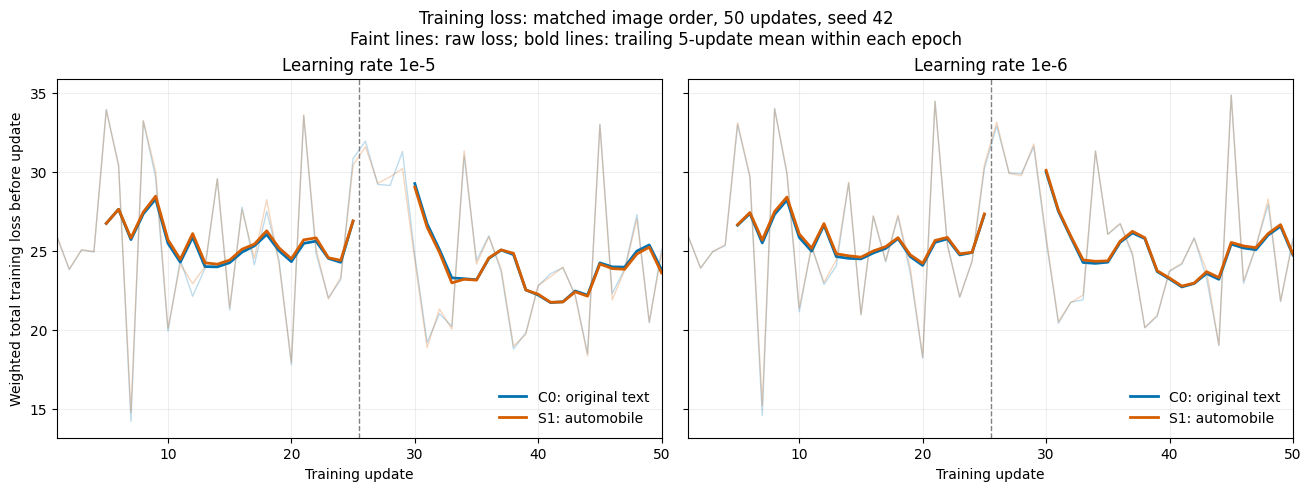

All four histories passed the checks.
Plots and supporting data saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/report_summary
No model loaded. No training performed.


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)

runs = {
    ("1e-5", "C0"): "C0_20260918_221107_131368",
    ("1e-5", "S1"): "S1_20260918_222212_565852",
    ("1e-6", "C0"): "C0_lr1e6_20260918_232001_922343",
    ("1e-6", "S1"): "S1_lr1e6_20260918_234731_452673",
}

output = root / "report_summary"
output.mkdir(parents=True, exist_ok=True)

histories = {}
combined_rows = []
reference_order = None

for (learning_rate, condition), folder in runs.items():
    path = root / folder / "history.json"
    assert path.is_file(), f"Missing: {path}"

    history = json.loads(path.read_text())
    assert [row["step"] for row in history] == list(range(1, 51))
    assert all(
        np.isfinite(row["total_loss_before_update"]) for row in history
    )

    image_order = [row["images"] for row in history]
    if reference_order is None:
        reference_order = image_order
    else:
        assert image_order == reference_order, "Image-order mismatch."

    frame = pd.DataFrame({
        "step": [row["step"] for row in history],
        "epoch": [row["epoch"] for row in history],
        "loss": [row["total_loss_before_update"] for row in history],
    })

    # Trailing five-update mean, calculated separately within each epoch.
    frame["loss_5_step_mean"] = frame.groupby("epoch")["loss"].transform(
        lambda values: values.rolling(5, min_periods=5).mean()
    )

    histories[(learning_rate, condition)] = frame

    for row in history:
        combined_rows.append({
            "learning_rate": learning_rate,
            "condition": condition,
            "step": row["step"],
            "epoch": row["epoch"],
            "total_loss_before_update": row["total_loss_before_update"],
        })

colors = {"C0": "#0072B2", "S1": "#D55E00"}
labels = {"C0": "C0: original text", "S1": "S1: automobile"}

fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.8), sharex=True, sharey=True,
    layout="constrained"
)

for axis, learning_rate in zip(axes, ("1e-5", "1e-6")):
    for condition in ("C0", "S1"):
        frame = histories[(learning_rate, condition)]

        axis.plot(
            frame["step"], frame["loss"],
            color=colors[condition], alpha=0.25, linewidth=1,
        )
        axis.plot(
            frame["step"], frame["loss_5_step_mean"],
            color=colors[condition], linewidth=2,
            label=labels[condition],
        )

    axis.axvline(25.5, color="grey", linestyle="--", linewidth=1)
    axis.set_title(f"Learning rate {learning_rate}")
    axis.set_xlabel("Training update")
    axis.set_xlim(1, 50)
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)

axes[0].set_ylabel("Weighted total training loss before update")
fig.suptitle(
    "Training loss: matched image order, 50 updates, seed 42\n"
    "Faint lines: raw loss; bold lines: trailing 5-update mean within each epoch",
    fontsize=12
)

fig.savefig(output / "training_loss_comparison.png", dpi=300)
fig.savefig(output / "training_loss_comparison.pdf")
plt.show()
plt.close(fig)

combined = pd.DataFrame(combined_rows)
combined.to_csv(output / "training_loss_values.csv", index=False)

epoch_summary = (
    combined.groupby(["learning_rate", "condition", "epoch"], sort=False)
    ["total_loss_before_update"]
    .agg(["mean", "min", "max"])
    .reset_index()
)
epoch_summary.to_csv(output / "training_loss_epoch_summary.csv", index=False)

plot_notes = {
    "source_files": [
        str(root / folder / "history.json") for folder in runs.values()
    ],
    "loss": "Weighted total training loss, recorded before each update",
    "smoothing": "Trailing 5-update mean, reset at each epoch boundary",
    "dashed_line": "Boundary between epochs 1 and 2",
    "checks": "50 finite losses per run; identical image order across runs",
    "limitations": [
        "Different updates contain different image pairs.",
        "Variation across batches is not uncertainty across training seeds.",
        "Training loss alone does not establish segmentation improvement.",
    ],
}
(output / "training_loss_plot_notes.json").write_text(
    json.dumps(plot_notes, indent=2), encoding="utf-8"
)

print("All four histories passed the checks.")
print("Plots and supporting data saved:", output)
print("No model loaded. No training performed.")

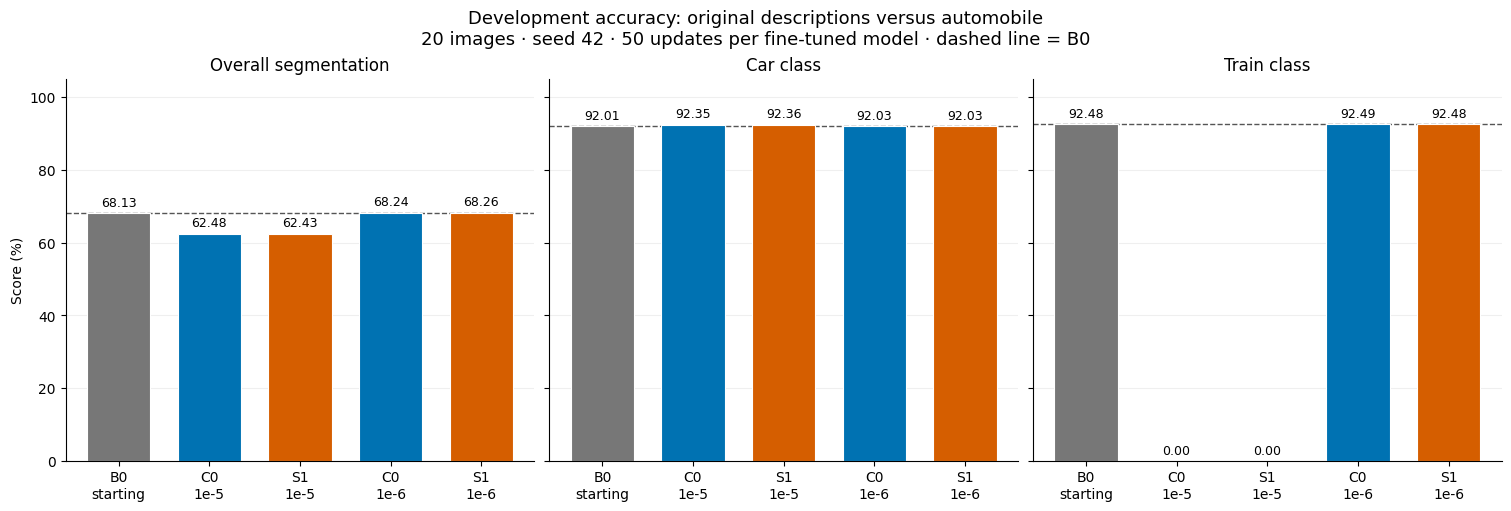


SYNONYM DIFFERENCES — percentage points
Learning rate  S1 minus C0 mIoU (pp)  S1 minus C0 car IoU (pp)  S1 minus C0 train IoU (pp)
         1e-5                -0.0510                   +0.0172                     +0.0000
         1e-6                +0.0132                   -0.0025                     -0.0091

Figures and supporting files saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/report_summary
No model loaded. No training performed.


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
output = root / "report_summary"

table = pd.read_csv(
    output / "completed_experiments.csv",
    dtype={"Learning rate": str}
)

# Explicit order: starting model, original-rate pair, lower-rate pair.
selection = [
    ("B0", "—"),
    ("C0", "1e-5"),
    ("S1", "1e-5"),
    ("C0", "1e-6"),
    ("S1", "1e-6"),
]

ordered = []
for condition, rate in selection:
    matched = table[
        (table["Condition"] == condition)
        & (table["Learning rate"] == rate)
    ]
    assert len(matched) == 1, f"Missing or duplicate row: {condition}, {rate}"
    ordered.append(matched.iloc[0])

data = pd.DataFrame(ordered).reset_index(drop=True)

labels = [
    "B0\nstarting",
    "C0\n1e-5",
    "S1\n1e-5",
    "C0\n1e-6",
    "S1\n1e-6",
]
colors = ["#777777", "#0072B2", "#D55E00", "#0072B2", "#D55E00"]

metrics = [
    ("mIoU (%)", "Overall segmentation"),
    ("Car IoU (%)", "Car class"),
    ("Train IoU (%)", "Train class"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5), sharey=True,
    layout="constrained"
)

for axis, (column, title) in zip(axes, metrics):
    values = data[column].to_numpy(dtype=float)
    assert np.isfinite(values).all()

    bars = axis.bar(
        np.arange(5), values,
        color=colors, width=0.7,
        edgecolor="white", linewidth=0.8
    )

    baseline = values[0]
    axis.axhline(
        baseline, color="#555555",
        linestyle="--", linewidth=1, zorder=0
    )
    axis.bar_label(
        bars, labels=[f"{value:.2f}" for value in values],
        padding=3, fontsize=9
    )

    axis.set_xticks(np.arange(5), labels)
    axis.set_ylim(0, 105)
    axis.set_yticks(np.arange(0, 101, 20))
    axis.set_title(title)
    axis.set_axisbelow(True)
    axis.grid(axis="y", alpha=0.2)
    axis.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Score (%)")

fig.suptitle(
    "Development accuracy: original descriptions versus automobile\n"
    "20 images · seed 42 · 50 updates per fine-tuned model · "
    "dashed line = B0",
    fontsize=13
)

fig.savefig(output / "development_accuracy_comparison.png", dpi=300)
fig.savefig(output / "development_accuracy_comparison.pdf")
plt.show()
plt.close(fig)

# Keep the small wording differences visible numerically.
difference_rows = []
for rate in ("1e-5", "1e-6"):
    c0 = data[
        (data["Condition"] == "C0") & (data["Learning rate"] == rate)
    ].iloc[0]
    s1 = data[
        (data["Condition"] == "S1") & (data["Learning rate"] == rate)
    ].iloc[0]

    difference_rows.append({
        "Learning rate": rate,
        "S1 minus C0 mIoU (pp)": s1["mIoU (%)"] - c0["mIoU (%)"],
        "S1 minus C0 car IoU (pp)": s1["Car IoU (%)"] - c0["Car IoU (%)"],
        "S1 minus C0 train IoU (pp)": (
            s1["Train IoU (%)"] - c0["Train IoU (%)"]
        ),
    })

differences = pd.DataFrame(difference_rows)
differences.to_csv(
    output / "wording_effect_percentage_points.csv", index=False
)

notes = {
    "data_source": str(output / "completed_experiments.csv"),
    "bar_labels": "Scores rounded to two decimal places",
    "axes": "Common zero-based percentage scale",
    "dashed_lines": "Starting-model score for the corresponding metric",
    "error_bars": "Not shown: only one training seed is available",
    "scope": "20-image development subset; not independent final testing",
    "train_class_support": "One development instance",
    "learning_rate_selection": (
        "The lower rate was investigated after inspecting initial results."
    ),
}
(output / "accuracy_figure_notes.json").write_text(
    json.dumps(notes, indent=2), encoding="utf-8"
)

print("\nSYNONYM DIFFERENCES — percentage points")
print(differences.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))
print("\nFigures and supporting files saved:", output)
print("No model loaded. No training performed.")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version, PackageNotFoundError
import platform
import json
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "NOT INSTALLED"

environment = {
    "python": platform.python_version(),
    "torch": str(torch.__version__),
    "torch_cuda_build": torch.version.cuda,
    "transformers": package_version("transformers"),
    "gpu_available": torch.cuda.is_available(),
}

print("CURRENT ENVIRONMENT")
print(json.dumps(environment, indent=2))

assert torch.cuda.is_available(), (
    "The GPU is assigned, but PyTorch cannot use it. "
    "Send this output before installing anything."
)

# Check an actual operation on the GPU.
test = torch.tensor([1.0, 2.0], device="cuda")
assert (test * 2).cpu().tolist() == [2.0, 4.0]
del test

environment["gpu"] = torch.cuda.get_device_name(0)
environment["cuda_operation_passed"] = True

settings = json.loads((pilot_run / "settings.json").read_text())
previous = settings["environment"]

print("\nVERSION COMPARISON")
versions_match = True
for key in ("python", "torch", "transformers"):
    matched = environment[key] == previous[key]
    versions_match = versions_match and matched
    print(
        f"{key}: previous={previous[key]} | "
        f"current={environment[key]} | match={matched}"
    )

preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
missing = [
    row["prepared_file"]
    for row in preparation["records"]
    if not Path(row["prepared_file"]).is_file()
]

environment["versions_match_previous_run"] = versions_match
environment["prepared_training_files_found"] = (
    len(preparation["records"]) - len(missing)
)
environment["missing_prepared_files"] = missing

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
report_path = pilot_run / f"restart_environment_{stamp}.json"
report_path.write_text(
    json.dumps(environment, indent=2), encoding="utf-8"
)

print("\nGPU operation: PASSED")
print("GPU:", environment["gpu"])
print("Prepared training files found:",
      environment["prepared_training_files_found"], "/ 50")
print("Environment report saved:", report_path)

if missing:
    print("Missing files:", missing)
elif not versions_match:
    print("Review version differences before starting new experiments.")
else:
    print("Environment checks passed. Ready to restore the model.")

print("No model loaded. No training performed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CURRENT ENVIRONMENT
{
  "python": "3.13.15",
  "torch": "2.11.0+cu128",
  "torch_cuda_build": "12.8",
  "transformers": "5.16.1",
  "gpu_available": true
}

VERSION COMPARISON
python: previous=3.13.15 | current=3.13.15 | match=True
torch: previous=2.11.0+cu128 | current=2.11.0+cu128 | match=True
transformers: previous=5.16.1 | current=5.16.1 | match=True

GPU operation: PASSED
GPU: Tesla T4
Prepared training files found: 50 / 50
Environment report saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/restart_environment_20260919_114316.json
Environment checks passed. Ready to restore the model.
No model loaded. No training performed.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import platform
import torch
import transformers
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"
original_pilot = project / "pilots/two_image_optimizer_20260917_211825_497623"
c0_low_folder = pilot_run / "C0_lr1e6_20260918_232001_922343"

settings = json.loads((pilot_run / "settings.json").read_text())
preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
expected_names = json.loads(
    (c0_low_folder / "trainable_parameter_names.json").read_text()
)

assert torch.cuda.is_available(), "A working GPU is required."
assert len(preparation["records"]) == 50

for record in preparation["records"]:
    path = Path(record["prepared_file"])
    assert path.is_file(), f"Missing prepared training file: {path}"

# Construct the training architecture, including its text mapper.
config = OneFormerConfig.from_pretrained(
    original_pilot / "model_config",
    local_files_only=True,
)
assert config.is_training is True

audit_model = OneFormerForUniversalSegmentation(config)

# Load the common starting weights, not a fine-tuned checkpoint.
state = torch.load(
    settings["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
audit_model.load_state_dict(state, strict=True)
del state

assert audit_model.model.text_mapper is not None
encoder = audit_model.model.text_mapper.text_encoder

# Reapply the previously verified causal-mask correction.
# Hooks are not restored by loading a state dictionary.
def supply_causal_mask(module, args, kwargs):
    query = args[0]
    length = query.shape[1] if module.batch_first else query.shape[0]

    causal_mask = torch.full(
        (length, length),
        float("-inf"),
        dtype=query.dtype,
        device=query.device,
    ).triu(1)

    kwargs = dict(kwargs)
    kwargs["attn_mask"] = causal_mask
    return args, kwargs

layers = list(encoder.transformer.layers)
assert len(layers) == 6

encoder._project_causal_mask_handles = [
    layer.self_attn.register_forward_pre_hook(
        supply_causal_mask, with_kwargs=True
    )
    for layer in layers
]

# Restore precisely the parameter selection used in the earlier runs.
expected_set = set(expected_names)
for name, parameter in audit_model.named_parameters():
    parameter.requires_grad_(name in expected_set)

actual_names = [
    name for name, parameter in audit_model.named_parameters()
    if parameter.requires_grad
]
assert actual_names == expected_names

audit_model.to(device="cuda", dtype=torch.float32)
audit_model.train()
audit_model.model.pixel_level_module.encoder.eval()
model = audit_model

# Restore the processor for later evaluation and text handling.
training_processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_cityscapes_swin_large"
)
training_processor.image_processor.num_text = (
    config.num_queries
    - audit_model.model.text_mapper.prompt_ctx.num_embeddings
)

def make_training_batch(indices, condition):
    assert condition in ("C0", "S1")
    samples = []

    for index in indices:
        saved = torch.load(
            preparation["records"][index]["prepared_file"],
            map_location="cpu",
            weights_only=True,
        )
        inputs = dict(saved["inputs"])

        if condition == "S1":
            inputs["text_inputs"] = saved["s1_text_inputs"]

        samples.append(inputs)

    device = next(audit_model.parameters()).device
    batch = {}

    for key in samples[0]:
        values = [sample[key] for sample in samples]

        if torch.is_tensor(values[0]):
            batch[key] = torch.cat(values, dim=0).to(device)
        elif key in ("mask_labels", "class_labels"):
            batch[key] = [
                tensor.to(device)
                for tensor_list in values
                for tensor in tensor_list
            ]
        else:
            raise TypeError(f"Unexpected batch field: {key}")

    return batch

# Check that a prepared batch can be loaded onto the GPU.
probe = make_training_batch([0, 1], "C0")
assert tuple(probe["pixel_values"].shape) == (2, 3, 256, 512)
assert tuple(probe["text_inputs"].shape) == (2, 234, 77)

restoration = {
    "python": platform.python_version(),
    "torch": str(torch.__version__),
    "transformers": transformers.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "starting_weights": settings["common_initial_weights"],
    "strict_weight_loading": True,
    "causal_mask_hooks": len(encoder._project_causal_mask_handles),
    "prepared_training_files_found": len(preparation["records"]),
    "trainable_parameter_names_match": True,
    "pixel_shape": list(probe["pixel_values"].shape),
    "text_shape": list(probe["text_inputs"].shape),
    "optimizer_updates_performed": 0,
}

del probe
audit_model.zero_grad(set_to_none=True)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
report_path = pilot_run / f"model_restoration_{stamp}.json"
report_path.write_text(
    json.dumps(restoration, indent=2), encoding="utf-8"
)

print("RESTORATION COMPLETE")
print("Common starting weights: loaded strictly")
print("Causal-mask correction hooks:", restoration["causal_mask_hooks"])
print("Prepared training files:", restoration["prepared_training_files_found"])
print("Trainable parameter selection: matches previous runs")
print("GPU batch shape:", restoration["pixel_shape"])
print("Text shape:", restoration["text_shape"])
print("Report saved:", report_path)
print("No training performed.")

preprocessor_config.json:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/77.7k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

RESTORATION COMPLETE
Common starting weights: loaded strictly
Causal-mask correction hooks: 6
Prepared training files: 50
Trainable parameter selection: matches previous runs
GPU batch shape: [2, 3, 256, 512]
Text shape: [2, 234, 77]
Report saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/model_restoration_20260919_114454.json
No training performed.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from PIL import Image
import json
import zipfile
import numpy as np
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
local = Path("/content/cityscapes")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)
assert len(manifest["holdout"]) == 20

def strings_in(value):
    if isinstance(value, str):
        yield value
    elif isinstance(value, dict):
        for item in value.values():
            yield from strings_in(item)
    elif isinstance(value, list):
        for item in value:
            yield from strings_in(item)

def member_for(record, prefix, suffix):
    matches = set()
    for value in strings_in(record):
        if prefix in value and value.endswith(suffix):
            member = value[value.index(prefix):]
            assert ".." not in Path(member).parts
            matches.add(member)
    assert len(matches) == 1, f"Ambiguous file reference: {record}"
    return matches.pop()

# Restore only missing development files from the existing archives.
archive_specs = [
    ("leftImg8bit_trainvaltest.zip",
     "leftImg8bit/train/", "_leftImg8bit.png"),
    ("gtFine_trainvaltest.zip",
     "gtFine/train/", "_gtFine_instanceIds.png"),
]

for archive_name, prefix, suffix in archive_specs:
    members = [
        member_for(record, prefix, suffix)
        for record in manifest["holdout"]
    ]
    missing = [member for member in members if not (local / member).is_file()]

    if missing:
        archives = list(project.rglob(archive_name))
        assert len(archives) == 1, (
            f"Expected one {archive_name}; found: {archives}"
        )
        with zipfile.ZipFile(archives[0]) as archive:
            available = set(archive.namelist())
            for member in missing:
                assert member in available, f"Missing archive member: {member}"
                destination = local / member
                destination.parent.mkdir(parents=True, exist_ok=True)
                with archive.open(member) as source:
                    destination.write_bytes(source.read())

    print(f"{archive_name}: all 20 required files available")

def resolve_file(record, suffix):
    prefix = (
        "leftImg8bit/train/"
        if suffix == "_leftImg8bit.png" else "gtFine/train/"
    )
    path = local / member_for(record, prefix, suffix)
    assert path.is_file(), path
    return path

class_names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

def evaluate_development(model, condition):
    stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
    folder = pilot_run / f"evaluation_{condition}_{stamp}"
    prediction_folder = folder / "predictions"
    prediction_folder.mkdir(parents=True, exist_ok=False)

    device = next(model.parameters()).device
    modes = [(module, module.training) for module in model.modules()]
    flags = [
        (module, module.is_training)
        for module in model.modules()
        if isinstance(getattr(module, "is_training", None), bool)
    ]

    matrices = []
    image_names = []

    try:
        model.eval()
        for module, _ in flags:
            module.is_training = False

        with torch.inference_mode():
            for index, record in enumerate(manifest["holdout"]):
                image_path = resolve_file(record, "_leftImg8bit.png")
                label_path = resolve_file(record, "_gtFine_instanceIds.png")

                with Image.open(image_path) as source:
                    image = source.convert("RGB")
                    width, height = image.size
                    image = image.resize(
                        (512, 256), Image.Resampling.BILINEAR
                    )

                with Image.open(label_path) as source:
                    raw = np.array(source, dtype=np.int32)

                assert raw.shape == (height, width)
                semantic = np.where(raw >= 1000, raw // 1000, raw)
                target = np.full(raw.shape, 255, dtype=np.int32)

                for train_id, label_id in enumerate(original_ids):
                    target[semantic == label_id] = train_id

                encoded = training_processor(
                    images=image,
                    task_inputs=["semantic"],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in encoded.items()
                    if key in ("pixel_values", "task_inputs", "pixel_mask")
                }
                outputs = model(**inputs, return_dict=True)
                prediction = (
                    training_processor.post_process_semantic_segmentation(
                        outputs, target_sizes=[(height, width)]
                    )[0].cpu().numpy().astype(np.int32)
                )

                assert prediction.shape == target.shape
                assert prediction.min() >= 0 and prediction.max() < 19

                valid = target != 255
                matrix = np.bincount(
                    19 * target[valid] + prediction[valid],
                    minlength=19 * 19,
                ).reshape(19, 19)

                matrices.append(matrix)
                image_names.append(image_path.name)

                Image.fromarray(prediction.astype(np.uint8)).save(
                    prediction_folder / image_path.name.replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                )
                del outputs, inputs, encoded, prediction
                print(f"Evaluated {index + 1}/20")
    finally:
        for module, flag in flags:
            module.is_training = flag
        for module, mode in modes:
            module.training = mode

    confusion = np.stack(matrices).sum(axis=0)
    intersection = np.diag(confusion).astype(np.float64)
    union = confusion.sum(axis=0) + confusion.sum(axis=1) - intersection
    iou = np.divide(
        intersection, union,
        out=np.full(19, np.nan), where=union > 0
    )

    result = {
        "condition": condition,
        "images": image_names,
        "number_of_images": len(image_names),
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "original annotation resolution",
        "task": "semantic",
        "ground_truth_ignore_id": 255,
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "aggregation": "pooled pixel confusion matrix across all 20 images",
        "miou_percent": float(100 * np.nanmean(iou)),
        "classes_with_nonzero_union": int((union > 0).sum()),
        "car_iou_percent": (
            float(100 * iou[13]) if np.isfinite(iou[13]) else None
        ),
        "class_iou_percent": {
            name: float(100 * score) if np.isfinite(score) else None
            for name, score in zip(class_names, iou)
        },
        "evaluation_folder": str(folder),
        "interpretation": (
            "Development subset from Cityscapes train; "
            "not an independent test of the pretrained model."
        ),
    }

    np.save(folder / "confusion_matrix.npy", confusion)
    np.save(folder / "per_image_confusion_matrices.npy", np.stack(matrices))
    (folder / "metrics.json").write_text(
        json.dumps(result, indent=2, allow_nan=False), encoding="utf-8"
    )

    print(f"\n{condition}: mIoU = {result['miou_percent']:.4f}%")
    print("Results saved:", folder)
    return result

# The preceding restoration cell loaded the common starting weights.
restored_baseline = evaluate_development(audit_model, "B0_restart_check")

previous_folder = (
    pilot_run / "evaluation_B0_common_start_20260918_220810_029825"
)
previous_metrics = json.loads((previous_folder / "metrics.json").read_text())
assert restored_baseline["images"] == previous_metrics["images"]

previous_matrices = np.load(
    previous_folder / "per_image_confusion_matrices.npy"
)
current_matrices = np.load(
    Path(restored_baseline["evaluation_folder"])
    / "per_image_confusion_matrices.npy"
)

matched = bool(np.array_equal(previous_matrices, current_matrices))
check = {
    "previous_miou": previous_metrics["miou_percent"],
    "restored_miou": restored_baseline["miou_percent"],
    "all_per_image_confusion_matrices_equal": matched,
    "restored_evaluation_folder": restored_baseline["evaluation_folder"],
}

check_path = (
    Path(restored_baseline["evaluation_folder"]) / "restart_comparison.json"
)
check_path.write_text(json.dumps(check, indent=2), encoding="utf-8")

print("\nRESTART COMPARISON")
print("Previous mIoU:", check["previous_miou"])
print("Restored mIoU:", check["restored_miou"])
print("All per-image confusion matrices identical:", matched)
print("Check saved:", check_path)
print("No training performed.")

if not matched:
    print("Review these differences before beginning the new seed runs.")

leftImg8bit_trainvaltest.zip: all 20 required files available
gtFine_trainvaltest.zip: all 20 required files available
Evaluated 1/20
Evaluated 2/20
Evaluated 3/20
Evaluated 4/20
Evaluated 5/20
Evaluated 6/20
Evaluated 7/20
Evaluated 8/20
Evaluated 9/20
Evaluated 10/20
Evaluated 11/20
Evaluated 12/20
Evaluated 13/20
Evaluated 14/20
Evaluated 15/20
Evaluated 16/20
Evaluated 17/20
Evaluated 18/20
Evaluated 19/20
Evaluated 20/20

B0_restart_check: mIoU = 68.1342%
Results saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/evaluation_B0_restart_check_20260919_114916_592600

RESTART COMPARISON
Previous mIoU: 68.13423545715237
Restored mIoU: 68.13423545715237
All per-image confusion matrices identical: True
Check saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/evaluation_B0_restart_check_20260919_114916_592600/restart_comparison.json
No training performed.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json
import random
import shutil
import numpy as np
import pandas as pd
import torch
from IPython.display import display

assert callable(globals().get("make_training_batch"))
assert callable(globals().get("evaluate_development"))
assert torch.cuda.is_available()

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"
reference_folder = pilot_run / "C0_lr1e6_20260918_232001_922343"

reference = json.loads(
    (reference_folder / "evaluation_and_comparison.json").read_text()
)
base_settings = reference["settings"]
schedule = json.loads((pilot_run / "batch_schedule.json").read_text())
preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
manifest = json.loads(
    (pilot_run / "pilot_50_train_20_holdout.json").read_text()
)
expected_names = json.loads(
    (reference_folder / "trainable_parameter_names.json").read_text()
)

assert base_settings["learning_rate"] == 1e-6
assert len(schedule) == 50
assert schedule == json.loads(
    (reference_folder / "batch_schedule.json").read_text()
)

SEED = 43
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
seed_folder = pilot_run / f"matched_seed{SEED}_{stamp}"
seed_folder.mkdir(parents=True, exist_ok=False)

run_settings = dict(base_settings)
run_settings.update({
    "experiment": "Matched C0-S1 repeat",
    "training_seed_each_condition": SEED,
    "image_order_seed": 42,
    "image_order_policy": "Same saved schedule as the seed-42 pilot",
    "changed_factor": "Training random seed relative to the lower-rate pilot",
    "analysis_type": "Additional-seed development experiment",
    "text_condition": "C0 and S1 run separately",
})

(seed_folder / "settings.json").write_text(
    json.dumps(run_settings, indent=2), encoding="utf-8"
)
shutil.copy2(
    pilot_run / "batch_schedule.json",
    seed_folder / "batch_schedule.json",
)
shutil.copy2(
    reference_folder / "trainable_parameter_names.json",
    seed_folder / "trainable_parameter_names.json",
)

def cpu_copy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {key: cpu_copy(item) for key, item in value.items()}
    if isinstance(value, list):
        return [cpu_copy(item) for item in value]
    if isinstance(value, tuple):
        return tuple(cpu_copy(item) for item in value)
    return value

def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_checkpoint(model, opt, condition, step, history, folder):
    cpu_rng = torch.get_rng_state().clone()
    cuda_rng = [value.clone() for value in torch.cuda.get_rng_state_all()]

    payload = {
        "condition": condition,
        "seed": SEED,
        "completed_steps": step,
        "model": cpu_copy(model.state_dict()),
        "optimizer": cpu_copy(opt.state_dict()),
        "torch_rng_state": cpu_rng,
        "cuda_rng_states": cuda_rng,
        "settings": run_settings,
        "trainable_parameter_names": expected_names,
        "history": list(history),
    }

    local_path = Path(
        f"/content/seed{SEED}_{condition}_{stamp}_{step:03d}.pt"
    )
    destination = folder / f"step_{step:03d}.pt"
    partial = destination.with_suffix(".pt.partial")

    try:
        torch.save(payload, local_path)
        shutil.copyfile(local_path, partial)
        digest = sha256(local_path)
        assert sha256(partial) == digest

        checked = torch.load(
            partial, map_location="cpu", weights_only=True
        )
        assert checked["condition"] == condition
        assert checked["seed"] == SEED
        assert checked["completed_steps"] == step
        assert checked["optimizer"]["state"]
        assert checked["model"].keys() == payload["model"].keys()
        assert all(
            torch.equal(payload["model"][key], checked["model"][key])
            for key in payload["model"]
        )
        del checked
        partial.replace(destination)

        verification = {
            "condition": condition,
            "seed": SEED,
            "step": step,
            "checkpoint": str(destination),
            "sha256": digest,
            "model_tensor_readback_equal": True,
        }
        (folder / f"verification_{step:03d}.json").write_text(
            json.dumps(verification, indent=2), encoding="utf-8"
        )
        print(f"{condition}: checkpoint {step} saved and read-checked")
    finally:
        torch.set_rng_state(cpu_rng)
        torch.cuda.set_rng_state_all(cuda_rng)

    del payload
    local_path.unlink(missing_ok=True)
    gc.collect()

def train_and_evaluate(condition):
    folder = seed_folder / condition
    folder.mkdir(exist_ok=False)

    model = audit_model
    model.zero_grad(set_to_none=True)

    # Reset BOTH conditions independently to the same starting weights.
    initial = torch.load(
        run_settings["common_initial_weights"],
        map_location="cpu",
        weights_only=True,
    )
    model.load_state_dict(initial, strict=True)
    del initial
    model.to(device="cuda", dtype=torch.float32)

    encoder = model.model.text_mapper.text_encoder
    assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
    assert model.model.is_training

    expected_set = set(expected_names)
    for name, parameter in model.named_parameters():
        parameter.requires_grad_(name in expected_set)

    actual_names = [
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names

    parameters = [
        parameter for parameter in model.parameters()
        if parameter.requires_grad
    ]
    model.train()
    model.model.pixel_level_module.encoder.eval()

    opt = torch.optim.AdamW(
        parameters,
        lr=run_settings["learning_rate"],
        weight_decay=run_settings["weight_decay"],
        betas=tuple(run_settings["betas"]),
        eps=run_settings["eps"],
        foreach=run_settings["foreach"],
    )

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.reset_peak_memory_stats()

    history = []
    print(f"\nStarting {condition}, seed {SEED}, learning rate 1e-6")

    for entry in schedule:
        step = entry["step"]
        batch = make_training_batch(entry["indices"], condition)
        opt.zero_grad(set_to_none=True)

        outputs = model(**batch, return_dict=True)
        loss = outputs.loss
        assert loss is not None and torch.isfinite(loss).item()
        loss_value = float(loss.detach())

        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            parameters,
            run_settings["gradient_clip_max_norm"],
            error_if_nonfinite=True,
        )
        opt.step()
        opt.zero_grad(set_to_none=True)

        history.append({
            "step": step,
            "epoch": entry["epoch"],
            "images": entry["images"],
            "total_loss_before_update": loss_value,
            "gradient_norm_before_clipping": float(gradient_norm),
            "peak_gpu_allocated_GiB": (
                torch.cuda.max_memory_allocated() / 1024**3
            ),
        })

        temporary = folder / "history.json.partial"
        temporary.write_text(
            json.dumps(history, indent=2), encoding="utf-8"
        )
        temporary.replace(folder / "history.json")

        print(f"{condition} seed {SEED}: {step:02d}/50 | loss={loss_value:.4f}")
        del outputs, loss, batch, gradient_norm

        if step in run_settings["checkpoint_steps"]:
            save_checkpoint(model, opt, condition, step, history, folder)

    del opt
    gc.collect()
    torch.cuda.empty_cache()

    metrics = evaluate_development(
        model, f"{condition}_lr1e6_seed{SEED}_step50"
    )

    for key in (
        "images", "task", "input_size_width_height",
        "evaluation_resolution", "aggregation",
    ):
        assert metrics[key] == reference["metrics"][key], key
    assert metrics["classes_with_nonzero_union"] == 19

    (folder / "evaluation.json").write_text(
        json.dumps({
            "condition": condition,
            "seed": SEED,
            "checkpoint": str(folder / "step_050.pt"),
            "settings": run_settings,
            "metrics": metrics,
        }, indent=2),
        encoding="utf-8",
    )
    return metrics

# Release any optimizer retained from earlier notebook cells.
optimizer = None
gc.collect()
torch.cuda.empty_cache()

seed43_results = {}
for condition in ("C0", "S1"):
    seed43_results[condition] = train_and_evaluate(condition)

rows = [{
    "Condition": condition,
    "Seed": SEED,
    "Learning rate": "1e-6",
    "mIoU (%)": metrics["miou_percent"],
    "Car IoU (%)": metrics["car_iou_percent"],
    "Train IoU (%)": metrics["class_iou_percent"]["train"],
} for condition, metrics in seed43_results.items()]

differences = {
    "miou": (
        seed43_results["S1"]["miou_percent"]
        - seed43_results["C0"]["miou_percent"]
    ),
    "car_iou": (
        seed43_results["S1"]["car_iou_percent"]
        - seed43_results["C0"]["car_iou_percent"]
    ),
}

pd.DataFrame(rows).to_csv(
    seed_folder / "matched_comparison.csv", index=False
)
(seed_folder / "matched_comparison.json").write_text(
    json.dumps({
        "seed": SEED,
        "settings": run_settings,
        "results": seed43_results,
        "S1_minus_C0_percentage_points": differences,
    }, indent=2),
    encoding="utf-8",
)

print("\nSEED 43 MATCHED EXPERIMENT COMPLETE")
display(pd.DataFrame(rows).round(4))
print(f"S1 minus C0 mIoU: {differences['miou']:+.4f} percentage points")
print(f"S1 minus C0 car IoU: {differences['car_iou']:+.4f} percentage points")
print("All files saved:", seed_folder)
print("Working model now contains S1 seed-43 final weights.")


Starting C0, seed 43, learning rate 1e-6
C0 seed 43: 01/50 | loss=26.0895
C0 seed 43: 02/50 | loss=23.4896
C0 seed 43: 03/50 | loss=25.0232
C0 seed 43: 04/50 | loss=25.8091
C0 seed 43: 05/50 | loss=33.3606
C0 seed 43: 06/50 | loss=29.9946
C0 seed 43: 07/50 | loss=14.5838
C0 seed 43: 08/50 | loss=34.2410
C0 seed 43: 09/50 | loss=30.0718
C0 seed 43: 10/50 | loss=21.0356
C0 seed 43: 11/50 | loss=25.1761
C0 seed 43: 12/50 | loss=22.5405
C0 seed 43: 13/50 | loss=24.4029
C0 seed 43: 14/50 | loss=29.9395
C0 seed 43: 15/50 | loss=20.3481
C0 seed 43: 16/50 | loss=27.9703
C0 seed 43: 17/50 | loss=24.6824
C0 seed 43: 18/50 | loss=29.0579
C0 seed 43: 19/50 | loss=24.3208
C0 seed 43: 20/50 | loss=18.1864
C0 seed 43: 21/50 | loss=32.5145
C0 seed 43: 22/50 | loss=25.5211
C0 seed 43: 23/50 | loss=21.8568
C0 seed 43: 24/50 | loss=24.4459
C0 seed 43: 25/50 | loss=30.4380
C0: checkpoint 25 saved and read-checked
C0 seed 43: 26/50 | loss=32.2367
C0 seed 43: 27/50 | loss=30.4161
C0 seed 43: 28/50 | loss=2

,Condition,Seed,Learning rate,mIoU (%),Car IoU (%),Train IoU (%)
0,C0,43,1e-6,68.2211,92.0193,92.4834
1,S1,43,1e-6,68.2304,92.0176,92.4878


S1 minus C0 mIoU: +0.0093 percentage points
S1 minus C0 car IoU: -0.0017 percentage points
All files saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/matched_seed43_20260919_115234_749725
Working model now contains S1 seed-43 final weights.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import shutil
import pandas as pd

assert callable(globals().get("train_and_evaluate")), (
    "The seed-43 training function must be loaded in this session."
)
assert callable(globals().get("save_checkpoint"))

# Preserve the exact settings from seed 43.
seed43_folder = Path(seed_folder)
seed43_settings = json.loads(
    (seed43_folder / "settings.json").read_text()
)
assert seed43_settings["training_seed_each_condition"] == 43
assert (seed43_folder / "matched_comparison.json").is_file()

# These variables are used by the existing training/checkpoint functions.
SEED = 44
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
seed_folder = pilot_run / f"matched_seed{SEED}_{stamp}"
seed_folder.mkdir(parents=True, exist_ok=False)

run_settings = dict(seed43_settings)
run_settings["training_seed_each_condition"] = SEED

(seed_folder / "settings.json").write_text(
    json.dumps(run_settings, indent=2), encoding="utf-8"
)
shutil.copy2(
    seed43_folder / "batch_schedule.json",
    seed_folder / "batch_schedule.json",
)
shutil.copy2(
    seed43_folder / "trainable_parameter_names.json",
    seed_folder / "trainable_parameter_names.json",
)

assert run_settings["learning_rate"] == 1e-6
assert schedule == json.loads(
    (seed_folder / "batch_schedule.json").read_text()
)

print("Starting seed 44.")
print("Same common starting weights, image order and learning rate.")
print("Each condition will independently train for 50 updates.")

seed44_results = {}
for condition in ("C0", "S1"):
    seed44_results[condition] = train_and_evaluate(condition)

differences = {
    "miou": (
        seed44_results["S1"]["miou_percent"]
        - seed44_results["C0"]["miou_percent"]
    ),
    "car_iou": (
        seed44_results["S1"]["car_iou_percent"]
        - seed44_results["C0"]["car_iou_percent"]
    ),
}

rows = [{
    "Condition": condition,
    "Seed": SEED,
    "Learning rate": "1e-6",
    "mIoU (%)": metrics["miou_percent"],
    "Car IoU (%)": metrics["car_iou_percent"],
    "Train IoU (%)": metrics["class_iou_percent"]["train"],
} for condition, metrics in seed44_results.items()]

pd.DataFrame(rows).to_csv(
    seed_folder / "matched_comparison.csv", index=False
)
(seed_folder / "matched_comparison.json").write_text(
    json.dumps({
        "seed": SEED,
        "settings": run_settings,
        "results": seed44_results,
        "S1_minus_C0_percentage_points": differences,
    }, indent=2),
    encoding="utf-8",
)

print("\nSEED 44 COMPLETE")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print(f"S1 minus C0 mIoU: {differences['miou']:+.4f} percentage points")
print(f"S1 minus C0 car IoU: {differences['car_iou']:+.4f} percentage points")
print("Saved folder:", seed_folder)

# Summarize seeds 42, 43 and 44 using full-precision saved results.
seed42_path = (
    pilot_run / "S1_lr1e6_20260918_234731_452673"
    / "evaluation_and_comparison.json"
)
seed42_saved = json.loads(seed42_path.read_text())
seed43_saved = json.loads(
    (seed43_folder / "matched_comparison.json").read_text()
)

results_by_seed = {
    42: {
        "C0": seed42_saved["C0_metrics"],
        "S1": seed42_saved["S1_metrics"],
    },
    43: seed43_saved["results"],
    44: seed44_results,
}

reference_metrics = results_by_seed[42]["C0"]
individual_rows = []
paired_rows = []

for seed, results in results_by_seed.items():
    for condition, metrics in results.items():
        for key in (
            "images", "task", "input_size_width_height",
            "evaluation_resolution", "aggregation",
        ):
            assert metrics[key] == reference_metrics[key], (
                seed, condition, key
            )
        assert metrics["classes_with_nonzero_union"] == 19

        individual_rows.append({
            "Seed": seed,
            "Condition": condition,
            "mIoU (%)": metrics["miou_percent"],
            "Car IoU (%)": metrics["car_iou_percent"],
            "Train IoU (%)": metrics["class_iou_percent"]["train"],
        })

    paired_rows.append({
        "Seed": seed,
        "mIoU difference (pp)": (
            results["S1"]["miou_percent"] - results["C0"]["miou_percent"]
        ),
        "Car IoU difference (pp)": (
            results["S1"]["car_iou_percent"]
            - results["C0"]["car_iou_percent"]
        ),
        "Train IoU difference (pp)": (
            results["S1"]["class_iou_percent"]["train"]
            - results["C0"]["class_iou_percent"]["train"]
        ),
    })

individual = pd.DataFrame(individual_rows)
paired = pd.DataFrame(paired_rows)

summary_rows = []
for column in paired.columns:
    if column != "Seed":
        summary_rows.append({
            "Metric": column,
            "Mean paired difference": paired[column].mean(),
            "Sample standard deviation": paired[column].std(ddof=1),
            "Number of seeds": len(paired),
        })

summary = pd.DataFrame(summary_rows)
summary_folder = seed_folder / "three_seed_summary"
summary_folder.mkdir(exist_ok=False)

individual.to_csv(summary_folder / "individual_results.csv", index=False)
paired.to_csv(summary_folder / "paired_differences.csv", index=False)
summary.to_csv(summary_folder / "paired_mean_and_sd.csv", index=False)

(summary_folder / "scope.json").write_text(
    json.dumps({
        "seeds": [42, 43, 44],
        "learning_rate": 1e-6,
        "training_images": 50,
        "development_images": 20,
        "updates_per_condition": 50,
        "image_order": "Fixed across all conditions and seeds",
        "difference_direction": "S1 minus C0",
        "standard_deviation": "Sample SD across three paired differences",
        "interpretation": (
            "Training-randomness variation on a fixed development subset; "
            "not uncertainty across datasets or a significance test."
        ),
        "source_files": [
            str(seed42_path),
            str(seed43_folder / "matched_comparison.json"),
            str(seed_folder / "matched_comparison.json"),
        ],
    }, indent=2),
    encoding="utf-8",
)

print("\nALL THREE SEEDS")
print(individual.round(4).to_string(index=False))

print("\nPAIRED DIFFERENCES: S1 minus C0")
print(paired.round(6).to_string(index=False))

print("\nMEAN AND SAMPLE STANDARD DEVIATION")
print(summary.round(6).to_string(index=False))

print("\nSummary saved:", summary_folder)
print("Working model contains S1 seed-44 final weights.")

Starting seed 44.
Same common starting weights, image order and learning rate.
Each condition will independently train for 50 updates.

Starting C0, seed 44, learning rate 1e-6
C0 seed 44: 01/50 | loss=25.6325
C0 seed 44: 02/50 | loss=23.8167
C0 seed 44: 03/50 | loss=25.0685
C0 seed 44: 04/50 | loss=25.6137
C0 seed 44: 05/50 | loss=33.0089
C0 seed 44: 06/50 | loss=28.9055
C0 seed 44: 07/50 | loss=14.6591
C0 seed 44: 08/50 | loss=34.4355
C0 seed 44: 09/50 | loss=30.1613
C0 seed 44: 10/50 | loss=20.6959
C0 seed 44: 11/50 | loss=24.6739
C0 seed 44: 12/50 | loss=23.2509
C0 seed 44: 13/50 | loss=24.5366
C0 seed 44: 14/50 | loss=30.6825
C0 seed 44: 15/50 | loss=21.5225
C0 seed 44: 16/50 | loss=27.4798
C0 seed 44: 17/50 | loss=24.8902
C0 seed 44: 18/50 | loss=27.5540
C0 seed 44: 19/50 | loss=23.8602
C0 seed 44: 20/50 | loss=18.5446
C0 seed 44: 21/50 | loss=33.6144
C0 seed 44: 22/50 | loss=25.2358
C0 seed 44: 23/50 | loss=22.5564
C0 seed 44: 24/50 | loss=24.7310
C0 seed 44: 25/50 | loss=30.843

In [ ]:
from pathlib import Path

folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046/"
    "matched_seed44_20260919_120943_481641/three_seed_summary"
)

for name in [
    "individual_results.csv",
    "paired_differences.csv",
    "paired_mean_and_sd.csv",
    "scope.json",
]:
    path = folder / name
    print(f"{'FOUND' if path.is_file() else 'MISSING'}: {name}")

FOUND: individual_results.csv
FOUND: paired_differences.csv
FOUND: paired_mean_and_sd.csv
FOUND: scope.json


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import torch

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
pilot_run = project / "pilots/matched_50image_20260918_220528_251046"

assert "training_processor" in globals(), (
    "The restored processor must be loaded in this session."
)

preparation = json.loads(
    (pilot_run / "preparation_report.json").read_text()
)
base_settings = json.loads(
    (pilot_run / "C0_lr1e6_20260918_232001_922343"
     / "settings.json").read_text()
)
seed_summary_scope = json.loads(
    (pilot_run / "matched_seed44_20260919_120943_481641"
     / "three_seed_summary/scope.json").read_text()
)

original_description = "a photo with a car"
template_description = "a photograph containing a car"

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
template_folder = pilot_run / "text_conditions" / f"T1_{stamp}"
template_folder.mkdir(parents=True, exist_ok=False)

tokens_by_image = {}
records = []

for record in preparation["records"]:
    saved = torch.load(
        record["prepared_file"],
        map_location="cpu",
        weights_only=True,
    )

    # Always derive T1 from the original C0 descriptions.
    original = saved["inputs"]["text_inputs"]
    pair = torch.as_tensor(
        training_processor._preprocess_text(
            [original_description, template_description],
            max_length=original.shape[-1],
        ),
        dtype=original.dtype,
    ).cpu()

    selected = (original == pair[0]).all(dim=-1)
    modified = original.clone()
    modified[selected] = pair[1]

    replacements = int(selected.sum())
    expected = record["car_descriptions_replaced"]

    assert replacements == expected, (
        f"Unexpected car-description count: {record['image']}"
    )
    assert replacements == int(
        (saved["inputs"]["class_labels"][0] == 13).sum()
    )

    # Other class descriptions must remain unchanged.
    assert torch.equal(original[~selected], modified[~selected])
    assert modified.shape == original.shape
    assert not torch.equal(pair[0], pair[1])

    image_name = record["image"]
    assert image_name not in tokens_by_image
    tokens_by_image[image_name] = modified

    records.append({
        "image": image_name,
        "prepared_source_file": record["prepared_file"],
        "descriptions_replaced": replacements,
        "changed_token_positions": int((original != modified).sum()),
    })

total_replacements = sum(r["descriptions_replaced"] for r in records)
images_changed = sum(r["descriptions_replaced"] > 0 for r in records)

assert len(records) == 50
assert total_replacements == preparation["total_replacements"] == 377
assert images_changed == 47

token_path = template_folder / "template_text_tokens.pt"
torch.save({
    "condition": "T1",
    "text_inputs_by_image": tokens_by_image,
}, token_path)

# Check that the saved token tensors can be read back correctly.
readback = torch.load(token_path, map_location="cpu", weights_only=True)
assert readback["condition"] == "T1"
assert readback["text_inputs_by_image"].keys() == tokens_by_image.keys()
assert all(
    torch.equal(tokens_by_image[name], readback["text_inputs_by_image"][name])
    for name in tokens_by_image
)
del readback

plan = {
    "condition": "T1",
    "question": (
        "Does changing the surrounding training-description wording "
        "affect segmentation when the class word 'car' is unchanged?"
    ),
    "control_description": original_description,
    "intervention_description": template_description,
    "class_word_preserved": "car",
    "class_id_preserved": 13,
    "training_images": 50,
    "development_images": 20,
    "descriptions_replaced": total_replacements,
    "images_with_replacements": images_changed,
    "training_seeds": [42, 43, 44],
    "learning_rate": 1e-6,
    "updates_per_seed": 50,
    "batch_size": 2,
    "image_order": "Same saved schedule as all existing C0 controls",
    "schedule_file": str(pilot_run / "batch_schedule.json"),
    "common_initial_weights": base_settings["common_initial_weights"],
    "reference_training_settings": str(
        pilot_run / "C0_lr1e6_20260918_232001_922343/settings.json"
    ),
    "control_result_sources": seed_summary_scope["source_files"],
    "token_file": str(token_path),
    "primary_comparison": "T1 minus C0, paired by training seed",
    "primary_metric": "Development semantic mIoU",
    "secondary_metrics": ["Car IoU", "Per-class IoU"],
    "images_masks_and_class_labels": (
        "Reuse the existing prepared inputs without modification"
    ),
    "interpretation": (
        "Tests this complete template change; does not isolate "
        "the effects of individual surrounding words."
    ),
    "scope": (
        "Follow-up development experiment using the same 20 images; "
        "not independent final evaluation."
    ),
    "optimizer_updates_performed": 0,
    "records": records,
}

plan_path = template_folder / "experiment_plan.json"
plan_path.write_text(
    json.dumps(plan, indent=2), encoding="utf-8"
)

print("T1 PREPARATION PASSED")
print("Original:", original_description)
print("New:", template_description)
print("Class word retained: car")
print("Images prepared:", len(records))
print("Images with replacements:", images_changed)
print("Descriptions replaced:", total_replacements)
print("Saved tokens: read-back check passed")
print("Planned seeds: 42, 43, 44")
print("Saved folder:", template_folder)
print("No model weights changed. No training performed.")

T1 PREPARATION PASSED
Original: a photo with a car
New: a photograph containing a car
Class word retained: car
Images prepared: 50
Images with replacements: 47
Descriptions replaced: 377
Saved tokens: read-back check passed
Planned seeds: 42, 43, 44
Saved folder: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/text_conditions/T1_20260919_123253_618427
No model weights changed. No training performed.


In [ ]:
from pathlib import Path
from datetime import datetime
import copy
import gc
import hashlib
import json
import random
import shutil

import numpy as np
import pandas as pd
import torch


# ---------- Paths ----------

PILOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)

T1_FOLDER = (
    PILOT / "text_conditions/T1_20260919_123253_618427"
)

C0_RUN = PILOT / "C0_lr1e6_20260918_232001_922343"

C0_EVAL = (
    PILOT / "evaluation_C0_lr1e6_step50_20260918_232349_444839"
)


# ---------- File helpers ----------

def t1_read_json(path):
    return json.loads(Path(path).read_text())


def t1_write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(value, indent=2))
    temporary.replace(path)


def t1_to_cpu(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {key: t1_to_cpu(item) for key, item in value.items()}
    if isinstance(value, list):
        return [t1_to_cpu(item) for item in value]
    if isinstance(value, tuple):
        return tuple(t1_to_cpu(item) for item in value)
    return value


def t1_file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# ---------- Training and comparison ----------

def run_t1_seed42():
    assert "audit_model" in globals(), "Restore the model first."
    assert callable(globals().get("make_training_batch")), (
        "The restored make_training_batch function is missing."
    )
    assert callable(globals().get("evaluate_development")), (
        "The restored evaluate_development function is missing."
    )
    assert torch.cuda.is_available(), "Connect to a GPU runtime first."

    seed = 42

    plan = t1_read_json(T1_FOLDER / "experiment_plan.json")
    preparation_data = t1_read_json(PILOT / "preparation_report.json")
    schedule = t1_read_json(PILOT / "batch_schedule.json")
    control = t1_read_json(C0_EVAL / "metrics.json")
    reference_settings = t1_read_json(C0_RUN / "settings.json")
    expected_names = t1_read_json(
        C0_RUN / "trainable_parameter_names.json"
    )

    assert isinstance(schedule, list) and len(schedule) == 50
    assert [int(entry["step"]) for entry in schedule] == list(range(1, 51))
    assert all(len(entry["indices"]) == 2 for entry in schedule)
    assert isinstance(expected_names, list)

    assert plan["intervention_description"] == (
        "a photograph containing a car"
    )

    token_data = torch.load(
        T1_FOLDER / "template_text_tokens.pt",
        map_location="cpu",
        weights_only=True,
    )
    assert token_data["condition"] == "T1"

    token_map = token_data["text_inputs_by_image"]
    records = preparation_data["records"]

    assert len(records) == 50
    assert all(record["image"] in token_map for record in records)

    actual_names = [
        name
        for name, parameter in audit_model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names, (
        "Trainable parameters differ from the existing C0 run."
    )

    backbone = audit_model.get_submodule(
        "model.pixel_level_module.encoder"
    )
    assert not any(
        parameter.requires_grad for parameter in backbone.parameters()
    ), "The image backbone should be frozen."

    # Find the existing correction hooks without assuming an encoder path.
    hook_locations = [
        (name, module)
        for name, module in audit_model.named_modules()
        if len(
            getattr(module, "_project_causal_mask_handles", [])
        ) == 6
    ]

    assert len(hook_locations) == 1, (
        "Could not uniquely locate the six restored causal-mask hooks. "
        "Stop here and share the output."
    )

    text_encoder_name, _ = hook_locations[0]
    print("Restored text encoder found:", text_encoder_name)
    print("Causal-mask correction hooks: 6")

    completed = list(T1_FOLDER.glob("seed42_*/comparison.json"))
    assert not completed, (
        "A completed T1 seed-42 comparison already exists:\n"
        + "\n".join(map(str, completed))
        + "\nDo not repeat this training unnecessarily."
    )

    # Check for an earlier interrupted training attempt.
    previous_checkpoints = list(
        T1_FOLDER.glob("seed42_*/checkpoint_step*.pt")
    )
    previous_histories = []
    for history_path in T1_FOLDER.glob("seed42_*/history.json"):
        if t1_read_json(history_path):
            previous_histories.append(history_path)

    assert not previous_checkpoints and not previous_histories, (
        "An earlier T1 seed-42 training attempt has saved progress. "
        "Share this output so we can resume it rather than start again.\n"
        + "\n".join(map(str, previous_checkpoints + previous_histories))
    )

    common_weights = Path(plan["common_initial_weights"])
    assert common_weights.is_file(), (
        f"Starting weights are missing: {common_weights}"
    )

    run_folder = T1_FOLDER / (
        "seed42_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    run_folder.mkdir(parents=True, exist_ok=False)

    settings = {
        "condition": "T1",
        "seed": seed,
        "learning_rate": 1e-6,
        "updates": 50,
        "batch_size": 2,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
        "foreach": False,
        "gradient_clip_norm": 1.0,
        "precision": "float32",
        "scheduler": None,
        "description": plan["intervention_description"],
        "common_initial_weights": str(common_weights),
        "experiment_plan": str(T1_FOLDER / "experiment_plan.json"),
        "schedule_file": str(PILOT / "batch_schedule.json"),
        "control_metrics": str(C0_EVAL / "metrics.json"),
        "reference_settings": reference_settings,
    }

    t1_write_json(run_folder / "settings.json", settings)
    t1_write_json(
        run_folder / "trainable_parameter_names.json",
        actual_names,
    )

    # Reset to the common starting weights.
    # This does not continue training from the current S1 model.
    initial_state = torch.load(
        common_weights,
        map_location="cpu",
        weights_only=True,
    )
    audit_model.load_state_dict(initial_state, strict=True)
    del initial_state
    gc.collect()

    audit_model.to(device="cuda", dtype=torch.float32)
    audit_model.train()
    backbone.eval()

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    trainable_parameters = [
        parameter
        for parameter in audit_model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=1e-6,
        weight_decay=0.01,
        betas=(0.9, 0.999),
        eps=1e-8,
        foreach=False,
    )

    history = []

    def save_verified_checkpoint(step):
        cpu_rng = torch.get_rng_state()
        cuda_rng = torch.cuda.get_rng_state_all()

        local_path = (
            Path("/content") / f"{run_folder.name}_step{step}.pt"
        )
        destination = run_folder / f"checkpoint_step{step}.pt"
        partial_path = destination.with_suffix(".pt.partial")

        try:
            payload = {
                "condition": "T1",
                "seed": seed,
                "completed_steps": step,
                "model": t1_to_cpu(audit_model.state_dict()),
                "optimizer": t1_to_cpu(optimizer.state_dict()),
                "torch_rng_state": cpu_rng,
                "cuda_rng_states": cuda_rng,
                "python_rng_state": random.getstate(),
                "settings": settings,
                "history": copy.deepcopy(history),
                "trainable_parameter_names": actual_names,
            }

            # Store NumPy state using weights_only-compatible values.
            numpy_state = np.random.get_state()
            payload["numpy_rng_state"] = {
                "generator": numpy_state[0],
                "keys": numpy_state[1].tolist(),
                "position": int(numpy_state[2]),
                "has_gauss": int(numpy_state[3]),
                "cached_gaussian": float(numpy_state[4]),
            }

            torch.save(payload, local_path)
            shutil.copyfile(local_path, partial_path)

            checksum = t1_file_hash(local_path)
            assert checksum == t1_file_hash(partial_path), (
                "Checkpoint copy verification failed."
            )

            restored = torch.load(
                partial_path,
                map_location="cpu",
                weights_only=True,
            )

            assert restored["condition"] == "T1"
            assert restored["seed"] == seed
            assert restored["completed_steps"] == step
            assert restored["model"].keys() == payload["model"].keys()
            assert all(
                torch.equal(value, restored["model"][name])
                for name, value in payload["model"].items()
            ), "Checkpoint model read-back verification failed."

            partial_path.replace(destination)

            t1_write_json(
                run_folder / f"checkpoint_step{step}_verification.json",
                {
                    "sha256": checksum,
                    "file_copy_equal": True,
                    "model_readback_equal": True,
                },
            )

            del payload, restored
            print(f"Checkpoint {step}: saved and read-checked")

        finally:
            torch.set_rng_state(cpu_rng)
            torch.cuda.set_rng_state_all(cuda_rng)
            local_path.unlink(missing_ok=True)
            gc.collect()

    print("\nStarting T1: seed 42, learning rate 1e-6, 50 updates.")
    print("Description:", plan["intervention_description"])
    print("Saving to:", run_folder)

    for entry in schedule:
        step = int(entry["step"])
        indices = entry["indices"]

        # Keep the original images, masks, class labels and task inputs.
        batch = make_training_batch(indices, "C0")

        # Change only the prepared training-description tokens.
        replacement = torch.cat(
            [
                token_map[records[index]["image"]]
                for index in indices
            ],
            dim=0,
        )

        assert replacement.shape == batch["text_inputs"].shape

        batch["text_inputs"] = replacement.to(
            device=batch["text_inputs"].device,
            dtype=batch["text_inputs"].dtype,
        )

        optimizer.zero_grad(set_to_none=True)
        torch.cuda.reset_peak_memory_stats()

        outputs = audit_model(**batch)
        loss = outputs.loss

        assert torch.isfinite(loss).item(), (
            f"Non-finite loss at update {step}."
        )

        loss.backward()

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            trainable_parameters,
            max_norm=1.0,
            error_if_nonfinite=True,
        )

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        history.append({
            "step": step,
            "epoch": entry["epoch"],
            "images": entry["images"],
            "loss": float(loss.detach().cpu()),
            "gradient_norm_before_clip": float(gradient_norm),
            "peak_gpu_allocated_gib": (
                torch.cuda.max_memory_allocated() / 1024**3
            ),
        })

        t1_write_json(run_folder / "history.json", history)

        print(
            f"T1 seed 42: {step:02d}/50 | "
            f"loss={history[-1]['loss']:.4f}"
        )

        del outputs, loss, batch, replacement

        if step in (25, 50):
            save_verified_checkpoint(step)

    del optimizer
    gc.collect()
    torch.cuda.empty_cache()

    print("\nTraining complete. Evaluating 20 development images...")

    metrics = evaluate_development(
        audit_model,
        "T1_lr1e6_seed42_step50",
    )

    # Keep a local copy of evaluation metadata before comparison checks.
    t1_write_json(run_folder / "evaluation_metrics.json", metrics)

    assert metrics["images"] == control["images"], (
        "The evaluation image order differs from C0."
    )
    assert metrics["classes_with_nonzero_union"] == 19

    rows = []
    for condition_name, result in [("C0", control), ("T1", metrics)]:
        rows.append({
            "Condition": condition_name,
            "Seed": seed,
            "mIoU (%)": result["miou_percent"],
            "Car IoU (%)": result["car_iou_percent"],
            "Train IoU (%)": result["class_iou_percent"]["train"],
        })

    differences = {
        "miou_pp": (
            metrics["miou_percent"] - control["miou_percent"]
        ),
        "car_iou_pp": (
            metrics["car_iou_percent"] - control["car_iou_percent"]
        ),
        "train_iou_pp": (
            metrics["class_iou_percent"]["train"]
            - control["class_iou_percent"]["train"]
        ),
    }

    t1_write_json(
        run_folder / "comparison.json",
        {
            "seed": seed,
            "results": {"C0": control, "T1": metrics},
            "T1_minus_C0_percentage_points": differences,
            "scope": (
                "Matched comparison on the same 20 development images. "
                "One seed; not an independent final test."
            ),
        },
    )

    comparison_table = pd.DataFrame(rows)
    comparison_table.to_csv(
        run_folder / "comparison.csv",
        index=False,
    )

    print("\nT1 SEED-42 COMPARISON")
    print(
        comparison_table.to_string(
            index=False,
            float_format=lambda value: f"{value:.4f}",
        )
    )

    print("\nT1 minus C0:")
    for metric_name, difference in differences.items():
        print(f"  {metric_name}: {difference:+.6f} percentage points")

    print("\nSaved:", run_folder)
    print("Working model now contains T1 seed-42 final weights.")

    return run_folder


t1_seed42_folder = run_t1_seed42()

Restored text encoder found: model.text_mapper.text_encoder
Causal-mask correction hooks: 6

Starting T1: seed 42, learning rate 1e-6, 50 updates.
Description: a photograph containing a car
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/text_conditions/T1_20260919_123253_618427/seed42_20260919_130934_450231
T1 seed 42: 01/50 | loss=25.9538
T1 seed 42: 02/50 | loss=23.9231
T1 seed 42: 03/50 | loss=24.9908
T1 seed 42: 04/50 | loss=25.3549
T1 seed 42: 05/50 | loss=33.0146
T1 seed 42: 06/50 | loss=29.6788
T1 seed 42: 07/50 | loss=14.6117
T1 seed 42: 08/50 | loss=34.0554
T1 seed 42: 09/50 | loss=29.8695
T1 seed 42: 10/50 | loss=21.1723
T1 seed 42: 11/50 | loss=25.3202
T1 seed 42: 12/50 | loss=22.9007
T1 seed 42: 13/50 | loss=24.0707
T1 seed 42: 14/50 | loss=29.3136
T1 seed 42: 15/50 | loss=20.9859
T1 seed 42: 16/50 | loss=27.2030
T1 seed 42: 17/50 | loss=24.3344
T1 seed 42: 18/50 | loss=27.1944
T1 seed 42: 19/50 | loss=23.5849
T1 seed 42: 20/5

In [ ]:
# Uses the model, evaluation function, and t1_* helpers
# already loaded by the successful seed-42 cell.

from pathlib import Path
from datetime import datetime
import copy
import gc
import random
import shutil

import numpy as np
import pandas as pd
import torch


required = [
    "audit_model", "make_training_batch", "evaluate_development",
    "t1_read_json", "t1_write_json", "t1_to_cpu", "t1_file_hash",
    "PILOT", "T1_FOLDER", "C0_RUN",
]
missing = [name for name in required if name not in globals()]
assert not missing, f"Missing session objects: {missing}"
assert torch.cuda.is_available(), "Connect to the GPU runtime first."


CONTROL_FOLDERS = {
    42: PILOT / "evaluation_C0_lr1e6_step50_20260918_232349_444839",
    43: PILOT / "evaluation_C0_lr1e6_seed43_step50_20260919_115822_182984",
    44: PILOT / "evaluation_C0_lr1e6_seed44_step50_20260919_121357_393811",
}


def run_t1_additional_seed(seed):
    assert seed in (43, 44)

    # Reuse completed results if this cell is run again.
    completed = sorted(
        T1_FOLDER.glob(f"seed{seed}_*/comparison.json")
    )
    assert len(completed) <= 1, (
        f"Multiple completed results found for seed {seed}: {completed}"
    )
    if completed:
        print(f"Seed {seed} already completed; using saved results.")
        return completed[0]

    # Do not silently restart an interrupted training run.
    checkpoints = list(
        T1_FOLDER.glob(f"seed{seed}_*/checkpoint_step*.pt")
    )
    histories = [
        path
        for path in T1_FOLDER.glob(f"seed{seed}_*/history.json")
        if t1_read_json(path)
    ]
    assert not checkpoints and not histories, (
        f"Seed {seed} has saved progress from an incomplete run. "
        "Share this output so we can resume it.\n"
        + "\n".join(map(str, checkpoints + histories))
    )

    plan = t1_read_json(T1_FOLDER / "experiment_plan.json")
    schedule = t1_read_json(PILOT / "batch_schedule.json")
    records = t1_read_json(
        PILOT / "preparation_report.json"
    )["records"]
    control_path = CONTROL_FOLDERS[seed] / "metrics.json"
    control = t1_read_json(control_path)

    expected_names = t1_read_json(
        C0_RUN / "trainable_parameter_names.json"
    )
    actual_names = [
        name for name, parameter in audit_model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names
    assert [int(row["step"]) for row in schedule] == list(range(1, 51))
    assert all(len(row["indices"]) == 2 for row in schedule)
    assert len(records) == 50

    token_data = torch.load(
        T1_FOLDER / "template_text_tokens.pt",
        map_location="cpu",
        weights_only=True,
    )
    assert token_data["condition"] == "T1"
    token_map = token_data["text_inputs_by_image"]
    assert all(row["image"] in token_map for row in records)

    backbone = audit_model.get_submodule(
        "model.pixel_level_module.encoder"
    )
    assert not any(p.requires_grad for p in backbone.parameters())

    hook_locations = [
        name for name, module in audit_model.named_modules()
        if len(getattr(module, "_project_causal_mask_handles", [])) == 6
    ]
    assert len(hook_locations) == 1, (
        "Could not uniquely locate the restored causal-mask hooks."
    )

    run_folder = T1_FOLDER / (
        f"seed{seed}_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    run_folder.mkdir(parents=True, exist_ok=False)

    settings = {
        "condition": "T1",
        "seed": seed,
        "learning_rate": 1e-6,
        "updates": 50,
        "batch_size": 2,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
        "foreach": False,
        "gradient_clip_norm": 1.0,
        "precision": "float32",
        "scheduler": None,
        "description": plan["intervention_description"],
        "common_initial_weights": plan["common_initial_weights"],
        "schedule_file": str(PILOT / "batch_schedule.json"),
        "experiment_plan": str(T1_FOLDER / "experiment_plan.json"),
        "control_metrics": str(control_path),
        "reference_settings": t1_read_json(C0_RUN / "settings.json"),
    }
    t1_write_json(run_folder / "settings.json", settings)
    t1_write_json(
        run_folder / "trainable_parameter_names.json", actual_names
    )

    # Independent restart for each seed.
    initial = torch.load(
        plan["common_initial_weights"],
        map_location="cpu",
        weights_only=True,
    )
    audit_model.load_state_dict(initial, strict=True)
    del initial
    gc.collect()

    audit_model.to(device="cuda", dtype=torch.float32)
    audit_model.train()
    backbone.eval()

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    parameters = [
        p for p in audit_model.parameters() if p.requires_grad
    ]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=1e-6,
        weight_decay=0.01,
        betas=(0.9, 0.999),
        eps=1e-8,
        foreach=False,
    )
    history = []

    def save_checkpoint(step):
        cpu_rng = torch.get_rng_state()
        cuda_rng = torch.cuda.get_rng_state_all()
        numpy_rng = np.random.get_state()

        local = Path("/content") / f"{run_folder.name}_step{step}.pt"
        destination = run_folder / f"checkpoint_step{step}.pt"
        partial = destination.with_suffix(".pt.partial")

        try:
            payload = {
                "condition": "T1",
                "seed": seed,
                "completed_steps": step,
                "model": t1_to_cpu(audit_model.state_dict()),
                "optimizer": t1_to_cpu(optimizer.state_dict()),
                "torch_rng_state": cpu_rng,
                "cuda_rng_states": cuda_rng,
                "python_rng_state": random.getstate(),
                "numpy_rng_state": {
                    "generator": numpy_rng[0],
                    "keys": numpy_rng[1].tolist(),
                    "position": int(numpy_rng[2]),
                    "has_gauss": int(numpy_rng[3]),
                    "cached_gaussian": float(numpy_rng[4]),
                },
                "settings": settings,
                "history": copy.deepcopy(history),
                "trainable_parameter_names": actual_names,
            }
            torch.save(payload, local)
            shutil.copyfile(local, partial)

            checksum = t1_file_hash(local)
            assert checksum == t1_file_hash(partial)

            restored = torch.load(
                partial, map_location="cpu", weights_only=True
            )
            assert restored["condition"] == "T1"
            assert restored["seed"] == seed
            assert restored["completed_steps"] == step
            assert restored["model"].keys() == payload["model"].keys()
            assert all(
                torch.equal(value, restored["model"][name])
                for name, value in payload["model"].items()
            )

            partial.replace(destination)
            t1_write_json(
                run_folder / f"checkpoint_step{step}_verification.json",
                {
                    "sha256": checksum,
                    "file_copy_equal": True,
                    "model_readback_equal": True,
                },
            )
            del payload, restored
            print(f"Seed {seed}: checkpoint {step} saved and read-checked")
        finally:
            torch.set_rng_state(cpu_rng)
            torch.cuda.set_rng_state_all(cuda_rng)
            local.unlink(missing_ok=True)
            gc.collect()

    print(f"\nStarting T1 seed {seed}: LR 1e-6, 50 updates.")
    print("Saving to:", run_folder)

    for entry in schedule:
        step = int(entry["step"])
        indices = entry["indices"]

        batch = make_training_batch(indices, "C0")
        replacement = torch.cat(
            [token_map[records[i]["image"]] for i in indices], dim=0
        )
        assert replacement.shape == batch["text_inputs"].shape
        batch["text_inputs"] = replacement.to(
            device=batch["text_inputs"].device,
            dtype=batch["text_inputs"].dtype,
        )

        optimizer.zero_grad(set_to_none=True)
        torch.cuda.reset_peak_memory_stats()

        outputs = audit_model(**batch)
        loss = outputs.loss
        assert torch.isfinite(loss).item(), (
            f"Non-finite loss: seed {seed}, step {step}"
        )
        loss.backward()

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            parameters, max_norm=1.0, error_if_nonfinite=True
        )
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        history.append({
            "step": step,
            "epoch": entry["epoch"],
            "images": entry["images"],
            "loss": float(loss.detach().cpu()),
            "gradient_norm_before_clip": float(gradient_norm),
            "peak_gpu_allocated_gib": (
                torch.cuda.max_memory_allocated() / 1024**3
            ),
        })
        t1_write_json(run_folder / "history.json", history)
        print(
            f"T1 seed {seed}: {step:02d}/50 | "
            f"loss={history[-1]['loss']:.4f}"
        )
        del outputs, loss, batch, replacement

        if step in (25, 50):
            save_checkpoint(step)

    del optimizer
    gc.collect()
    torch.cuda.empty_cache()

    metrics = evaluate_development(
        audit_model, f"T1_lr1e6_seed{seed}_step50"
    )
    t1_write_json(run_folder / "evaluation_metrics.json", metrics)

    assert metrics["images"] == control["images"]
    assert metrics["classes_with_nonzero_union"] == 19

    differences = {
        "miou_pp": metrics["miou_percent"] - control["miou_percent"],
        "car_iou_pp": (
            metrics["car_iou_percent"] - control["car_iou_percent"]
        ),
        "train_iou_pp": (
            metrics["class_iou_percent"]["train"]
            - control["class_iou_percent"]["train"]
        ),
    }

    comparison_path = run_folder / "comparison.json"
    t1_write_json(comparison_path, {
        "seed": seed,
        "results": {"C0": control, "T1": metrics},
        "T1_minus_C0_percentage_points": differences,
        "scope": "Matched comparison on the same 20 development images.",
    })

    table = pd.DataFrame([
        {
            "Condition": condition,
            "Seed": seed,
            "mIoU (%)": result["miou_percent"],
            "Car IoU (%)": result["car_iou_percent"],
            "Train IoU (%)": result["class_iou_percent"]["train"],
        }
        for condition, result in [("C0", control), ("T1", metrics)]
    ])
    table.to_csv(run_folder / "comparison.csv", index=False)

    print(f"\nSEED {seed} COMPLETE")
    print(table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print("T1 minus C0, percentage points:", differences)
    return comparison_path


# Check both control files before starting either run.
for seed in (43, 44):
    assert (CONTROL_FOLDERS[seed] / "metrics.json").is_file(), (
        f"Missing C0 control metrics for seed {seed}."
    )

seed42_files = list(T1_FOLDER.glob("seed42_*/comparison.json"))
assert len(seed42_files) == 1, (
    "Expected exactly one completed T1 seed-42 comparison."
)

comparison_files = [seed42_files[0]]
for seed in (43, 44):
    comparison_files.append(run_t1_additional_seed(seed))


# ---------- Summarize all three matched pairs ----------

individual_rows = []
paired_rows = []
reference_images = None

for path in comparison_files:
    comparison = t1_read_json(path)
    seed = comparison["seed"]
    results = comparison["results"]

    for condition in ("C0", "T1"):
        result = results[condition]
        if reference_images is None:
            reference_images = result["images"]
        assert result["images"] == reference_images

        individual_rows.append({
            "Seed": seed,
            "Condition": condition,
            "mIoU (%)": result["miou_percent"],
            "Car IoU (%)": result["car_iou_percent"],
            "Train IoU (%)": result["class_iou_percent"]["train"],
        })

    paired_rows.append({
        "Seed": seed,
        "mIoU difference (pp)": (
            results["T1"]["miou_percent"] - results["C0"]["miou_percent"]
        ),
        "Car IoU difference (pp)": (
            results["T1"]["car_iou_percent"]
            - results["C0"]["car_iou_percent"]
        ),
        "Train IoU difference (pp)": (
            results["T1"]["class_iou_percent"]["train"]
            - results["C0"]["class_iou_percent"]["train"]
        ),
    })

individual = pd.DataFrame(individual_rows).sort_values(["Seed", "Condition"])
paired = pd.DataFrame(paired_rows).sort_values("Seed")
assert paired["Seed"].tolist() == [42, 43, 44]

summary = pd.DataFrame([
    {
        "Metric": column,
        "Mean paired difference": paired[column].mean(),
        "Sample standard deviation": paired[column].std(ddof=1),
        "Number of seeds": 3,
    }
    for column in paired.columns if column != "Seed"
])

summary_folder = T1_FOLDER / (
    "three_seed_summary_"
    + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
summary_folder.mkdir(parents=True, exist_ok=False)

individual.to_csv(summary_folder / "individual_results.csv", index=False)
paired.to_csv(summary_folder / "paired_differences.csv", index=False)
summary.to_csv(summary_folder / "paired_mean_and_sd.csv", index=False)

t1_write_json(summary_folder / "scope.json", {
    "condition": "T1",
    "control_description": "a photo with a car",
    "intervention_description": "a photograph containing a car",
    "comparison": "T1 minus C0, paired within each seed",
    "seeds": [42, 43, 44],
    "learning_rate": 1e-6,
    "updates_per_run": 50,
    "training_images": 50,
    "development_images": 20,
    "image_order": "Same saved image schedule across all runs",
    "source_files": [str(path) for path in comparison_files],
    "limitations": [
        "Small development experiment, not an independent final test.",
        "Learning rate selected following development diagnostics.",
        "Seed standard deviation does not measure dataset uncertainty.",
        "Tests the complete phrase change, not an individual word.",
    ],
})

print("\nALL THREE SEEDS")
print(individual.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nPAIRED DIFFERENCES: T1 minus C0")
print(paired.to_string(index=False, float_format=lambda x: f"{x:+.6f}"))

print("\nMEAN AND SAMPLE STANDARD DEVIATION")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nSummary saved:", summary_folder)
print("Existing C0 results and T1 seed-42 results were reused.")


Starting T1 seed 43: LR 1e-6, 50 updates.
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/text_conditions/T1_20260919_123253_618427/seed43_20260919_133313_081741
T1 seed 43: 01/50 | loss=26.0883
T1 seed 43: 02/50 | loss=23.4894
T1 seed 43: 03/50 | loss=25.0231
T1 seed 43: 04/50 | loss=25.8121
T1 seed 43: 05/50 | loss=33.3636
T1 seed 43: 06/50 | loss=29.9945
T1 seed 43: 07/50 | loss=14.5870
T1 seed 43: 08/50 | loss=34.2409
T1 seed 43: 09/50 | loss=30.0737
T1 seed 43: 10/50 | loss=21.0411
T1 seed 43: 11/50 | loss=25.1742
T1 seed 43: 12/50 | loss=22.5417
T1 seed 43: 13/50 | loss=24.4073
T1 seed 43: 14/50 | loss=29.9405
T1 seed 43: 15/50 | loss=20.3462
T1 seed 43: 16/50 | loss=27.9708
T1 seed 43: 17/50 | loss=24.6826
T1 seed 43: 18/50 | loss=29.0590
T1 seed 43: 19/50 | loss=24.3245
T1 seed 43: 20/50 | loss=18.1858
T1 seed 43: 21/50 | loss=32.5652
T1 seed 43: 22/50 | loss=25.5204
T1 seed 43: 23/50 | loss=21.8553
T1 seed 43: 24/50 | loss=24.445

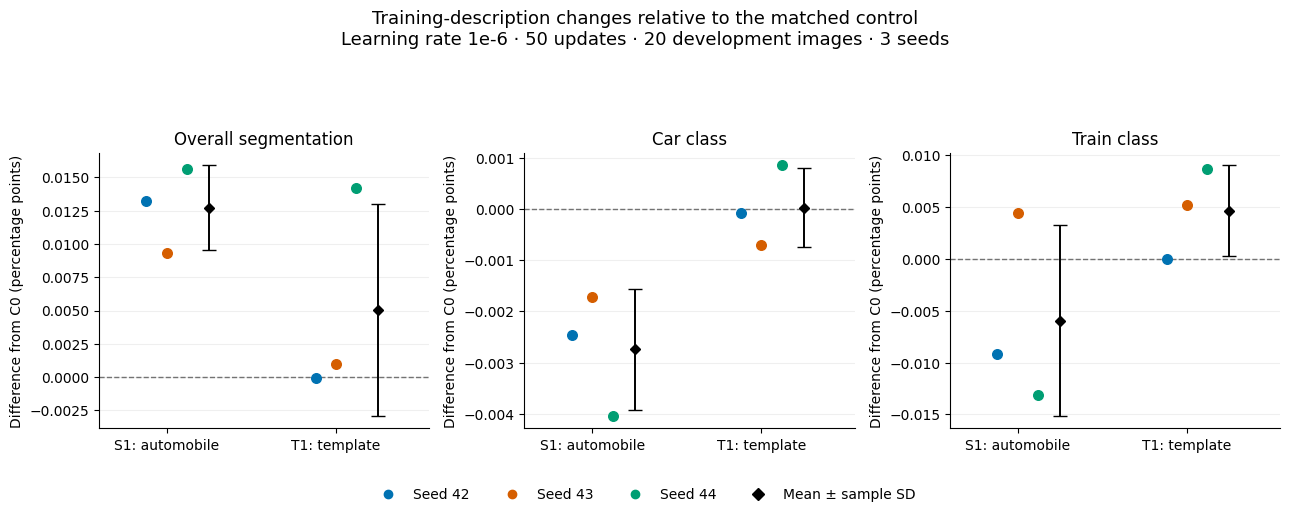


ALL NINE RESULTS
 Seed Condition  mIoU (%)  Car IoU (%)  Train IoU (%)
   42        C0 68.241869    92.033744      92.489803
   42        S1 68.255070    92.031281      92.480665
   42        T1 68.241823    92.033672      92.489803
   43        C0 68.221066    92.019338      92.483405
   43        S1 68.230372    92.017618      92.487780
   43        T1 68.222043    92.018644      92.488629
   44        C0 68.108255    92.024811      92.503590
   44        S1 68.123894    92.020769      92.490456
   44        T1 68.122490    92.025668      92.512286

PAIRED EFFECTS: MEAN AND SAMPLE STANDARD DEVIATION
 Comparison                    Metric  Mean paired difference  Sample SD  Seeds
S1 minus C0      mIoU difference (pp)                0.012715   0.003194      3
S1 minus C0   Car IoU difference (pp)               -0.002742   0.001185      3
S1 minus C0 Train IoU difference (pp)               -0.005966   0.009175      3
T1 minus C0      mIoU difference (pp)                0.005055   0.0079

In [ ]:
from pathlib import Path
from datetime import datetime
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


PILOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
T1_FOLDER = PILOT / "text_conditions/T1_20260919_123253_618427"

S1_FOLDERS = {
    42: PILOT / "evaluation_S1_lr1e6_step50_20260918_235211_356961",
    43: PILOT / "evaluation_S1_lr1e6_seed43_step50_20260919_120257_062076",
    44: PILOT / "evaluation_S1_lr1e6_seed44_step50_20260919_121834_469046",
}

def read_saved_json(path):
    path = Path(path)
    assert path.is_file(), f"Missing saved file: {path}"
    return json.loads(path.read_text())


# Load the existing comparisons and evaluation metrics.
rows = []
source_files = []
reference_images = None

for seed in (42, 43, 44):
    comparison_files = list(
        T1_FOLDER.glob(f"seed{seed}_*/comparison.json")
    )
    assert len(comparison_files) == 1, (
        f"Expected one T1 comparison for seed {seed}; "
        f"found {len(comparison_files)}."
    )

    comparison_path = comparison_files[0]
    comparison = read_saved_json(comparison_path)
    assert comparison["seed"] == seed

    s1_path = S1_FOLDERS[seed] / "metrics.json"
    results = {
        "C0": comparison["results"]["C0"],
        "S1": read_saved_json(s1_path),
        "T1": comparison["results"]["T1"],
    }
    source_files.extend([str(comparison_path), str(s1_path)])

    for condition, metrics in results.items():
        if reference_images is None:
            reference_images = metrics["images"]

        assert metrics["images"] == reference_images, (
            f"Evaluation images differ: {condition}, seed {seed}"
        )
        assert metrics["classes_with_nonzero_union"] == 19

        rows.append({
            "Seed": seed,
            "Condition": condition,
            "mIoU (%)": metrics["miou_percent"],
            "Car IoU (%)": metrics["car_iou_percent"],
            "Train IoU (%)": metrics["class_iou_percent"]["train"],
        })

assert len(reference_images) == 20

individual = pd.DataFrame(rows).sort_values(["Seed", "Condition"])
assert len(individual) == 9
assert not individual.duplicated(["Seed", "Condition"]).any()

metric_columns = ["mIoU (%)", "Car IoU (%)", "Train IoU (%)"]

# Absolute scores: condition means and sample standard deviations.
condition_summary_rows = []
for condition in ("C0", "S1", "T1"):
    subset = individual[individual["Condition"] == condition]
    for metric in metric_columns:
        condition_summary_rows.append({
            "Condition": condition,
            "Metric": metric,
            "Mean": subset[metric].mean(),
            "Sample SD": subset[metric].std(ddof=1),
            "Seeds": len(subset),
        })

condition_summary = pd.DataFrame(condition_summary_rows)

# Differences are calculated within the same seed.
paired_rows = []
for seed in (42, 43, 44):
    seed_results = individual[
        individual["Seed"] == seed
    ].set_index("Condition")

    for condition in ("S1", "T1"):
        paired_rows.append({
            "Seed": seed,
            "Comparison": f"{condition} minus C0",
            "mIoU difference (pp)": (
                seed_results.loc[condition, "mIoU (%)"]
                - seed_results.loc["C0", "mIoU (%)"]
            ),
            "Car IoU difference (pp)": (
                seed_results.loc[condition, "Car IoU (%)"]
                - seed_results.loc["C0", "Car IoU (%)"]
            ),
            "Train IoU difference (pp)": (
                seed_results.loc[condition, "Train IoU (%)"]
                - seed_results.loc["C0", "Train IoU (%)"]
            ),
        })

paired = pd.DataFrame(paired_rows)
difference_columns = [
    "mIoU difference (pp)",
    "Car IoU difference (pp)",
    "Train IoU difference (pp)",
]

paired_summary_rows = []
for comparison_name in ("S1 minus C0", "T1 minus C0"):
    subset = paired[paired["Comparison"] == comparison_name]
    for metric in difference_columns:
        paired_summary_rows.append({
            "Comparison": comparison_name,
            "Metric": metric,
            "Mean paired difference": subset[metric].mean(),
            "Sample SD": subset[metric].std(ddof=1),
            "Seeds": len(subset),
        })

paired_summary = pd.DataFrame(paired_summary_rows)

# Create a new folder; previous results remain intact.
output = PILOT / "report_summary" / (
    "combined_wording_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
output.mkdir(parents=True, exist_ok=False)

individual.to_csv(output / "individual_results.csv", index=False)
condition_summary.to_csv(output / "condition_mean_and_sd.csv", index=False)
paired.to_csv(output / "paired_differences.csv", index=False)
paired_summary.to_csv(output / "paired_mean_and_sd.csv", index=False)

# Figure: individual seed differences and mean ± sample SD.
colors = {42: "#0072B2", 43: "#D55E00", 44: "#009E73"}
offsets = {42: -0.12, 43: 0.0, 44: 0.12}
comparisons = ["S1 minus C0", "T1 minus C0"]
titles = ["Overall segmentation", "Car class", "Train class"]

fig, axes = plt.subplots(1, 3, figsize=(13, 5.2))

for ax, metric, title in zip(axes, difference_columns, titles):
    ax.axhline(0, color="0.45", linestyle="--", linewidth=1)

    for position, comparison_name in enumerate(comparisons):
        subset = paired[
            paired["Comparison"] == comparison_name
        ].set_index("Seed")

        for seed in (42, 43, 44):
            ax.scatter(
                position + offsets[seed],
                subset.loc[seed, metric],
                color=colors[seed],
                s=48,
                zorder=3,
            )

        values = subset[metric]
        ax.errorbar(
            position + 0.25,
            values.mean(),
            yerr=values.std(ddof=1),
            fmt="D",
            color="black",
            markersize=5,
            capsize=5,
            linewidth=1.4,
            zorder=4,
        )

    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["S1: automobile", "T1: template"])
    ax.set_xlim(-0.4, 1.55)
    ax.set_ylabel("Difference from C0 (percentage points)")
    ax.grid(axis="y", alpha=0.2)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="None",
        color=colors[seed], label=f"Seed {seed}"
    )
    for seed in (42, 43, 44)
]
legend_handles.append(
    Line2D(
        [0], [0], marker="D", color="black",
        linestyle="None", label="Mean ± sample SD"
    )
)

fig.suptitle(
    "Training-description changes relative to the matched control\n"
    "Learning rate 1e-6 · 50 updates · 20 development images · 3 seeds",
    fontsize=13,
)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
)
fig.tight_layout(rect=[0, 0.1, 1, 0.88])

fig.savefig(output / "wording_effects.png", dpi=300, bbox_inches="tight")
fig.savefig(output / "wording_effects.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

scope = {
    "conditions": {
        "C0": "a photo with a car",
        "S1": "a photo with an automobile",
        "T1": "a photograph containing a car",
    },
    "seeds": [42, 43, 44],
    "learning_rate": 1e-6,
    "updates_per_run": 50,
    "training_images": 50,
    "development_images": 20,
    "comparison": "Within-seed differences relative to C0",
    "error_bars": "Sample standard deviation across three paired differences",
    "figure_axes": "Separate vertical scales for each metric",
    "source_files": source_files,
    "limitations": [
        "Small development experiment, not independent final evaluation.",
        "Learning rate selected after development diagnostics.",
        "Same saved image schedule across seeds.",
        "Seed variation does not measure dataset uncertainty.",
        "No statistical significance or equivalence claim is established.",
        "Train-class development support is limited to one image.",
    ],
    "new_training_performed": False,
}

(output / "scope.json").write_text(json.dumps(scope, indent=2))

print("\nALL NINE RESULTS")
print(individual.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nPAIRED EFFECTS: MEAN AND SAMPLE STANDARD DEVIATION")
print(paired_summary.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nFiles saved:", output)
print("No model loaded by this cell. No training performed.")

In [ ]:
from pathlib import Path
from datetime import datetime
import json

import torch


PILOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
C0_RUN = PILOT / "C0_lr1e6_20260918_232001_922343"
T1_FOLDER = PILOT / "text_conditions/T1_20260919_123253_618427"

assert "training_processor" in globals(), (
    "The restored training_processor is required."
)

preparation = json.loads(
    (PILOT / "preparation_report.json").read_text()
)
reference_plan = json.loads(
    (T1_FOLDER / "experiment_plan.json").read_text()
)

records = preparation["records"]
assert len(records) == 50

original_text = "a photo with a car"
incorrect_text = "a photo with a bicycle"

# Match the saved description-token format:
# fixed length 77, with padding positions set to zero.
encoded = training_processor.tokenizer(
    [original_text, incorrect_text],
    padding="max_length",
    truncation=True,
    max_length=77,
    return_tensors="pt",
)
description_tokens = (
    encoded["input_ids"] * encoded["attention_mask"]
).cpu()

original_tokens = description_tokens[0]
incorrect_tokens = description_tokens[1]

assert not torch.equal(original_tokens, incorrect_tokens)

tokens_by_image = {}
audit_records = []
total_replacements = 0
images_with_replacements = 0

for record in records:
    saved = torch.load(
        record["prepared_file"],
        map_location="cpu",
        weights_only=True,
    )

    inputs = saved["inputs"]
    original = inputs["text_inputs"].detach().cpu()

    assert original.ndim == 3 and original.shape[0] == 1
    assert original.shape[-1] == 77

    # Only replace complete descriptions matching the original car text.
    car_rows = (original[0] == original_tokens).all(dim=-1)
    replacement_count = int(car_rows.sum().item())

    labels = inputs["class_labels"]
    if isinstance(labels, (list, tuple)):
        labels = torch.cat([item.reshape(-1) for item in labels])
    else:
        labels = labels.reshape(-1)

    car_mask_count = int((labels == 13).sum().item())

    assert replacement_count == car_mask_count, (
        f"Description/mask count mismatch for {record['image']}: "
        f"{replacement_count} descriptions, {car_mask_count} car masks. "
        "Preparation stopped."
    )

    changed = original.clone()
    changed[0, car_rows] = incorrect_tokens.to(dtype=changed.dtype)

    assert torch.equal(
        changed[0, ~car_rows],
        original[0, ~car_rows],
    ), "A non-car description changed."

    if replacement_count:
        assert torch.all(
            changed[0, car_rows]
            == incorrect_tokens.to(dtype=changed.dtype)
        ).item()
        images_with_replacements += 1

    image_name = record["image"]
    assert image_name not in tokens_by_image

    tokens_by_image[image_name] = changed
    total_replacements += replacement_count

    audit_records.append({
        "image": image_name,
        "prepared_source_file": str(record["prepared_file"]),
        "descriptions_replaced": replacement_count,
        "car_masks": car_mask_count,
        "changed_token_positions": int(
            (changed != original).sum().item()
        ),
    })

assert len(tokens_by_image) == 50
assert images_with_replacements == 47
assert total_replacements == 377

w1_folder = PILOT / "text_conditions" / (
    "W1_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
w1_folder.mkdir(parents=True, exist_ok=False)

token_path = w1_folder / "wrong_class_text_tokens.pt"
temporary_path = token_path.with_suffix(".pt.partial")

torch.save(
    {
        "condition": "W1",
        "text_inputs_by_image": tokens_by_image,
    },
    temporary_path,
)

# Verify the saved tokens before accepting the file.
readback = torch.load(
    temporary_path,
    map_location="cpu",
    weights_only=True,
)
assert readback["condition"] == "W1"
assert readback["text_inputs_by_image"].keys() == tokens_by_image.keys()
assert all(
    torch.equal(tokens, readback["text_inputs_by_image"][name])
    for name, tokens in tokens_by_image.items()
)
temporary_path.replace(token_path)

plan = {
    "condition": "W1",
    "question": (
        "Does replacing the correct car word with the incorrect word "
        "bicycle affect segmentation after matched fine-tuning?"
    ),
    "control_description": original_text,
    "intervention_description": incorrect_text,
    "correct_class": "car",
    "incorrect_text_class": "bicycle",
    "ground_truth_class_id_preserved": 13,
    "training_images": 50,
    "development_images": 20,
    "images_with_replacements": images_with_replacements,
    "descriptions_replaced": total_replacements,
    "training_seeds": [42, 43, 44],
    "learning_rate": 1e-6,
    "updates_per_seed": 50,
    "batch_size": 2,
    "schedule_file": str(PILOT / "batch_schedule.json"),
    "common_initial_weights": reference_plan["common_initial_weights"],
    "reference_training_settings": str(C0_RUN / "settings.json"),
    "token_file": str(token_path),
    "primary_comparison": "W1 minus C0, paired within each seed",
    "primary_metric": "Development semantic mIoU",
    "secondary_metrics": ["Car IoU", "Bicycle IoU", "Per-class IoU"],
    "images_masks_and_class_labels": "Reuse unchanged",
    "scope": (
        "One deliberately incorrect word substitution in a small "
        "development experiment; not a test of all incorrect descriptions."
    ),
    "optimizer_updates_performed": 0,
    "records": audit_records,
}

(w1_folder / "experiment_plan.json").write_text(
    json.dumps(plan, indent=2)
)

print("W1 PREPARATION PASSED")
print("Original:", original_text)
print("Incorrect description:", incorrect_text)
print("Ground-truth class retained: car (ID 13)")
print("Images prepared:", len(tokens_by_image))
print("Images with replacements:", images_with_replacements)
print("Descriptions replaced:", total_replacements)
print("Saved tokens: read-back check passed")
print("Planned seeds: 42, 43, 44")
print("Saved folder:", w1_folder)
print("No model weights changed. No training performed.")

W1 PREPARATION PASSED
Original: a photo with a car
Incorrect description: a photo with a bicycle
Ground-truth class retained: car (ID 13)
Images prepared: 50
Images with replacements: 47
Descriptions replaced: 377
Saved tokens: read-back check passed
Planned seeds: 42, 43, 44
Saved folder: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/text_conditions/W1_20260919_140231_895355
No model weights changed. No training performed.


In [ ]:
from pathlib import Path
from datetime import datetime
import copy
import gc
import hashlib
import json
import random
import shutil

import numpy as np
import pandas as pd
import torch


# ---------- Paths and session checks ----------

PILOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
W1_FOLDER = PILOT / "text_conditions/W1_20260919_140231_895355"
C0_RUN = PILOT / "C0_lr1e6_20260918_232001_922343"

CONTROL_FOLDERS = {
    42: PILOT / "evaluation_C0_lr1e6_step50_20260918_232349_444839",
    43: PILOT / "evaluation_C0_lr1e6_seed43_step50_20260919_115822_182984",
    44: PILOT / "evaluation_C0_lr1e6_seed44_step50_20260919_121357_393811",
}

assert "audit_model" in globals(), "Restore the model first."
assert callable(globals().get("make_training_batch"))
assert callable(globals().get("evaluate_development"))
assert torch.cuda.is_available(), "Connect to a GPU runtime first."


# ---------- Helpers ----------

def w1_read_json(path):
    path = Path(path)
    assert path.is_file(), f"Missing file: {path}"
    return json.loads(path.read_text())


def w1_write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(value, indent=2))
    temporary.replace(path)


def w1_cpu_copy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {key: w1_cpu_copy(item) for key, item in value.items()}
    if isinstance(value, list):
        return [w1_cpu_copy(item) for item in value]
    if isinstance(value, tuple):
        return tuple(w1_cpu_copy(item) for item in value)
    return value


def w1_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def w1_scores(metrics):
    return {
        "mIoU (%)": metrics["miou_percent"],
        "Car IoU (%)": metrics["car_iou_percent"],
        "Bicycle IoU (%)": metrics["class_iou_percent"]["bicycle"],
        "Train IoU (%)": metrics["class_iou_percent"]["train"],
    }


# Check all inputs before starting.
w1_plan = w1_read_json(W1_FOLDER / "experiment_plan.json")
w1_schedule = w1_read_json(PILOT / "batch_schedule.json")
w1_records = w1_read_json(
    PILOT / "preparation_report.json"
)["records"]

assert w1_plan["condition"] == "W1"
assert w1_plan["intervention_description"] == "a photo with a bicycle"
assert w1_plan["training_seeds"] == [42, 43, 44]
assert w1_plan["learning_rate"] == 1e-6
assert w1_plan["updates_per_seed"] == 50
assert len(w1_records) == 50
assert [int(row["step"]) for row in w1_schedule] == list(range(1, 51))
assert all(len(row["indices"]) == 2 for row in w1_schedule)

w1_saved_tokens = torch.load(
    W1_FOLDER / "wrong_class_text_tokens.pt",
    map_location="cpu",
    weights_only=True,
)
assert w1_saved_tokens["condition"] == "W1"
w1_token_map = w1_saved_tokens["text_inputs_by_image"]
assert all(record["image"] in w1_token_map for record in w1_records)

w1_expected_names = w1_read_json(
    C0_RUN / "trainable_parameter_names.json"
)
w1_controls = {
    seed: w1_read_json(folder / "metrics.json")
    for seed, folder in CONTROL_FOLDERS.items()
}

reference_images = w1_controls[42]["images"]
assert len(reference_images) == 20
for metrics in w1_controls.values():
    assert metrics["images"] == reference_images
    assert metrics["classes_with_nonzero_union"] == 19
    w1_scores(metrics)


# ---------- One independent training run ----------

def run_w1_seed(seed):
    completed = list(
        W1_FOLDER.glob(f"seed{seed}_*/comparison.json")
    )
    assert len(completed) <= 1, (
        f"Multiple completed comparisons found for seed {seed}."
    )
    if completed:
        print(f"Seed {seed} already complete; reusing saved results.")
        return completed[0]

    progress = list(
        W1_FOLDER.glob(f"seed{seed}_*/checkpoint_step*.pt")
    )
    progress += [
        path
        for path in W1_FOLDER.glob(f"seed{seed}_*/history.json")
        if w1_read_json(path)
    ]
    assert not progress, (
        f"An incomplete seed-{seed} run has saved progress. "
        "Share this output so we can resume without repeating training:\n"
        + "\n".join(map(str, progress))
    )

    actual_names = [
        name for name, parameter in audit_model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == w1_expected_names

    backbone = audit_model.get_submodule(
        "model.pixel_level_module.encoder"
    )
    assert not any(p.requires_grad for p in backbone.parameters())

    hook_locations = [
        name for name, module in audit_model.named_modules()
        if len(getattr(module, "_project_causal_mask_handles", [])) == 6
    ]
    assert len(hook_locations) == 1, (
        "The six restored causal-mask hooks could not be uniquely located."
    )

    run_folder = W1_FOLDER / (
        f"seed{seed}_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    run_folder.mkdir(parents=True, exist_ok=False)

    settings = {
        "condition": "W1",
        "seed": seed,
        "description": w1_plan["intervention_description"],
        "learning_rate": 1e-6,
        "updates": 50,
        "batch_size": 2,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
        "foreach": False,
        "gradient_clip_norm": 1.0,
        "precision": "float32",
        "scheduler": None,
        "common_initial_weights": w1_plan["common_initial_weights"],
        "schedule_file": str(PILOT / "batch_schedule.json"),
        "experiment_plan": str(W1_FOLDER / "experiment_plan.json"),
        "control_metrics": str(CONTROL_FOLDERS[seed] / "metrics.json"),
        "reference_settings": w1_read_json(C0_RUN / "settings.json"),
    }
    w1_write_json(run_folder / "settings.json", settings)
    w1_write_json(
        run_folder / "trainable_parameter_names.json", actual_names
    )

    # Reset independently for every seed.
    initial = torch.load(
        w1_plan["common_initial_weights"],
        map_location="cpu",
        weights_only=True,
    )
    audit_model.load_state_dict(initial, strict=True)
    del initial
    gc.collect()

    audit_model.to(device="cuda", dtype=torch.float32)
    audit_model.train()
    backbone.eval()

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    parameters = [
        p for p in audit_model.parameters() if p.requires_grad
    ]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=1e-6,
        weight_decay=0.01,
        betas=(0.9, 0.999),
        eps=1e-8,
        foreach=False,
    )
    history = []

    def save_checkpoint(step):
        cpu_rng = torch.get_rng_state()
        cuda_rng = torch.cuda.get_rng_state_all()
        numpy_rng = np.random.get_state()

        local = Path("/content") / f"{run_folder.name}_step{step}.pt"
        destination = run_folder / f"checkpoint_step{step}.pt"
        partial = destination.with_suffix(".pt.partial")

        try:
            payload = {
                "condition": "W1",
                "seed": seed,
                "completed_steps": step,
                "model": w1_cpu_copy(audit_model.state_dict()),
                "optimizer": w1_cpu_copy(optimizer.state_dict()),
                "torch_rng_state": cpu_rng,
                "cuda_rng_states": cuda_rng,
                "python_rng_state": random.getstate(),
                "numpy_rng_state": {
                    "generator": numpy_rng[0],
                    "keys": numpy_rng[1].tolist(),
                    "position": int(numpy_rng[2]),
                    "has_gauss": int(numpy_rng[3]),
                    "cached_gaussian": float(numpy_rng[4]),
                },
                "settings": settings,
                "history": copy.deepcopy(history),
                "trainable_parameter_names": actual_names,
            }
            torch.save(payload, local)
            shutil.copyfile(local, partial)

            checksum = w1_hash(local)
            assert checksum == w1_hash(partial)

            restored = torch.load(
                partial, map_location="cpu", weights_only=True
            )
            assert restored["condition"] == "W1"
            assert restored["seed"] == seed
            assert restored["completed_steps"] == step
            assert restored["model"].keys() == payload["model"].keys()
            assert all(
                torch.equal(value, restored["model"][name])
                for name, value in payload["model"].items()
            )

            partial.replace(destination)
            w1_write_json(
                run_folder / f"checkpoint_step{step}_verification.json",
                {
                    "sha256": checksum,
                    "file_copy_equal": True,
                    "model_readback_equal": True,
                },
            )
            del payload, restored
            print(f"Seed {seed}: checkpoint {step} saved and read-checked")

        finally:
            torch.set_rng_state(cpu_rng)
            torch.cuda.set_rng_state_all(cuda_rng)
            local.unlink(missing_ok=True)
            gc.collect()

    print(f"\nStarting W1 seed {seed}: LR 1e-6, 50 updates.")
    print("Description:", settings["description"])
    print("Saving to:", run_folder)

    for entry in w1_schedule:
        step = int(entry["step"])
        indices = entry["indices"]

        # Original image, mask, label and task inputs.
        batch = make_training_batch(indices, "C0")

        replacement = torch.cat(
            [w1_token_map[w1_records[i]["image"]] for i in indices],
            dim=0,
        )
        assert replacement.shape == batch["text_inputs"].shape
        batch["text_inputs"] = replacement.to(
            device=batch["text_inputs"].device,
            dtype=batch["text_inputs"].dtype,
        )

        optimizer.zero_grad(set_to_none=True)
        torch.cuda.reset_peak_memory_stats()

        outputs = audit_model(**batch)
        loss = outputs.loss
        assert torch.isfinite(loss).item(), (
            f"Non-finite loss at seed {seed}, update {step}."
        )
        loss.backward()

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            parameters, max_norm=1.0, error_if_nonfinite=True
        )
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        history.append({
            "step": step,
            "epoch": entry["epoch"],
            "images": entry["images"],
            "loss": float(loss.detach().cpu()),
            "gradient_norm_before_clip": float(gradient_norm),
            "peak_gpu_allocated_gib": (
                torch.cuda.max_memory_allocated() / 1024**3
            ),
        })
        w1_write_json(run_folder / "history.json", history)
        print(
            f"W1 seed {seed}: {step:02d}/50 | "
            f"loss={history[-1]['loss']:.4f}"
        )

        del outputs, loss, batch, replacement
        if step in (25, 50):
            save_checkpoint(step)

    del optimizer
    gc.collect()
    torch.cuda.empty_cache()

    metrics = evaluate_development(
        audit_model, f"W1_lr1e6_seed{seed}_step50"
    )
    w1_write_json(run_folder / "evaluation_metrics.json", metrics)

    control = w1_controls[seed]
    assert metrics["images"] == control["images"]
    assert metrics["classes_with_nonzero_union"] == 19

    control_scores = w1_scores(control)
    intervention_scores = w1_scores(metrics)
    differences = {
        metric.replace(" (%)", " difference (pp)"): (
            intervention_scores[metric] - control_scores[metric]
        )
        for metric in control_scores
    }

    comparison_path = run_folder / "comparison.json"
    w1_write_json(comparison_path, {
        "seed": seed,
        "results": {"C0": control, "W1": metrics},
        "W1_minus_C0_percentage_points": differences,
        "scope": "Matched comparison on the same 20 development images.",
    })

    table = pd.DataFrame([
        {"Condition": "C0", "Seed": seed, **control_scores},
        {"Condition": "W1", "Seed": seed, **intervention_scores},
    ])
    table.to_csv(run_folder / "comparison.csv", index=False)

    print(f"\nSEED {seed} COMPLETE")
    print(table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print("W1 minus C0:", differences)
    return comparison_path


# ---------- Run all planned seeds ----------

w1_comparison_files = []
for seed in (42, 43, 44):
    w1_comparison_files.append(run_w1_seed(seed))


# ---------- Three-seed summary ----------

individual_rows = []
paired_rows = []

for path in w1_comparison_files:
    comparison = w1_read_json(path)
    seed = comparison["seed"]
    results = comparison["results"]

    for condition in ("C0", "W1"):
        assert results[condition]["images"] == reference_images
        individual_rows.append({
            "Seed": seed,
            "Condition": condition,
            **w1_scores(results[condition]),
        })

    paired_rows.append({
        "Seed": seed,
        **comparison["W1_minus_C0_percentage_points"],
    })

individual = pd.DataFrame(individual_rows).sort_values(["Seed", "Condition"])
paired = pd.DataFrame(paired_rows).sort_values("Seed")
assert paired["Seed"].tolist() == [42, 43, 44]

summary = pd.DataFrame([
    {
        "Metric": metric,
        "Mean paired difference": paired[metric].mean(),
        "Sample SD": paired[metric].std(ddof=1),
        "Seeds": 3,
    }
    for metric in paired.columns if metric != "Seed"
])

summary_folder = W1_FOLDER / (
    "three_seed_summary_"
    + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
summary_folder.mkdir(parents=True, exist_ok=False)

individual.to_csv(summary_folder / "individual_results.csv", index=False)
paired.to_csv(summary_folder / "paired_differences.csv", index=False)
summary.to_csv(summary_folder / "paired_mean_and_sd.csv", index=False)

w1_write_json(summary_folder / "scope.json", {
    "condition": "W1",
    "control_description": "a photo with a car",
    "intervention_description": "a photo with a bicycle",
    "ground_truth_class_retained": "car",
    "seeds": [42, 43, 44],
    "learning_rate": 1e-6,
    "updates_per_run": 50,
    "training_images": 50,
    "development_images": 20,
    "primary_metric": "mIoU",
    "comparison": "W1 minus C0, paired within each seed",
    "source_files": [str(path) for path in w1_comparison_files],
    "limitations": [
        "Small development experiment, not official validation.",
        "Only one incorrect word substitution was tested.",
        "Learning rate selected after development diagnostics.",
        "Sample SD describes seed variation, not dataset uncertainty.",
    ],
})

print("\nALL THREE SEEDS")
print(individual.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nPAIRED DIFFERENCES: W1 minus C0")
print(paired.to_string(index=False, float_format=lambda x: f"{x:+.6f}"))

print("\nMEAN AND SAMPLE STANDARD DEVIATION")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nSummary saved:", summary_folder)
print("Existing C0 results were reused.")


Starting W1 seed 42: LR 1e-6, 50 updates.
Description: a photo with a bicycle
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/text_conditions/W1_20260919_140231_895355/seed42_20260919_140739_646933
W1 seed 42: 01/50 | loss=25.9556
W1 seed 42: 02/50 | loss=24.1116
W1 seed 42: 03/50 | loss=25.0162
W1 seed 42: 04/50 | loss=25.7594
W1 seed 42: 05/50 | loss=33.1101
W1 seed 42: 06/50 | loss=29.7431
W1 seed 42: 07/50 | loss=15.2773
W1 seed 42: 08/50 | loss=34.0532
W1 seed 42: 09/50 | loss=29.9461
W1 seed 42: 10/50 | loss=21.4207
W1 seed 42: 11/50 | loss=25.2473
W1 seed 42: 12/50 | loss=23.3798
W1 seed 42: 13/50 | loss=24.7624
W1 seed 42: 14/50 | loss=29.3606
W1 seed 42: 15/50 | loss=21.1817
W1 seed 42: 16/50 | loss=27.2426
W1 seed 42: 17/50 | loss=25.0258
W1 seed 42: 18/50 | loss=27.2157
W1 seed 42: 19/50 | loss=24.2802
W1 seed 42: 20/50 | loss=18.9595
W1 seed 42: 21/50 | loss=34.5371
W1 seed 42: 22/50 | loss=25.6538
W1 seed 42: 23/50 | loss=22.

In [ ]:
from pathlib import Path, PurePosixPath
from datetime import datetime
import json
import re
import zipfile


PROJECT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
PILOT = PROJECT / "pilots/matched_50image_20260918_220528_251046"

T1_FOLDER = PILOT / "text_conditions/T1_20260919_123253_618427"
W1_FOLDER = PILOT / "text_conditions/W1_20260919_140231_895355"

VALIDATION_FOLDER = PILOT / "validation_500"
PROTOCOL_PATH = VALIDATION_FOLDER / "evaluation_protocol.json"


def read_json_file(path):
    path = Path(path)
    assert path.is_file(), f"Missing file: {path}"
    return json.loads(path.read_text())


def find_unique_archive(filename):
    matches = sorted(PROJECT.rglob(filename))
    assert len(matches) == 1, (
        f"Expected one {filename}; found {len(matches)}:\n"
        + "\n".join(map(str, matches))
    )
    return matches[0]


def find_final_checkpoint(folder):
    folder = Path(folder)
    assert folder.is_dir(), f"Missing training folder: {folder}"

    # Locate an update-50 checkpoint without assuming its exact filename.
    candidates = [
        path for path in folder.rglob("*.pt")
        if re.search(r"(?<!\d)0*50(?!\d)", path.stem)
        and "optimizer" not in path.stem.lower()
        and "rng" not in path.stem.lower()
    ]

    assert len(candidates) == 1, (
        f"Could not uniquely identify the update-50 checkpoint in:\n"
        f"{folder}\nCandidates:\n"
        + "\n".join(map(str, candidates))
        + "\nStop here and share this output."
    )

    checkpoint = candidates[0]
    assert checkpoint.stat().st_size > 0
    return checkpoint


def completed_condition_folder(condition_folder, seed):
    matches = list(
        condition_folder.glob(f"seed{seed}_*/comparison.json")
    )
    assert len(matches) == 1, (
        f"Expected one completed seed-{seed} comparison in "
        f"{condition_folder}; found {len(matches)}."
    )
    comparison = read_json_file(matches[0])
    assert comparison["seed"] == seed
    return matches[0].parent


print("Checking validation archives...")

image_archive = find_unique_archive("leftImg8bit_trainvaltest.zip")
label_archive = find_unique_archive("gtFine_trainvaltest.zip")

with zipfile.ZipFile(image_archive) as archive:
    image_infos = [
        item for item in archive.infolist()
        if not item.is_dir()
        and item.filename.startswith("leftImg8bit/val/")
        and item.filename.endswith("_leftImg8bit.png")
    ]
    assert all(item.file_size > 0 for item in image_infos)

with zipfile.ZipFile(label_archive) as archive:
    label_infos = [
        item for item in archive.infolist()
        if not item.is_dir()
        and item.filename.startswith("gtFine/val/")
        and item.filename.endswith("_gtFine_labelIds.png")
    ]
    assert all(item.file_size > 0 for item in label_infos)

assert len(image_infos) == 500, (
    f"Expected 500 validation images; found {len(image_infos)}."
)
assert len(label_infos) == 500, (
    f"Expected 500 validation label maps; found {len(label_infos)}."
)

labels_by_key = {}
for item in label_infos:
    path = PurePosixPath(item.filename)
    key = (path.parent.name, path.name.removesuffix("_gtFine_labelIds.png"))
    assert key not in labels_by_key
    labels_by_key[key] = item.filename

manifest = []
seen_keys = set()

for item in sorted(image_infos, key=lambda value: value.filename):
    path = PurePosixPath(item.filename)
    key = (path.parent.name, path.name.removesuffix("_leftImg8bit.png"))

    assert key not in seen_keys
    assert key in labels_by_key, f"No matching label map for {item.filename}"
    seen_keys.add(key)

    manifest.append({
        "index": len(manifest),
        "city": key[0],
        "image_name": path.name,
        "image_member": item.filename,
        "label_member": labels_by_key[key],
    })

assert seen_keys == set(labels_by_key)
assert len(manifest) == 500

# Check against the pilot's prepared training filenames.
training_records = read_json_file(
    PILOT / "preparation_report.json"
)["records"]
training_names = {
    Path(record["image"]).name for record in training_records
}
validation_names = {record["image_name"] for record in manifest}
assert training_names.isdisjoint(validation_names), (
    "Validation filenames overlap the pilot training images."
)

# Check against the 20 development images as well.
development_metrics = read_json_file(
    PILOT
    / "evaluation_C0_lr1e6_step50_20260918_232349_444839"
    / "metrics.json"
)
assert all(
    isinstance(name, str) for name in development_metrics["images"]
)
development_names = {
    Path(name).name for name in development_metrics["images"]
}
assert development_names.isdisjoint(validation_names), (
    "Validation filenames overlap the development images."
)

print("Validation image/label pairs: 500")
print("No filename overlap with pilot training or development images.")

print("\nLocating B0 and the 12 fine-tuned checkpoints...")

t1_plan = read_json_file(T1_FOLDER / "experiment_plan.json")
common_weights = Path(t1_plan["common_initial_weights"])
assert common_weights.is_file() and common_weights.stat().st_size > 0

training_folders = {
    ("C0", 42): PILOT / "C0_lr1e6_20260918_232001_922343",
    ("S1", 42): PILOT / "S1_lr1e6_20260918_234731_452673",
    ("C0", 43): PILOT / "matched_seed43_20260919_115234_749725/C0",
    ("S1", 43): PILOT / "matched_seed43_20260919_115234_749725/S1",
    ("C0", 44): PILOT / "matched_seed44_20260919_120943_481641/C0",
    ("S1", 44): PILOT / "matched_seed44_20260919_120943_481641/S1",
}

for seed in (42, 43, 44):
    training_folders[("T1", seed)] = completed_condition_folder(
        T1_FOLDER, seed
    )
    training_folders[("W1", seed)] = completed_condition_folder(
        W1_FOLDER, seed
    )

models = [{
    "name": "B0",
    "condition": "B0",
    "seed": None,
    "updates": 0,
    "checkpoint": str(common_weights),
    "checkpoint_bytes": common_weights.stat().st_size,
}]

for condition in ("C0", "S1", "T1", "W1"):
    for seed in (42, 43, 44):
        checkpoint = find_final_checkpoint(training_folders[(condition, seed)])
        models.append({
            "name": f"{condition}_seed{seed}",
            "condition": condition,
            "seed": seed,
            "updates": 50,
            "checkpoint": str(checkpoint),
            "checkpoint_bytes": checkpoint.stat().st_size,
        })
        print(f"FOUND: {condition}, seed {seed}: {checkpoint.name}")

assert len(models) == 13
assert len({model["checkpoint"] for model in models}) == 13

protocol = {
    "evaluation_name": "Cityscapes official validation, reduced-resolution inputs",
    "split": "val",
    "number_of_images": 500,
    "image_archive": str(image_archive),
    "label_archive": str(label_archive),
    "input_size_width_height": [512, 256],
    "image_resize": "RGB bilinear, matching the development evaluator",
    "task": "semantic",
    "prediction_output_size": "Original label-map height and width",
    "postprocessing": "Same semantic postprocessing as development evaluation",
    "ground_truth_source": "gtFine_labelIds",
    "original_label_ids_in_train_id_order": [
        7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
        23, 24, 25, 26, 27, 28, 31, 32, 33,
    ],
    "class_names": [
        "road", "sidewalk", "building", "wall", "fence",
        "pole", "traffic light", "traffic sign", "vegetation",
        "terrain", "sky", "person", "rider", "car", "truck",
        "bus", "train", "motorcycle", "bicycle",
    ],
    "ignore_train_id": 255,
    "aggregation": "Pooled pixel confusion matrix across all 500 images",
    "primary_metric": "19-class semantic mIoU",
    "secondary_metrics": ["All per-class IoUs"],
    "primary_comparisons": [
        "S1 minus C0, paired by seed",
        "T1 minus C0, paired by seed",
        "W1 minus C0, paired by seed",
    ],
    "baseline_comparison": "Each model versus B0",
    "training_images_per_fine_tuned_model": 50,
    "training_updates": 50,
    "training_learning_rate": 1e-6,
    "seeds": [42, 43, 44],
    "models": models,
    "manifest": manifest,
    "selection_rule": "Evaluate every listed final checkpoint; no best-seed selection",
    "checkpoint_check": (
        "File presence and nonzero size checked. "
        "Checkpoint contents and strict model loading checked during evaluation."
    ),
    "limitations": [
        "Reduced-resolution inputs; not a reproduction of the full-resolution benchmark.",
        "Fine-tuning used only 50 training images.",
        "The official validation set was previously used for baseline evaluation.",
        "This is validation, not an untouched official test-set result.",
    ],
}

VALIDATION_FOLDER.mkdir(parents=True, exist_ok=True)

if PROTOCOL_PATH.exists():
    existing = read_json_file(PROTOCOL_PATH)
    existing.pop("created_at", None)
    assert existing == protocol, (
        "An existing protocol differs. It has not been overwritten. "
        "Share this output before proceeding."
    )
    print("\nExisting identical protocol retained.")
else:
    protocol["created_at"] = datetime.now().isoformat()
    temporary = PROTOCOL_PATH.with_suffix(".json.partial")
    temporary.write_text(json.dumps(protocol, indent=2))
    temporary.replace(PROTOCOL_PATH)
    print("\nEvaluation protocol saved.")

print("\nVALIDATION PREPARATION PASSED")
print("Official validation images: 500")
print("Models: 13 (B0 + four conditions × three seeds)")
print("Total planned image predictions: 6,500")
print("Input resolution: 512 × 256")
print("Scoring resolution: original label-map resolution")
print("Protocol:", PROTOCOL_PATH)
print("No training or inference performed.")

Checking validation archives...
Validation image/label pairs: 500
No filename overlap with pilot training or development images.

Locating B0 and the 12 fine-tuned checkpoints...
FOUND: C0, seed 42: step_050.pt
FOUND: C0, seed 43: step_050.pt
FOUND: C0, seed 44: step_050.pt
FOUND: S1, seed 42: step_050.pt
FOUND: S1, seed 43: step_050.pt
FOUND: S1, seed 44: step_050.pt
FOUND: T1, seed 42: checkpoint_step50.pt
FOUND: T1, seed 43: checkpoint_step50.pt
FOUND: T1, seed 44: checkpoint_step50.pt
FOUND: W1, seed 42: checkpoint_step50.pt
FOUND: W1, seed 43: checkpoint_step50.pt
FOUND: W1, seed 44: checkpoint_step50.pt

Evaluation protocol saved.

VALIDATION PREPARATION PASSED
Official validation images: 500
Models: 13 (B0 + four conditions × three seeds)
Total planned image predictions: 6,500
Input resolution: 512 × 256
Scoring resolution: original label-map resolution
Protocol: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/validation_500/evaluation_protoco

In [ ]:
from pathlib import Path
from datetime import datetime
from io import BytesIO
import gc
import hashlib
import json
import time
import zipfile

import numpy as np
import pandas as pd
from PIL import Image
import torch


PILOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
VALIDATION_FOLDER = PILOT / "validation_500"
PROTOCOL_PATH = VALIDATION_FOLDER / "evaluation_protocol.json"

assert "audit_model" in globals(), "Restore the model first."
assert "training_processor" in globals(), "Restore the processor first."
assert torch.cuda.is_available(), "Connect to a GPU runtime first."


def validation_read_json(path):
    return json.loads(Path(path).read_text())


def validation_write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(value, indent=2))
    temporary.replace(path)


def validation_file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def validation_save_npz(path, **arrays):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    with open(temporary, "wb") as handle:
        np.savez_compressed(handle, **arrays)
    temporary.replace(path)


def evaluate_validation_model(model_name):
    protocol = validation_read_json(PROTOCOL_PATH)
    manifest = protocol["manifest"]
    class_names = protocol["class_names"]
    number_of_classes = len(class_names)

    assert len(manifest) == 500
    assert number_of_classes == 19
    assert protocol["input_size_width_height"] == [512, 256]

    selected = [
        item for item in protocol["models"]
        if item["name"] == model_name
    ]
    assert len(selected) == 1, f"Unknown or duplicated model: {model_name}"
    model_record = selected[0]
    checkpoint_path = Path(model_record["checkpoint"])

    assert checkpoint_path.is_file()
    assert checkpoint_path.stat().st_size == model_record["checkpoint_bytes"]

    output = VALIDATION_FOLDER / "evaluations" / model_name
    prediction_folder = output / "predictions"
    per_image_folder = output / "per_image"

    prediction_folder.mkdir(parents=True, exist_ok=True)
    per_image_folder.mkdir(parents=True, exist_ok=True)

    print("Checking evaluation identity and checkpoint...")
    protocol_hash = validation_file_hash(PROTOCOL_PATH)
    checkpoint_hash = validation_file_hash(checkpoint_path)

    identity = {
        "model_name": model_name,
        "checkpoint": str(checkpoint_path),
        "checkpoint_sha256": checkpoint_hash,
        "protocol_sha256": protocol_hash,
        "implementation": "semantic_validation_v1",
        "torch_version": str(torch.__version__),
        "processor_class": type(training_processor).__name__,
    }

    identity_path = output / "evaluation_identity.json"
    if identity_path.exists():
        assert validation_read_json(identity_path) == identity, (
            "Saved evaluation identity differs. "
            "Stop here rather than mix incompatible results."
        )
    else:
        assert not list(per_image_folder.glob("*.npz")), (
            "Found saved image results without evaluation identity."
        )
        validation_write_json(identity_path, identity)

    # Verify and collect previously completed images.
    per_image_matrices = [None] * len(manifest)
    pending = []

    for index, record in enumerate(manifest):
        assert record["index"] == index
        result_path = per_image_folder / f"{index:04d}.npz"
        prediction_path = prediction_folder / record["image_name"].replace(
            "_leftImg8bit.png", "_prediction_trainIds.png"
        )

        if result_path.exists() and prediction_path.exists():
            with np.load(result_path, allow_pickle=False) as saved:
                assert int(saved["index"].item()) == index
                assert str(saved["image_name"].item()) == record["image_name"]
                matrix = saved["confusion_matrix"].copy()
                valid_pixels = int(saved["valid_pixels"].item())

            assert matrix.shape == (19, 19)
            assert np.issubdtype(matrix.dtype, np.integer)
            assert np.all(matrix >= 0)
            assert int(matrix.sum()) == valid_pixels
            per_image_matrices[index] = matrix
        else:
            pending.append(index)

    print(f"\nModel: {model_name}")
    print(f"Already completed: {500 - len(pending)}/500")
    print(f"Remaining: {len(pending)}")
    print("Saving to:", output)

    if pending:
        # Support both a plain state dictionary and checkpoint containers.
        saved_checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True,
        )
        expected_keys = set(audit_model.state_dict().keys())

        candidates = []
        if isinstance(saved_checkpoint, dict):
            candidates.append(saved_checkpoint)
            for key in ("model", "model_state_dict", "state_dict"):
                value = saved_checkpoint.get(key)
                if isinstance(value, dict):
                    candidates.append(value)

        matching_states = [
            state for state in candidates
            if set(state.keys()) == expected_keys
            and all(torch.is_tensor(value) for value in state.values())
        ]
        assert len(matching_states) == 1, (
            "Could not uniquely identify the complete model state."
        )

        audit_model.load_state_dict(matching_states[0], strict=True)
        del matching_states, candidates, saved_checkpoint
        gc.collect()

        audit_model.to(device="cuda", dtype=torch.float32)
        print("Checkpoint loaded strictly.")

        # Save and restore all module modes after inference.
        modules = list(audit_model.modules())
        previous_modes = [(module, module.training) for module in modules]
        previous_training_flags = [
            (module, module.is_training)
            for module in modules
            if isinstance(getattr(module, "is_training", None), bool)
        ]

        audit_model.eval()
        for module, _ in previous_training_flags:
            module.is_training = False

        # Original Cityscapes label IDs -> evaluation train IDs.
        lookup = np.full(256, 255, dtype=np.uint8)
        for train_id, original_id in enumerate(
            protocol["original_label_ids_in_train_id_order"]
        ):
            lookup[original_id] = train_id

        start_time = time.monotonic()
        newly_completed = 0

        try:
            with (
                zipfile.ZipFile(protocol["image_archive"]) as image_zip,
                zipfile.ZipFile(protocol["label_archive"]) as label_zip,
                torch.inference_mode(),
            ):
                for index in pending:
                    record = manifest[index]

                    with Image.open(
                        BytesIO(image_zip.read(record["image_member"]))
                    ) as source:
                        original_size = source.size
                        image = source.convert("RGB").resize(
                            (512, 256),
                            resample=Image.Resampling.BILINEAR,
                        )

                    with Image.open(
                        BytesIO(label_zip.read(record["label_member"]))
                    ) as source:
                        raw_labels = np.array(source)

                    assert raw_labels.ndim == 2
                    height, width = raw_labels.shape
                    assert original_size == (width, height)
                    assert raw_labels.min() >= 0 and raw_labels.max() < 256

                    target = lookup[raw_labels]
                    valid = target != 255

                    processed = training_processor(
                        images=image,
                        task_inputs=["semantic"],
                        do_resize=False,
                        return_tensors="pt",
                    )
                    inputs = {
                        key: value.to("cuda")
                        for key, value in processed.items()
                        if key in ("pixel_values", "task_inputs", "pixel_mask")
                    }

                    outputs = audit_model(**inputs, return_dict=True)
                    prediction = (
                        training_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .detach()
                        .cpu()
                        .numpy()
                        .astype(np.int64)
                    )

                    assert prediction.shape == target.shape
                    assert prediction.min() >= 0
                    assert prediction.max() < number_of_classes

                    encoded_pairs = (
                        number_of_classes * target[valid].astype(np.int64)
                        + prediction[valid]
                    )
                    matrix = np.bincount(
                        encoded_pairs,
                        minlength=number_of_classes**2,
                    ).reshape(number_of_classes, number_of_classes)

                    assert int(matrix.sum()) == int(valid.sum())

                    prediction_path = (
                        prediction_folder
                        / record["image_name"].replace(
                            "_leftImg8bit.png", "_prediction_trainIds.png"
                        )
                    )
                    temporary_png = prediction_path.with_name(
                        prediction_path.name + ".partial"
                    )
                    Image.fromarray(prediction.astype(np.uint8)).save(
                        temporary_png, format="PNG"
                    )
                    temporary_png.replace(prediction_path)

                    # Write the completion record after saving the prediction.
                    validation_save_npz(
                        per_image_folder / f"{index:04d}.npz",
                        index=np.array(index, dtype=np.int64),
                        image_name=np.array(record["image_name"]),
                        confusion_matrix=matrix.astype(np.int64),
                        valid_pixels=np.array(valid.sum(), dtype=np.int64),
                    )
                    per_image_matrices[index] = matrix
                    newly_completed += 1

                    completed_count = 500 - len(pending) + newly_completed
                    if newly_completed == 1 or completed_count % 10 == 0:
                        elapsed = time.monotonic() - start_time
                        print(
                            f"{model_name}: {completed_count}/500 | "
                            f"this session {elapsed / 60:.1f} min"
                        )

                    del outputs, inputs, processed, prediction, encoded_pairs

        finally:
            for module, value in previous_training_flags:
                module.is_training = value
            for module, mode in previous_modes:
                module.training = mode
            gc.collect()
            torch.cuda.empty_cache()

    assert all(matrix is not None for matrix in per_image_matrices)

    per_image = np.stack(per_image_matrices).astype(np.int64)
    pooled = per_image.sum(axis=0)

    true_positive = np.diag(pooled).astype(np.float64)
    ground_truth_pixels = pooled.sum(axis=1)
    predicted_pixels = pooled.sum(axis=0)
    union = ground_truth_pixels + predicted_pixels - true_positive

    assert np.all(union > 0), "Expected all 19 classes to have nonzero union."
    iou_percent = 100.0 * true_positive / union
    miou_percent = float(iou_percent.mean())

    # Save pooled and per-image matrices for later paired analysis.
    validation_save_npz(
        output / "confusion_matrices.npz",
        pooled=pooled,
        per_image=per_image,
    )

    class_table = pd.DataFrame({
        "Class": class_names,
        "IoU (%)": iou_percent,
        "Ground-truth pixels": ground_truth_pixels,
        "Predicted pixels": predicted_pixels,
        "True-positive pixels": true_positive.astype(np.int64),
    })
    class_table.to_csv(output / "per_class_results.csv", index=False)

    metrics = {
        "model_name": model_name,
        "condition": model_record["condition"],
        "seed": model_record["seed"],
        "number_of_images": 500,
        "images": [record["image_name"] for record in manifest],
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "Original annotation resolution",
        "task": "semantic",
        "aggregation": "Pooled pixel confusion matrix across all 500 images",
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "classes_with_nonzero_union": int((union > 0).sum()),
        "miou_percent": miou_percent,
        "car_iou_percent": float(iou_percent[class_names.index("car")]),
        "class_iou_percent": {
            name: float(value)
            for name, value in zip(class_names, iou_percent)
        },
        "checkpoint_sha256": checkpoint_hash,
        "protocol_sha256": protocol_hash,
        "completed_at": datetime.now().isoformat(),
        "evaluation_folder": str(output),
    }
    validation_write_json(output / "metrics.json", metrics)

    print("\nVALIDATION EVALUATION COMPLETE")
    print("Model:", model_name)
    print("Images: 500")
    print(f"mIoU: {miou_percent:.6f}%")
    print(class_table[["Class", "IoU (%)"]].to_string(
        index=False, float_format=lambda value: f"{value:.4f}"
    ))
    print("\nResults saved:", output)
    print("No training performed.")

    return metrics


# Evaluate only B0 first.
b0_validation_metrics = evaluate_validation_model("B0")

Checking evaluation identity and checkpoint...

Model: B0
Already completed: 0/500
Remaining: 500
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/validation_500/evaluations/B0
Checkpoint loaded strictly.
B0: 1/500 | this session 0.0 min
B0: 10/500 | this session 0.3 min
B0: 20/500 | this session 0.4 min
B0: 30/500 | this session 0.5 min
B0: 40/500 | this session 0.5 min
B0: 50/500 | this session 0.6 min
B0: 60/500 | this session 0.7 min
B0: 70/500 | this session 0.7 min
B0: 80/500 | this session 0.8 min
B0: 90/500 | this session 0.8 min
B0: 100/500 | this session 0.9 min
B0: 110/500 | this session 1.0 min
B0: 120/500 | this session 1.0 min
B0: 130/500 | this session 1.1 min
B0: 140/500 | this session 1.2 min
B0: 150/500 | this session 1.3 min
B0: 160/500 | this session 1.3 min
B0: 170/500 | this session 1.4 min
B0: 180/500 | this session 1.4 min
B0: 190/500 | this session 1.5 min
B0: 200/500 | this session 1.6 min
B0: 210/500 | this sessio

In [ ]:
from pathlib import Path
import pandas as pd

assert callable(globals().get("evaluate_validation_model")), (
    "The validation evaluation function is missing. "
    "Keep using the session where B0 was evaluated."
)

protocol = validation_read_json(PROTOCOL_PATH)
b0_path = VALIDATION_FOLDER / "evaluations/B0/metrics.json"
assert b0_path.is_file(), "The completed B0 evaluation is required."

b0 = validation_read_json(b0_path)
assert b0["number_of_images"] == 500

model_names = [
    item["name"]
    for item in protocol["models"]
    if item["condition"] != "B0"
]
assert len(model_names) == 12

print("Evaluating 12 fine-tuned models on 500 images each.")
print("Completed image results will be reused.")
print("No training will be performed.\n")

all_results = [b0]

for position, model_name in enumerate(model_names, start=1):
    print(f"\n{'=' * 60}")
    print(f"MODEL {position}/12: {model_name}")

    metrics = evaluate_validation_model(model_name)

    assert metrics["number_of_images"] == 500
    assert metrics["images"] == b0["images"]
    assert metrics["protocol_sha256"] == b0["protocol_sha256"]
    all_results.append(metrics)

    # Save a growing summary after every completed model.
    rows = []
    for result in all_results:
        rows.append({
            "Model": result["model_name"],
            "Condition": result["condition"],
            "Seed": result["seed"],
            "mIoU (%)": result["miou_percent"],
            "Car IoU (%)": result["car_iou_percent"],
            "Bicycle IoU (%)": result["class_iou_percent"]["bicycle"],
            "Train IoU (%)": result["class_iou_percent"]["train"],
            "Bus IoU (%)": result["class_iou_percent"]["bus"],
            "mIoU minus B0 (pp)": (
                result["miou_percent"] - b0["miou_percent"]
            ),
        })

    table = pd.DataFrame(rows)
    destination = VALIDATION_FOLDER / "all_model_results.csv"
    temporary = destination.with_suffix(".csv.partial")
    table.to_csv(temporary, index=False)
    temporary.replace(destination)

print("\nALL 13 MODEL EVALUATIONS COMPLETE")
print(table.to_string(
    index=False,
    float_format=lambda value: f"{value:.6f}"
))
print("\nSummary saved:", destination)
print("Individual results remain in validation_500/evaluations/")
print("No training performed.")

Evaluating 12 fine-tuned models on 500 images each.
Completed image results will be reused.
No training will be performed.


MODEL 1/12: C0_seed42
Checking evaluation identity and checkpoint...

Model: C0_seed42
Already completed: 0/500
Remaining: 500
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/validation_500/evaluations/C0_seed42
Checkpoint loaded strictly.
C0_seed42: 1/500 | this session 0.0 min
C0_seed42: 10/500 | this session 0.1 min
C0_seed42: 20/500 | this session 0.1 min
C0_seed42: 30/500 | this session 0.2 min
C0_seed42: 40/500 | this session 0.3 min
C0_seed42: 50/500 | this session 0.3 min
C0_seed42: 60/500 | this session 0.4 min
C0_seed42: 70/500 | this session 0.5 min
C0_seed42: 80/500 | this session 0.5 min
C0_seed42: 90/500 | this session 0.6 min
C0_seed42: 100/500 | this session 0.7 min
C0_seed42: 110/500 | this session 0.7 min
C0_seed42: 120/500 | this session 0.8 min
C0_seed42: 130/500 | this session 0.8 min
C0_seed42: 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
from datetime import datetime
import hashlib
import json

import numpy as np
import pandas as pd


PILOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046"
)
VALIDATION = PILOT / "validation_500"
PROTOCOL_PATH = VALIDATION / "evaluation_protocol.json"

assert PROTOCOL_PATH.is_file(), "Mount Google Drive first."

protocol = json.loads(PROTOCOL_PATH.read_text())
protocol_hash = hashlib.sha256(PROTOCOL_PATH.read_bytes()).hexdigest()
class_names = protocol["class_names"]
car_id = class_names.index("car")
bicycle_id = class_names.index("bicycle")

results = {}
matrices = {}
individual_rows = []
reference_images = None
reference_gt_counts = None

# Read and verify all 13 completed evaluations.
for model in protocol["models"]:
    name = model["name"]
    folder = VALIDATION / "evaluations" / name

    metrics = json.loads((folder / "metrics.json").read_text())
    assert metrics["number_of_images"] == 500
    assert metrics["protocol_sha256"] == protocol_hash
    assert metrics["model_name"] == name

    if reference_images is None:
        reference_images = metrics["images"]
    assert metrics["images"] == reference_images

    with np.load(folder / "confusion_matrices.npz",
                 allow_pickle=False) as saved:
        pooled = saved["pooled"].copy()
        per_image = saved["per_image"].copy()

    assert pooled.shape == (19, 19)
    assert per_image.shape == (500, 19, 19)
    assert np.all(pooled >= 0)
    assert np.array_equal(pooled, per_image.sum(axis=0))

    # Every model must have been scored on the same ground-truth pixels.
    gt_counts = per_image.sum(axis=2)
    if reference_gt_counts is None:
        reference_gt_counts = gt_counts
    assert np.array_equal(gt_counts, reference_gt_counts)

    intersection = np.diag(pooled).astype(float)
    union = pooled.sum(axis=1) + pooled.sum(axis=0) - intersection
    assert np.all(union > 0)
    recomputed_iou = 100 * intersection / union

    assert np.isclose(
        recomputed_iou.mean(),
        metrics["miou_percent"],
        rtol=0,
        atol=1e-8,
    ), f"Stored mIoU does not match the matrix for {name}."

    for index, class_name in enumerate(class_names):
        assert np.isclose(
            recomputed_iou[index],
            metrics["class_iou_percent"][class_name],
            rtol=0,
            atol=1e-8,
        )

    results[name] = metrics
    matrices[name] = pooled

    individual_rows.append({
        "Model": name,
        "Condition": model["condition"],
        "Seed": model["seed"],
        "mIoU (%)": metrics["miou_percent"],
        **{
            f"{class_name} IoU (%)":
                metrics["class_iou_percent"][class_name]
            for class_name in class_names
        },
    })

assert len(results) == 13
individual = pd.DataFrame(individual_rows)

# Within-seed wording comparisons for mIoU and all 19 classes.
paired_rows = []

for condition in ("S1", "T1", "W1"):
    for seed in (42, 43, 44):
        control = results[f"C0_seed{seed}"]
        intervention = results[f"{condition}_seed{seed}"]

        paired_rows.append({
            "Comparison": f"{condition} minus C0",
            "Seed": seed,
            "Metric": "mIoU",
            "Difference (pp)": (
                intervention["miou_percent"] - control["miou_percent"]
            ),
        })

        for class_name in class_names:
            paired_rows.append({
                "Comparison": f"{condition} minus C0",
                "Seed": seed,
                "Metric": f"{class_name} IoU",
                "Difference (pp)": (
                    intervention["class_iou_percent"][class_name]
                    - control["class_iou_percent"][class_name]
                ),
            })

paired = pd.DataFrame(paired_rows)
paired_summary = (
    paired.groupby(["Comparison", "Metric"], sort=False)["Difference (pp)"]
    .agg(
        mean_difference_pp="mean",
        sample_sd_pp="std",
        number_of_seeds="count",
    )
    .reset_index()
)

# Condition-level mIoU summary, including comparison with B0.
condition_rows = [{
    "Condition": "B0",
    "Mean mIoU (%)": results["B0"]["miou_percent"],
    "Sample SD (pp)": np.nan,
    "Runs": 1,
    "Mean mIoU minus B0 (pp)": 0.0,
}]

for condition in ("C0", "S1", "T1", "W1"):
    scores = np.array([
        results[f"{condition}_seed{seed}"]["miou_percent"]
        for seed in (42, 43, 44)
    ])
    condition_rows.append({
        "Condition": condition,
        "Mean mIoU (%)": scores.mean(),
        "Sample SD (pp)": scores.std(ddof=1),
        "Runs": 3,
        "Mean mIoU minus B0 (pp)": (
            scores.mean() - results["B0"]["miou_percent"]
        ),
    })

condition_summary = pd.DataFrame(condition_rows)

# Directional confusion:
# rows = true class, columns = predicted class.
confusion_rows = []

for name, matrix in matrices.items():
    total_car = int(matrix[car_id].sum())
    total_bicycle = int(matrix[bicycle_id].sum())
    assert total_car > 0 and total_bicycle > 0

    car_to_bicycle = int(matrix[car_id, bicycle_id])
    bicycle_to_car = int(matrix[bicycle_id, car_id])

    model = next(item for item in protocol["models"] if item["name"] == name)

    confusion_rows.append({
        "Model": name,
        "Condition": model["condition"],
        "Seed": model["seed"],
        "GT car pixels": total_car,
        "Car predicted bicycle pixels": car_to_bicycle,
        "Car predicted bicycle (%)": 100 * car_to_bicycle / total_car,
        "GT bicycle pixels": total_bicycle,
        "Bicycle predicted car pixels": bicycle_to_car,
        "Bicycle predicted car (%)": 100 * bicycle_to_car / total_bicycle,
    })

confusions = pd.DataFrame(confusion_rows)
confusion_lookup = confusions.set_index("Model")
confusion_differences = []

for seed in (42, 43, 44):
    control = confusion_lookup.loc[f"C0_seed{seed}"]
    wrong_text = confusion_lookup.loc[f"W1_seed{seed}"]

    confusion_differences.append({
        "Seed": seed,
        "Car-to-bicycle pixel difference": int(
            wrong_text["Car predicted bicycle pixels"]
            - control["Car predicted bicycle pixels"]
        ),
        "Car-to-bicycle rate difference (pp)": (
            wrong_text["Car predicted bicycle (%)"]
            - control["Car predicted bicycle (%)"]
        ),
        "Bicycle-to-car pixel difference": int(
            wrong_text["Bicycle predicted car pixels"]
            - control["Bicycle predicted car pixels"]
        ),
        "Bicycle-to-car rate difference (pp)": (
            wrong_text["Bicycle predicted car (%)"]
            - control["Bicycle predicted car (%)"]
        ),
    })

confusion_differences = pd.DataFrame(confusion_differences)

confusion_summary = pd.DataFrame([
    {
        "Metric": column,
        "Mean difference (pp)": confusion_differences[column].mean(),
        "Sample SD (pp)": confusion_differences[column].std(ddof=1),
        "Seeds": 3,
    }
    for column in (
        "Car-to-bicycle rate difference (pp)",
        "Bicycle-to-car rate difference (pp)",
    )
])

output = VALIDATION / (
    "final_analysis_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
output.mkdir(parents=True, exist_ok=False)

tables = {
    "individual_results_all_classes.csv": individual,
    "condition_miou_summary.csv": condition_summary,
    "paired_differences_all_classes.csv": paired,
    "paired_mean_and_sd.csv": paired_summary,
    "car_bicycle_confusion.csv": confusions,
    "W1_confusion_paired_differences.csv": confusion_differences,
    "W1_confusion_mean_and_sd.csv": confusion_summary,
}
for filename, table in tables.items():
    table.to_csv(output / filename, index=False)

notes = {
    "protocol_file": str(PROTOCOL_PATH),
    "protocol_sha256": protocol_hash,
    "validation_images": 500,
    "input_size_width_height": [512, 256],
    "seeds": [42, 43, 44],
    "matrix_checks_passed": True,
    "confusion_rate_definition": (
        "Percentage of ground-truth pixels of the source class "
        "predicted as the destination class."
    ),
    "confusion_difference_definition": "W1 minus C0 within each seed",
    "interpretation": [
        "Positive confusion-rate differences mean more mistakes in that direction.",
        "Confusion rates are not IoU scores.",
        "Sample SD describes variation across three seeds, not a confidence interval.",
        "Car/bicycle confusion analysis is a post-hoc diagnostic.",
        "Aggregated counts show net changes, not which individual pixels switched.",
        "Results apply to the recorded small fine-tuning and reduced-resolution setup.",
    ],
    "new_training_or_inference": False,
}
(output / "analysis_notes.json").write_text(json.dumps(notes, indent=2))

print("CHECKS PASSED: 13 evaluations, 500 images each.")
print("Stored scores match saved confusion matrices.")

print("\nCONDITION mIoU SUMMARY")
print(condition_summary.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nPAIRED WORDING EFFECTS — percentage points")
selected = paired_summary[
    paired_summary["Metric"].isin(["mIoU", "car IoU", "bicycle IoU"])
]
print(selected.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nCAR/BICYCLE CONFUSION — C0 AND W1")
selected_confusions = confusions[
    confusions["Condition"].isin(["C0", "W1"])
]
print(selected_confusions.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nW1 MINUS C0: CONFUSION DIFFERENCES")
print(confusion_differences.to_string(
    index=False, float_format=lambda value: f"{value:+.6f}"
))

print("\nCONFUSION DIFFERENCES: MEAN AND SAMPLE SD")
print(confusion_summary.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nSaved:", output)
print("No model loaded. No training or inference performed.")

CHECKS PASSED: 13 evaluations, 500 images each.
Stored scores match saved confusion matrices.

CONDITION mIoU SUMMARY
Condition  Mean mIoU (%)  Sample SD (pp)  Runs  Mean mIoU minus B0 (pp)
       B0      69.020680             NaN     1                 0.000000
       C0      68.894888        0.016423     3                -0.125792
       S1      68.902811        0.017889     3                -0.117869
       T1      68.889182        0.012644     3                -0.131498
       W1      68.905443        0.020649     3                -0.115237

PAIRED WORDING EFFECTS — percentage points
 Comparison      Metric  mean_difference_pp  sample_sd_pp  number_of_seeds
S1 minus C0        mIoU            0.007923      0.007886                3
S1 minus C0     car IoU           -0.000754      0.003306                3
S1 minus C0 bicycle IoU           -0.010396      0.019280                3
T1 minus C0        mIoU           -0.005706      0.005201                3
T1 minus C0     car IoU        

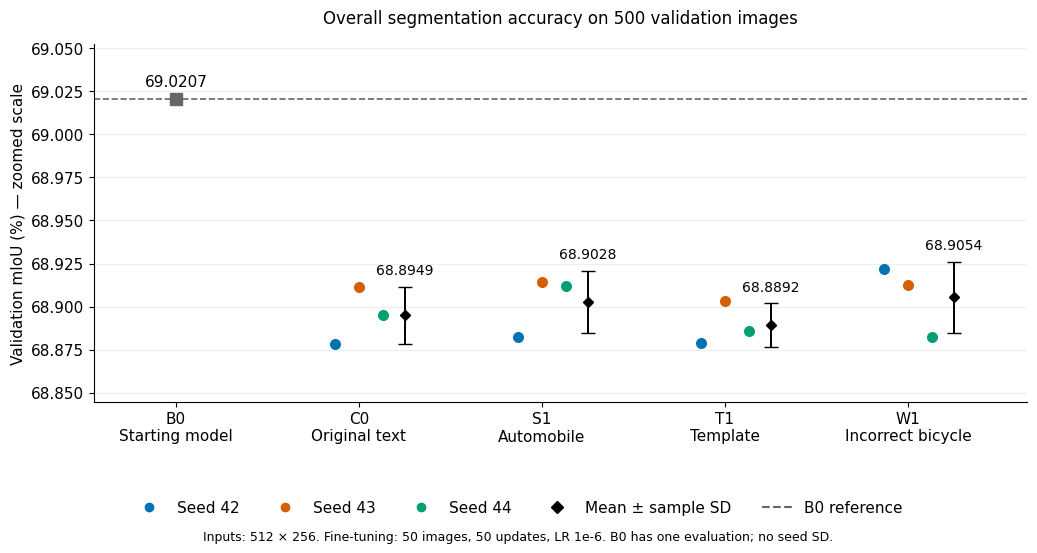

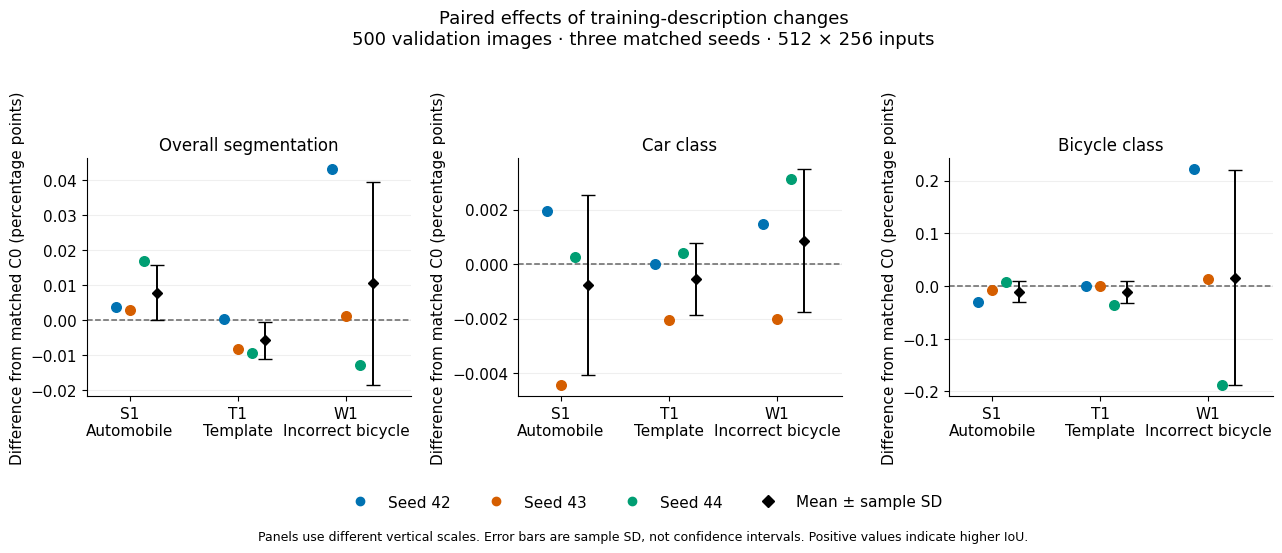

FINAL FIGURES SAVED
/content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/validation_500/final_analysis_20260919_214153_104283/figures
 - figure_captions.json
 - validation_overall_miou.pdf
 - validation_overall_miou.png
 - validation_paired_wording_effects.pdf
 - validation_paired_wording_effects.png

No model loaded. No training or inference performed.


In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


ANALYSIS = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046/"
    "validation_500/final_analysis_20260919_214153_104283"
)
OUTPUT = ANALYSIS / "figures"
OUTPUT.mkdir(parents=True, exist_ok=True)

individual = pd.read_csv(
    ANALYSIS / "individual_results_all_classes.csv"
)
paired = pd.read_csv(
    ANALYSIS / "paired_differences_all_classes.csv"
)

assert len(individual) == 13
assert not individual.duplicated(["Condition", "Seed"]).any()

for condition in ("C0", "S1", "T1", "W1"):
    seeds = individual.loc[
        individual["Condition"] == condition, "Seed"
    ].astype(int)
    assert sorted(seeds.tolist()) == [42, 43, 44]

b0_values = individual.loc[
    individual["Condition"] == "B0", "mIoU (%)"
]
assert len(b0_values) == 1
b0 = float(b0_values.iloc[0])

seed_colors = {
    42: "#0072B2",
    43: "#D55E00",
    44: "#009E73",
}
seed_offsets = {42: -0.13, 43: 0.0, 44: 0.13}

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "savefig.dpi": 300,
})

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=seed_colors[seed],
        label=f"Seed {seed}",
    )
    for seed in (42, 43, 44)
]
legend_handles.append(
    Line2D(
        [0], [0],
        marker="D",
        linestyle="None",
        color="black",
        label="Mean ± sample SD",
    )
)


# ---------- Figure 1: overall validation accuracy ----------

conditions = ["B0", "C0", "S1", "T1", "W1"]
labels = [
    "B0\nStarting model",
    "C0\nOriginal text",
    "S1\nAutomobile",
    "T1\nTemplate",
    "W1\nIncorrect bicycle",
]

fig, ax = plt.subplots(figsize=(10.5, 5.5))

ax.axhline(
    b0, color="0.4", linestyle="--", linewidth=1.2,
    label="B0 reference",
)
ax.scatter(
    0, b0, marker="s", color="0.4", s=65, zorder=4
)
ax.annotate(
    f"{b0:.4f}",
    (0, b0),
    xytext=(0, 9),
    textcoords="offset points",
    ha="center",
)

bounds = [b0]

for position, condition in enumerate(conditions[1:], start=1):
    subset = individual[
        individual["Condition"] == condition
    ].set_index("Seed")

    scores = []
    for seed in (42, 43, 44):
        score = float(subset.loc[seed, "mIoU (%)"])
        scores.append(score)
        ax.scatter(
            position + seed_offsets[seed],
            score,
            color=seed_colors[seed],
            s=48,
            zorder=4,
        )

    mean = float(np.mean(scores))
    sd = float(np.std(scores, ddof=1))
    bounds.extend(scores + [mean - sd, mean + sd])

    ax.errorbar(
        position + 0.25,
        mean,
        yerr=sd,
        fmt="D",
        color="black",
        markersize=5,
        capsize=5,
        linewidth=1.4,
        zorder=5,
    )
    ax.annotate(
        f"{mean:.4f}",
        (position + 0.25, mean + sd),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=10,
    )

span = max(bounds) - min(bounds)
margin = max(0.02, span * 0.22)
ax.set_ylim(min(bounds) - margin, max(bounds) + margin)

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(labels)
ax.set_xlim(-0.45, 4.65)
ax.set_ylabel("Validation mIoU (%) — zoomed scale")
ax.set_title(
    "Overall segmentation accuracy on 500 validation images",
    pad=15,
)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)

fig.legend(
    handles=legend_handles + [
        Line2D(
            [0], [0], color="0.4", linestyle="--",
            label="B0 reference",
        )
    ],
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.025),
)
fig.text(
    0.5, 0.005,
    "Inputs: 512 × 256. Fine-tuning: 50 images, 50 updates, LR 1e-6. "
    "B0 has one evaluation; no seed SD.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=[0, 0.15, 1, 1])

fig.savefig(OUTPUT / "validation_overall_miou.png", bbox_inches="tight")
fig.savefig(OUTPUT / "validation_overall_miou.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


# ---------- Figure 2: wording effects relative to C0 ----------

comparisons = ["S1 minus C0", "T1 minus C0", "W1 minus C0"]
comparison_labels = ["S1\nAutomobile", "T1\nTemplate", "W1\nIncorrect bicycle"]
metrics = ["mIoU", "car IoU", "bicycle IoU"]
titles = ["Overall segmentation", "Car class", "Bicycle class"]

fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))

for ax, metric, title in zip(axes, metrics, titles):
    ax.axhline(0, color="0.4", linestyle="--", linewidth=1.1)

    for position, comparison in enumerate(comparisons):
        subset = paired[
            (paired["Comparison"] == comparison)
            & (paired["Metric"] == metric)
        ].set_index("Seed")

        assert sorted(subset.index.tolist()) == [42, 43, 44]

        values = []
        for seed in (42, 43, 44):
            value = float(subset.loc[seed, "Difference (pp)"])
            values.append(value)
            ax.scatter(
                position + seed_offsets[seed],
                value,
                color=seed_colors[seed],
                s=48,
                zorder=4,
            )

        ax.errorbar(
            position + 0.25,
            np.mean(values),
            yerr=np.std(values, ddof=1),
            fmt="D",
            color="black",
            markersize=5,
            capsize=5,
            linewidth=1.4,
            zorder=5,
        )

    ax.set_title(title)
    ax.set_xticks(range(3))
    ax.set_xticklabels(comparison_labels)
    ax.set_xlim(-0.4, 2.6)
    ax.set_ylabel("Difference from matched C0 (percentage points)")
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

fig.suptitle(
    "Paired effects of training-description changes\n"
    "500 validation images · three matched seeds · 512 × 256 inputs",
    fontsize=13,
)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.045),
)
fig.text(
    0.5, 0.015,
    "Panels use different vertical scales. Error bars are sample SD, "
    "not confidence intervals. Positive values indicate higher IoU.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=[0, 0.17, 1, 0.88])

fig.savefig(OUTPUT / "validation_paired_wording_effects.png",
            bbox_inches="tight")
fig.savefig(OUTPUT / "validation_paired_wording_effects.pdf",
            bbox_inches="tight")
plt.show()
plt.close(fig)


# ---------- Captions and interpretation notes ----------

captions = {
    "validation_overall_miou": (
        "Semantic segmentation mIoU on all 500 official Cityscapes "
        "validation images, using 512 × 256 inputs and predictions "
        "scored at original annotation resolution. Colored points "
        "represent seeds 42–44; black diamonds and error bars show "
        "mean ± sample standard deviation. B0 is the common starting "
        "model and is evaluated once. The vertical scale is zoomed."
    ),
    "validation_paired_wording_effects": (
        "Within-seed differences relative to C0 for synonym replacement "
        "(S1), template rewording (T1), and incorrect class wording (W1). "
        "Each point compares models with the same seed. Black diamonds "
        "and error bars show the mean paired difference ± sample SD "
        "across three seeds. Panels have different vertical scales. "
        "The error bars are not confidence intervals."
    ),
    "scope": (
        "All fine-tuned models used 50 training images, 50 updates and "
        "learning rate 1e-6. These results do not reproduce the "
        "full-resolution benchmark or establish general insensitivity "
        "to training text."
    ),
}
(OUTPUT / "figure_captions.json").write_text(
    json.dumps(captions, indent=2)
)

print("FINAL FIGURES SAVED")
print(OUTPUT)
for path in sorted(OUTPUT.iterdir()):
    if path.suffix in (".png", ".pdf", ".json"):
        print(" -", path.name)

print("\nNo model loaded. No training or inference performed.")

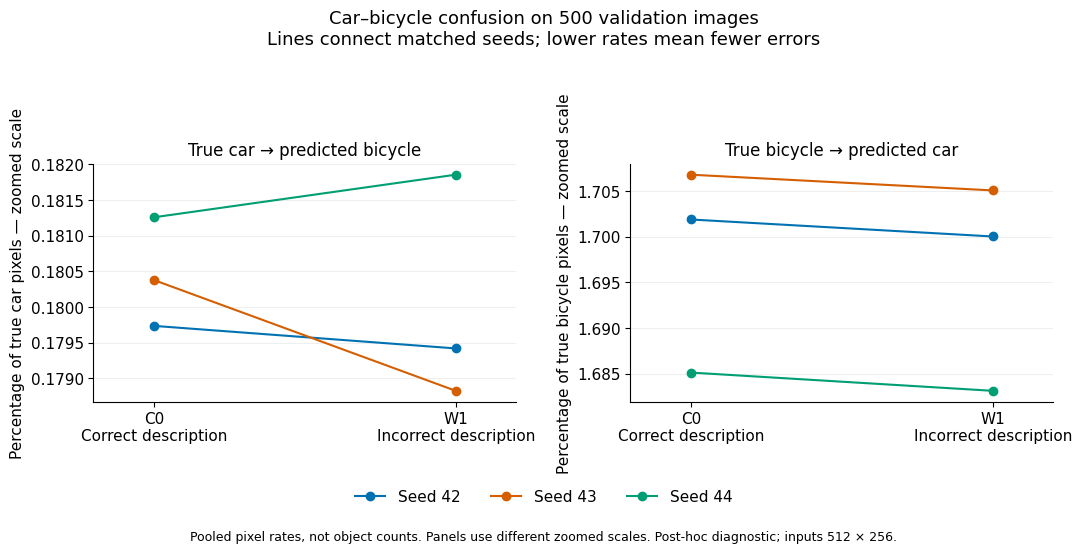

Saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/validation_500/final_analysis_20260919_214153_104283/figures
 - car_bicycle_confusion.png
 - car_bicycle_confusion.pdf
 - car_bicycle_confusion_caption.txt
No training or inference performed.


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046/"
    "validation_500/final_analysis_20260919_214153_104283"
)
OUTPUT = ANALYSIS / "figures"
OUTPUT.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(ANALYSIS / "car_bicycle_confusion.csv")
colors = {42: "#0072B2", 43: "#D55E00", 44: "#009E73"}

panels = [
    (
        "Car predicted bicycle (%)",
        "True car → predicted bicycle",
        "Percentage of true car pixels",
    ),
    (
        "Bicycle predicted car (%)",
        "True bicycle → predicted car",
        "Percentage of true bicycle pixels",
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, (column, title, ylabel) in zip(axes, panels):
    for seed in (42, 43, 44):
        values = []
        for condition in ("C0", "W1"):
            row = data[
                (data["Condition"] == condition)
                & (data["Seed"] == seed)
            ]
            assert len(row) == 1
            values.append(float(row[column].iloc[0]))

        ax.plot(
            [0, 1], values,
            marker="o",
            color=colors[seed],
            linewidth=1.5,
            markersize=6,
            label=f"Seed {seed}",
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["C0\nCorrect description", "W1\nIncorrect description"])
    ax.set_xlim(-0.2, 1.2)
    ax.set_title(title)
    ax.set_ylabel(ylabel + " — zoomed scale")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Car–bicycle confusion on 500 validation images\n"
    "Lines connect matched seeds; lower rates mean fewer errors",
    fontsize=13,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.055),
)
fig.text(
    0.5, 0.015,
    "Pooled pixel rates, not object counts. Panels use different zoomed scales. "
    "Post-hoc diagnostic; inputs 512 × 256.",
    ha="center",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.16, 1, 0.87])

fig.savefig(OUTPUT / "car_bicycle_confusion.png",
            dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT / "car_bicycle_confusion.pdf",
            bbox_inches="tight")
plt.show()
plt.close(fig)

caption = (
    "Directional car–bicycle confusion rates for C0 and W1 on all "
    "500 Cityscapes validation images. Each rate divides the number "
    "of misclassified source-class pixels by all ground-truth pixels "
    "of that source class. Lines connect matched seeds. Lower values "
    "indicate fewer mistakes. The panels use different zoomed scales. "
    "This is a post-hoc diagnostic, not an object-level error analysis."
)
(OUTPUT / "car_bicycle_confusion_caption.txt").write_text(caption)

print("Saved:", OUTPUT)
print(" - car_bicycle_confusion.png")
print(" - car_bicycle_confusion.pdf")
print(" - car_bicycle_confusion_caption.txt")
print("No training or inference performed.")

In [ ]:
from pathlib import Path
from datetime import datetime
import hashlib
import json

import numpy as np
import pandas as pd


ROOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "matched_50image_20260918_220528_251046/validation_500"
)
PROTOCOL_PATH = ROOT / "evaluation_protocol.json"

assert PROTOCOL_PATH.is_file(), "Mount Google Drive first."

protocol = json.loads(PROTOCOL_PATH.read_text())
protocol_hash = hashlib.sha256(PROTOCOL_PATH.read_bytes()).hexdigest()

SEEDS = [42, 43, 44]
CONDITIONS = ["C0", "S1", "T1", "W1"]
BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 20260919
BATCH_SIZE = 50

class_names = protocol["class_names"]
assert len(class_names) == 19

# mIoU is primary. Class-specific results are supporting analyses.
metric_names = ["mIoU", "Car IoU", "Bicycle IoU"]
car_id = class_names.index("car")
bicycle_id = class_names.index("bicycle")

model_names = [
    f"{condition}_seed{seed}"
    for condition in CONDITIONS
    for seed in SEEDS
]
model_index = {name: index for index, name in enumerate(model_names)}

matrices = []
reference_images = None
reference_gt_counts = None

print("Reading saved confusion matrices...")

for name in model_names:
    folder = ROOT / "evaluations" / name
    metrics = json.loads((folder / "metrics.json").read_text())

    assert metrics["number_of_images"] == 500
    assert metrics["protocol_sha256"] == protocol_hash

    if reference_images is None:
        reference_images = metrics["images"]
    assert metrics["images"] == reference_images

    with np.load(folder / "confusion_matrices.npz",
                 allow_pickle=False) as saved:
        per_image = saved["per_image"].copy()
        pooled = saved["pooled"].copy()

    assert per_image.shape == (500, 19, 19)
    assert np.all(per_image >= 0)
    assert np.array_equal(per_image.sum(axis=0), pooled)

    gt_counts = per_image.sum(axis=2)
    if reference_gt_counts is None:
        reference_gt_counts = gt_counts
    assert np.array_equal(gt_counts, reference_gt_counts)

    matrices.append(per_image)

# Shape: models × images × true class × predicted class.
matrices = np.stack(matrices).astype(np.float64)


def calculate_scores(confusion):
    """
    Accepts (..., 19, 19) confusion matrices.
    Returns (..., 3): mIoU, car IoU, bicycle IoU, in percent.
    """
    intersection = np.diagonal(confusion, axis1=-2, axis2=-1)
    true_counts = confusion.sum(axis=-1)
    predicted_counts = confusion.sum(axis=-2)
    union = true_counts + predicted_counts - intersection

    # Keep the same 19-class definition in every replicate.
    assert np.all(union > 0), (
        "A resample has a class with zero union. "
        "Stop and share this output; do not silently change the metric."
    )

    iou = 100.0 * intersection / union
    return np.stack(
        [iou.mean(axis=-1), iou[..., car_id], iou[..., bicycle_id]],
        axis=-1,
    )


observed_scores = calculate_scores(matrices.sum(axis=1))

# Confirm the observed scores match the stored evaluations.
for name, index in model_index.items():
    saved = json.loads(
        (ROOT / "evaluations" / name / "metrics.json").read_text()
    )
    assert np.isclose(
        observed_scores[index, 0],
        saved["miou_percent"],
        rtol=0,
        atol=1e-8,
    )

# Matrix multiplication lets each shared image resample aggregate all models.
# Shape: images × (models * 19 * 19).
flat_matrices = np.ascontiguousarray(
    matrices.transpose(1, 0, 2, 3).reshape(500, -1)
)

rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_scores = np.empty(
    (BOOTSTRAP_REPLICATES, len(model_names), len(metric_names)),
    dtype=np.float64,
)

print("Checks passed.")
print(f"Running {BOOTSTRAP_REPLICATES} shared image resamples...")

for start in range(0, BOOTSTRAP_REPLICATES, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, BOOTSTRAP_REPLICATES)
    count = stop - start

    # Each row samples 500 images with replacement.
    # Identical image counts are used for every model and seed.
    weights = rng.multinomial(
        500,
        np.full(500, 1.0 / 500),
        size=count,
    ).astype(np.float64)

    sampled_matrices = (weights @ flat_matrices).reshape(
        count, len(model_names), 19, 19
    )
    bootstrap_scores[start:stop] = calculate_scores(sampled_matrices)

    if stop % 250 == 0 or stop == BOOTSTRAP_REPLICATES:
        print(f"Bootstrap replicates: {stop}/{BOOTSTRAP_REPLICATES}")


# Paired differences and percentile intervals.
per_seed_rows = []
mean_rows = []
saved_draws = {}

for condition in ["S1", "T1", "W1"]:
    observed_differences = []
    bootstrap_differences = []

    for seed in SEEDS:
        intervention_index = model_index[f"{condition}_seed{seed}"]
        control_index = model_index[f"C0_seed{seed}"]

        observed = (
            observed_scores[intervention_index]
            - observed_scores[control_index]
        )
        draws = (
            bootstrap_scores[:, intervention_index]
            - bootstrap_scores[:, control_index]
        )

        observed_differences.append(observed)
        bootstrap_differences.append(draws)

        for metric_index, metric_name in enumerate(metric_names):
            low, high = np.percentile(
                draws[:, metric_index], [2.5, 97.5]
            )
            per_seed_rows.append({
                "Comparison": f"{condition} minus C0",
                "Seed": seed,
                "Metric": metric_name,
                "Observed difference (pp)": observed[metric_index],
                "95% interval lower (pp)": low,
                "95% interval upper (pp)": high,
            })

    # Average matched differences over the three fixed trained seeds.
    # Seeds themselves are NOT resampled.
    mean_observed = np.mean(observed_differences, axis=0)
    mean_draws = np.mean(
        np.stack(bootstrap_differences, axis=1),
        axis=1,
    )
    saved_draws[f"{condition}_minus_C0"] = mean_draws

    for metric_index, metric_name in enumerate(metric_names):
        low, high = np.percentile(
            mean_draws[:, metric_index], [2.5, 97.5]
        )
        mean_rows.append({
            "Comparison": f"{condition} minus C0",
            "Metric": metric_name,
            "Mean paired difference (pp)": mean_observed[metric_index],
            "95% interval lower (pp)": low,
            "95% interval upper (pp)": high,
            "Interval includes zero": bool(low <= 0 <= high),
        })

per_seed_table = pd.DataFrame(per_seed_rows)
mean_table = pd.DataFrame(mean_rows)

output = ROOT / (
    "paired_image_bootstrap_"
    + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
output.mkdir(parents=True, exist_ok=False)

per_seed_table.to_csv(
    output / "per_seed_bootstrap_intervals.csv", index=False
)
mean_table.to_csv(
    output / "fixed_three_seed_mean_intervals.csv", index=False
)
np.savez_compressed(
    output / "bootstrap_mean_difference_draws.npz",
    **saved_draws,
)

notes = {
    "protocol_sha256": protocol_hash,
    "replicates": BOOTSTRAP_REPLICATES,
    "bootstrap_random_seed": BOOTSTRAP_SEED,
    "resampling_unit": "Image",
    "images_per_resample": 500,
    "replacement": True,
    "pairing": "Same image counts for all models and all seeds",
    "metric_calculation": (
        "Sum sampled per-image confusion matrices before computing "
        "dataset IoUs and mIoU."
    ),
    "interval_method": "Percentile, 2.5th and 97.5th percentiles",
    "primary_metric": "mIoU",
    "supporting_metrics": ["Car IoU", "Bicycle IoU"],
    "three_seed_summary": (
        "Mean paired difference across the three fixed trained seeds "
        "within each shared image resample."
    ),
    "limitations": [
        "Conditional on the trained models; training seeds are not resampled.",
        "Image resampling assumes images are independent sampling units.",
        "Related scenes or sequences can weaken that independence assumption.",
        "Intervals are pointwise, not adjusted for multiple comparisons.",
        "An interval containing zero does not establish equivalence.",
        "The analysis does not cover changes to dataset, training budget, or resolution.",
    ],
    "new_training_or_inference": False,
}
(output / "bootstrap_method.json").write_text(
    json.dumps(notes, indent=2)
)

print("\nPAIRED IMAGE-BOOTSTRAP RESULTS")
print("Mean effects across the three fixed trained seeds:")
print(mean_table.to_string(
    index=False,
    float_format=lambda value: f"{value:.6f}",
))

print("\nSaved:", output)
print("No model loaded. No training or inference performed.")

Reading saved confusion matrices...
Checks passed.
Running 2000 shared image resamples...
Bootstrap replicates: 250/2000
Bootstrap replicates: 500/2000
Bootstrap replicates: 750/2000
Bootstrap replicates: 1000/2000
Bootstrap replicates: 1250/2000
Bootstrap replicates: 1500/2000
Bootstrap replicates: 1750/2000
Bootstrap replicates: 2000/2000

PAIRED IMAGE-BOOTSTRAP RESULTS
Mean effects across the three fixed trained seeds:
 Comparison      Metric  Mean paired difference (pp)  95% interval lower (pp)  95% interval upper (pp)  Interval includes zero
S1 minus C0        mIoU                     0.007923                -0.007561                 0.029509                    True
S1 minus C0     Car IoU                    -0.000754                -0.004308                 0.002905                    True
S1 minus C0 Bicycle IoU                    -0.010396                -0.031222                 0.008355                    True
T1 minus C0        mIoU                    -0.005706              

In [ ]:
from pathlib import Path
import json
import os
import re

PROJECT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
PILOT = PROJECT / "pilots/matched_50image_20260918_220528_251046"
EARLY_PILOT = PROJECT / "pilots/two_image_optimizer_20260917_211825_497623"

assert PROJECT.is_dir(), "Mount Google Drive first."

# Look in known experiment folders and top-level audit/check folders.
roots = [EARLY_PILOT, PILOT]
roots += [
    path for path in PROJECT.iterdir()
    if path.is_dir()
    and any(word in path.name.lower() for word in ("audit", "check", "diagnostic"))
]

keywords = re.compile(
    r"audit|gradient|backward|contrastive|causal|equivalen|"
    r"text.*check|check.*text|restoration|batch_check",
    re.IGNORECASE,
)

# Skip large result/data folders; we only need small verification reports.
skip_folders = {
    "predictions", "per_image", "prepared_train", "node_modules",
    "__pycache__", ".git", "validation_500", "report_summary",
    "figures_train_bus",
}
allowed_extensions = {".json", ".txt", ".md", ".csv"}
found = set()

# Reports directly under the project root.
for path in PROJECT.iterdir():
    if (
        path.is_file()
        and path.suffix.lower() in allowed_extensions
        and keywords.search(path.name)
    ):
        found.add(path)

for root in dict.fromkeys(roots):
    if not root.is_dir():
        continue

    for current, directories, filenames in os.walk(root):
        relative_depth = len(Path(current).relative_to(root).parts)

        directories[:] = [
            name for name in directories
            if name not in skip_folders
            and not name.startswith("evaluation_")
            and not name.startswith("prepared_")
        ]
        if relative_depth >= 3:
            directories[:] = []

        for filename in filenames:
            path = Path(current) / filename
            if (
                path.suffix.lower() in allowed_extensions
                and keywords.search(filename)
            ):
                found.add(path)

reports = sorted(found)

print("SAVED VERIFICATION REPORTS")
print("Files found:", len(reports))

for index, path in enumerate(reports, start=1):
    print(f"{index:02d}. {path.relative_to(PROJECT)}")

# Bounded previews so the output stays manageable.
MAX_TOTAL_CHARACTERS = 24000
MAX_CHARACTERS_PER_FILE = 3000
remaining = MAX_TOTAL_CHARACTERS

print("\nREPORT PREVIEWS")

for path in reports:
    if remaining <= 0:
        print("\nPreview limit reached. The file list above is complete.")
        break

    # Avoid loading unexpectedly large text reports.
    if path.stat().st_size > 1_000_000:
        print(f"\nSkipped large report: {path.name}")
        continue

    try:
        contents = path.read_text(errors="replace")
        if path.suffix.lower() == ".json":
            contents = json.dumps(json.loads(contents), indent=2)
    except Exception as error:
        print(f"\nCould not read {path.name}: {type(error).__name__}: {error}")
        continue

    limit = min(MAX_CHARACTERS_PER_FILE, remaining)
    preview = contents[:limit]

    print("\nFILE:", path.relative_to(PROJECT))
    print(preview)
    if len(contents) > limit:
        print("[Preview truncated; original file unchanged.]")

    remaining -= len(preview)

if not reports:
    print(
        "\nNo matching reports found in the searched locations. "
        "We will need the earlier mechanism-check notebook."
    )

print("\nRead-only evidence inspection complete.")
print("No files changed. No model loaded. No training performed.")

SAVED VERIFICATION REPORTS
Files found: 7
01. checkpoint_audit/causal_mask_comparison.json
02. checkpoint_audit/official_checkpoint_text_audit.txt
03. checkpoint_audit/text_encoder_equivalence_test.json
04. checkpoint_audit/text_mapper_restoration.json
05. pilots/matched_50image_20260918_220528_251046/batch_check.json
06. pilots/matched_50image_20260918_220528_251046/model_restoration_20260919_114454.json
07. training_checks/two_image_loss_and_gradient_test.json

REPORT PREVIEWS

FILE: checkpoint_audit/causal_mask_comparison.json
{
  "test": "temporary_causal_mask_comparison",
  "before_max_absolute_difference": 4.203567981719971,
  "after_max_absolute_difference": 0.0,
  "after_mean_absolute_difference": 0.0,
  "rtol": 0.0001,
  "atol": 1e-05,
  "passed": true,
  "temporary_hooks_removed": true,
  "weights_modified": false
}

FILE: checkpoint_audit/official_checkpoint_text_audit.txt
Repository: shi-labs/oneformer_cityscapes_swin_large
Filename: 250_16_swin_l_oneformer_cityscapes_90k.p

In [ ]:
from pathlib import Path
import json

PROJECT = Path("/content/drive/MyDrive/ONEFORMER_DATA")

report_path = (
    PROJECT / "training_checks/car_automobile_intervention_test.json"
)

print("CONTROLLED CAR–AUTOMOBILE TEST")
if report_path.is_file():
    report = json.loads(report_path.read_text())
    print(json.dumps(report, indent=2))
else:
    print("Saved report not found:", report_path)

source_candidates = [
    PROJECT / (
        "pilots/matched_50image_20260918_220528_251046/"
        "installed_mask_loss_source.txt"
    ),
    PROJECT / (
        "pilot_data/prepared_train_20260918_215631_453240/"
        "installed_mask_loss_source.txt"
    ),
]

print("\nSAVED MASK-LOSS IMPLEMENTATION")
sources = [
    path for path in source_candidates if path.is_file()
]

if sources:
    print("Source:", sources[0])
    print(sources[0].read_text())
else:
    print("Saved source not found in the two known locations.")

print("\nNo model loaded. No files changed. No training performed.")

CONTROLLED CAR–AUTOMOBILE TEST
{
  "test": "controlled_car_to_automobile_intervention",
  "original_description": "a photo with a car",
  "modified_description": "a photo with an automobile",
  "replacements_per_image": [
    8,
    14
  ],
  "changed_token_positions": 44,
  "original": {
    "total_loss": 28.956926345825195,
    "contrastive_loss": 0.47348517179489136
  },
  "modified": {
    "total_loss": 28.972505569458008,
    "contrastive_loss": 0.4890623390674591
  },
  "contrastive_loss_difference": 0.015577167272567749,
  "class_logits_max_difference": 0.0,
  "mask_logits_max_difference": 0.0,
  "model_mode_for_comparison": "eval with training text branch enabled",
  "random_seed": 42,
  "optimizer_update_performed": false
}

SAVED MASK-LOSS IMPLEMENTATION
Source: /content/drive/MyDrive/ONEFORMER_DATA/pilots/matched_50image_20260918_220528_251046/installed_mask_loss_source.txt
    def loss_masks(
        self, masks_queries_logits: Tensor, mask_labels: list[Tensor], indices: tu

In [ ]:
from pathlib import Path
from datetime import datetime
import gc
import json
import random

import numpy as np
import torch
import transformers
from transformers import OneFormerConfig, OneFormerForUniversalSegmentation


PROJECT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
PILOT = PROJECT / "pilots/matched_50image_20260918_220528_251046"
ORIGINAL = PROJECT / "pilots/two_image_optimizer_20260917_211825_497623"
T1 = PILOT / "text_conditions/T1_20260919_123253_618427"
W1 = PILOT / "text_conditions/W1_20260919_140231_895355"

assert torch.cuda.is_available(), "Connect to a GPU runtime first."
assert PILOT.is_dir(), "Mount Google Drive first."

def read_json(path):
    return json.loads(Path(path).read_text())

# Match the recorded implementation instead of silently changing versions.
assert transformers.__version__ == "5.16.1", (
    f"Current transformers version is {transformers.__version__}; "
    "the experiments used 5.16.1. Share this output before proceeding."
)

preparation = read_json(PILOT / "preparation_report.json")
expected_names = read_json(
    PILOT / "C0_lr1e6_20260918_232001_922343/trainable_parameter_names.json"
)
t1_plan = read_json(T1 / "experiment_plan.json")

# Dedicated model for this diagnostic.
config = OneFormerConfig.from_pretrained(
    ORIGINAL / "model_config", local_files_only=True
)
assert config.is_training is True

diagnostic_model = OneFormerForUniversalSegmentation(config)
initial = torch.load(
    t1_plan["common_initial_weights"],
    map_location="cpu",
    weights_only=True,
)
diagnostic_model.load_state_dict(initial, strict=True)
del initial
gc.collect()

encoder = diagnostic_model.model.text_mapper.text_encoder

def causal_mask_hook(module, args, kwargs):
    query = args[0]
    length = query.shape[1] if module.batch_first else query.shape[0]
    kwargs = dict(kwargs)
    kwargs["attn_mask"] = torch.full(
        (length, length),
        float("-inf"),
        dtype=query.dtype,
        device=query.device,
    ).triu(1)
    return args, kwargs

assert len(encoder.transformer.layers) == 6
mask_handles = [
    layer.self_attn.register_forward_pre_hook(
        causal_mask_hook, with_kwargs=True
    )
    for layer in encoder.transformer.layers
]

expected_set = set(expected_names)
for name, parameter in diagnostic_model.named_parameters():
    parameter.requires_grad_(name in expected_set)

assert [
    name for name, parameter in diagnostic_model.named_parameters()
    if parameter.requires_grad
] == expected_names

diagnostic_model.to(device="cuda", dtype=torch.float32)

# Disable dropout while retaining the construction-time training text branch.
diagnostic_model.eval()

# Load two identical prepared images for all conditions.
indices = [0, 1]
samples = [
    torch.load(
        preparation["records"][index]["prepared_file"],
        map_location="cpu",
        weights_only=True,
    )
    for index in indices
]

batch = {}
for key in samples[0]["inputs"]:
    values = [sample["inputs"][key] for sample in samples]
    if torch.is_tensor(values[0]):
        batch[key] = torch.cat(values, dim=0).to("cuda")
    elif key in ("mask_labels", "class_labels"):
        batch[key] = [
            item.to("cuda")
            for value in values
            for item in value
        ]
    else:
        raise TypeError(f"Unexpected input: {key}")

t1_tokens = torch.load(
    T1 / "template_text_tokens.pt",
    map_location="cpu", weights_only=True,
)["text_inputs_by_image"]

w1_tokens = torch.load(
    W1 / "wrong_class_text_tokens.pt",
    map_location="cpu", weights_only=True,
)["text_inputs_by_image"]

image_names = [preparation["records"][i]["image"] for i in indices]

texts = {
    "C0": batch["text_inputs"].detach().cpu().clone(),
    "S1": torch.cat([s["s1_text_inputs"] for s in samples], dim=0),
    "T1": torch.cat([t1_tokens[name] for name in image_names], dim=0),
    "W1": torch.cat([w1_tokens[name] for name in image_names], dim=0),
}
for condition, text in texts.items():
    assert text.shape == texts["C0"].shape
    if condition != "C0":
        assert not torch.equal(text, texts["C0"])

# Test trainable segmentation parameters, excluding the text branch and loss module.
shared_parameters = [
    (name, parameter)
    for name, parameter in diagnostic_model.named_parameters()
    if parameter.requires_grad
    and not name.startswith("model.text_mapper.")
    and not name.startswith("criterion.")
]
assert shared_parameters

output_folder = PROJECT / "training_checks" / (
    "contrastive_sensitivity_"
    + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
output_folder.mkdir(parents=True, exist_ok=False)

captured = {}

def capture_criterion(module, args, output):
    assert "loss_contrastive" in output
    # Keep the tensor at criterion return, before outer loss weighting.
    captured["contrastive"] = output["loss_contrastive"].clone()

def capture_embedding(module, args, output):
    assert torch.is_tensor(output), "Unexpected text-encoder output format."
    captured["embedding"] = output.detach().cpu().clone()

loss_handle = diagnostic_model.criterion.register_forward_hook(
    capture_criterion
)
embedding_handle = encoder.register_forward_hook(capture_embedding)

reference_gradients = None
reference_embedding = None
reference_class_logits = None
reference_mask_logits = None
reports = []

try:
    for condition in ("C0", "C0_repeat", "S1", "T1", "W1"):
        source_condition = "C0" if condition == "C0_repeat" else condition
        captured.clear()
        diagnostic_model.zero_grad(set_to_none=True)

        # Match random effects such as loss point sampling.
        random.seed(42)
        np.random.seed(42)
        torch.manual_seed(42)
        torch.cuda.manual_seed_all(42)

        inputs = dict(batch)
        inputs["text_inputs"] = texts[source_condition].to("cuda")

        outputs = diagnostic_model(**inputs, return_dict=True)
        loss = captured["contrastive"]
        assert loss.requires_grad and torch.isfinite(loss).item()

        # Only the contrastive component is differentiated.
        gradients = torch.autograd.grad(
            loss,
            [parameter for _, parameter in shared_parameters],
            allow_unused=True,
        )

        cpu_gradients = {}
        norm_squared = 0.0
        nonzero_count = 0
        connected_count = 0

        for (name, _), gradient in zip(shared_parameters, gradients):
            if gradient is None:
                continue
            assert torch.isfinite(gradient).all().item(), name
            value = gradient.detach().cpu().float()
            cpu_gradients[name] = value
            connected_count += 1
            norm_squared += value.double().square().sum().item()
            nonzero_count += int(torch.count_nonzero(value).item() > 0)

        embedding = captured["embedding"]
        assert torch.isfinite(embedding).all().item()
        class_logits = outputs.class_queries_logits.detach().cpu()
        mask_logits = outputs.masks_queries_logits.detach().cpu()

        if condition == "C0":
            reference_gradients = {
                name: value.clone() for name, value in cpu_gradients.items()
            }
            reference_embedding = embedding.clone()
            reference_class_logits = class_logits.clone()
            reference_mask_logits = mask_logits.clone()

        assert cpu_gradients.keys() == reference_gradients.keys(), (
            "Gradient connectivity changed across conditions."
        )

        difference_squared = 0.0
        maximum_difference = 0.0
        changed_parameter_tensors = 0

        for name, gradient in cpu_gradients.items():
            difference = gradient - reference_gradients[name]
            difference_squared += difference.double().square().sum().item()
            maximum_difference = max(
                maximum_difference,
                difference.abs().max().item(),
            )
            changed_parameter_tensors += int(
                torch.count_nonzero(difference).item() > 0
            )

        row = {
            "condition": condition,
            "criterion_contrastive_loss_before_outer_weighting": loss.item(),
            "total_model_loss": outputs.loss.item(),
            "changed_description_rows_per_image": (
                texts[source_condition] != texts["C0"]
            ).any(dim=-1).sum(dim=-1).tolist(),
            "text_embedding_max_difference_from_C0": (
                embedding - reference_embedding
            ).abs().max().item(),
            "shared_parameter_tensors_connected": connected_count,
            "shared_parameter_tensors_with_nonzero_gradient": nonzero_count,
            "shared_contrastive_gradient_norm": norm_squared ** 0.5,
            "shared_gradient_difference_norm_from_C0": difference_squared ** 0.5,
            "shared_gradient_max_difference_from_C0": maximum_difference,
            "shared_parameter_tensors_with_changed_gradient": changed_parameter_tensors,
            "class_logits_max_difference_from_C0": (
                class_logits - reference_class_logits
            ).abs().max().item(),
            "mask_logits_max_difference_from_C0": (
                mask_logits - reference_mask_logits
            ).abs().max().item(),
        }
        reports.append(row)

        (output_folder / "results.json").write_text(
            json.dumps(reports, indent=2)
        )
        print("\n" + condition)
        print(json.dumps(row, indent=2))

        del outputs, loss, gradients, cpu_gradients, inputs
        captured.clear()
        gc.collect()

finally:
    loss_handle.remove()
    embedding_handle.remove()
    for handle in mask_handles:
        handle.remove()
    diagnostic_model.zero_grad(set_to_none=True)

metadata = {
    "purpose": "Post-hoc mechanistic verification",
    "starting_weights": t1_plan["common_initial_weights"],
    "image_indices": indices,
    "image_names": image_names,
    "conditions": ["C0", "C0_repeat", "S1", "T1", "W1"],
    "mode": "Evaluation mode with training text branch enabled",
    "random_seed_reset_before_each_forward": 42,
    "gradient_source": "Contrastive loss only, before outer loss weighting",
    "shared_parameters_tested": [name for name, _ in shared_parameters],
    "torch_version": str(torch.__version__),
    "transformers_version": transformers.__version__,
    "optimizer_updates": 0,
    "limitations": [
        "One two-image batch; not an accuracy experiment.",
        "Dropout disabled for a controlled diagnostic.",
        "Tiny numerical differences must be judged against C0_repeat.",
    ],
}
(output_folder / "method.json").write_text(json.dumps(metadata, indent=2))

# Release this dedicated diagnostic model.
del shared_parameters, batch, diagnostic_model, encoder
reference_gradients = None
gc.collect()
torch.cuda.empty_cache()

print("\nDiagnostic saved:", output_folder)
print("No optimizer created. No training updates performed.")


C0
{
  "condition": "C0",
  "criterion_contrastive_loss_before_outer_weighting": 1.0470343828201294,
  "total_model_loss": 34.534854888916016,
  "changed_description_rows_per_image": [
    0,
    0
  ],
  "text_embedding_max_difference_from_C0": 0.0,
  "shared_parameter_tensors_connected": 164,
  "shared_parameter_tensors_with_nonzero_gradient": 164,
  "shared_contrastive_gradient_norm": 6.89982220083896,
  "shared_gradient_difference_norm_from_C0": 0.0,
  "shared_gradient_max_difference_from_C0": 0.0,
  "shared_parameter_tensors_with_changed_gradient": 0,
  "class_logits_max_difference_from_C0": 0.0,
  "mask_logits_max_difference_from_C0": 0.0
}

C0_repeat
{
  "condition": "C0_repeat",
  "criterion_contrastive_loss_before_outer_weighting": 1.0470343828201294,
  "total_model_loss": 34.534854888916016,
  "changed_description_rows_per_image": [
    0,
    0
  ],
  "text_embedding_max_difference_from_C0": 0.0,
  "shared_parameter_tensors_connected": 164,
  "shared_parameter_tensors_with_

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
GPU available: True
GPU: Tesla T4
